In [1]:
# ============================================================
# CELL 0: SEEDS AND IMPORTS
# ============================================================
# paper_replication.ipynb
# Replication of Hwang and Zohren (2025)
# Signature-Informed Transformer for Asset Allocation
#
# This notebook replicates the original SIT paper using
# Yahoo Finance data and extends it by comparing five
# drawdown-based training objectives as alternatives to CVaR
#
# To switch between asset pool sizes change DATA_POOL
# in Cell 1 — everything else updates automatically

import random
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.stats as scipy_stats
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# ---- Set consistent plot style ----
sns.set_style('darkgrid')

# ---- Deterministic seed function ----
def set_all_seeds(seed=42):
    """
    Lock all random seeds across every library.
    Ensures identical results every run.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED']       = str(seed)
    print(f"All seeds locked to: {seed}")

# ---- Call immediately ----
set_all_seeds(42)
GLOBAL_SEED = 42

# ---- Set device ----
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on      : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print("\nCell 0 complete — all imports successful")

All seeds locked to: 42
Running on      : cpu
PyTorch version : 2.8.0+cpu
NumPy version   : 1.26.4

Cell 0 complete — all imports successful


In [2]:
# ============================================================
# CELL 1: CONFIGURATION
# ============================================================
# THIS IS THE ONLY CELL YOU NEED TO CHANGE
# to switch between asset pool sizes
#
# Set DATA_POOL to 30, 40 or 50
# Everything else in the notebook updates automatically
#
# DATA_POOL = 30 → fastest  (Tech + Financials + Healthcare)
# DATA_POOL = 40 → medium   (above + Energy)
# DATA_POOL = 50 → slowest  (above + Consumer Staples)
#                            closest to paper's largest test

# ---- CHANGE THIS VALUE ONLY ----
DATA_POOL = 50
# --------------------------------

# ---- Data folder ----
# Named after pool size to keep runs separate
# Running with 30 saves to data_paper_30/
# Running with 40 saves to data_paper_40/
# Running with 50 saves to data_paper_50/
DATA_FOLDER = f'data_paper_{DATA_POOL}'

# Create folder if it does not exist
if not os.path.exists(DATA_FOLDER):
    os.makedirs(DATA_FOLDER)
    print(f"Created folder: {DATA_FOLDER}")
else:
    print(f"Using folder  : {DATA_FOLDER}")

# ---- Subfolders ----
SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')

for folder in [SIG_FOLDER, MODELS_FOLDER, ROBUST_FOLDER]:
    if not os.path.exists(folder):
        os.makedirs(folder)

# ---- Paper's exact train/val/test split ----
# Matches Hwang and Zohren (2025) exactly
# Training   : 2000-01-01 to 2016-12-31 (17 years)
#              Covers dot-com crash, GFC, recovery
# Validation : 2017-01-01 to 2019-12-31 (3 years)
#              Used for early stopping only
# Testing    : 2020-01-01 to 2024-12-31 (5 years)
#              Covers COVID, recovery, 2022 rate shock
TRAIN_START = '2000-01-01'
TRAIN_END   = '2016-12-31'
VAL_START   = '2017-01-01'
VAL_END     = '2019-12-31'
TEST_START  = '2020-01-01'
TEST_END    = '2024-12-31'
DATA_START  = '2000-01-01'
DATA_END    = '2024-12-31'

# ---- Signature hyperparameters ----
# These match standard choices in the literature
LOOKBACK  = 20    # 20 trading days = 1 calendar month
SIG_ORDER = 2     # capture up to 3rd order interactions

# ---- Model hyperparameters ----
D_MODEL       = 64    # Transformer internal dimension
N_HEADS       = 4     # attention heads
N_LAYERS      = 2     # Transformer encoder layers
DROPOUT       = 0.1   # dropout rate
BATCH_SIZE    = 64    # training batch size
N_EPOCHS      = 100   # maximum training epochs
LEARNING_RATE = 1e-4  # Adam optimiser learning rate
PATIENCE      = 15    # early stopping patience

# ---- Print configuration ----
print(f"\n{'='*50}")
print(f"  CONFIGURATION SUMMARY")
print(f"{'='*50}")
print(f"  Asset pool      : {DATA_POOL} stocks")
print(f"  Data folder     : {DATA_FOLDER}/")
print(f"  Training        : {TRAIN_START} to {TRAIN_END}")
print(f"  Validation      : {VAL_START} to {VAL_END}")
print(f"  Testing         : {TEST_START} to {TEST_END}")
print(f"  Lookback window : {LOOKBACK} days")
print(f"  Signature order : {SIG_ORDER}")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Max epochs      : {N_EPOCHS}")
print(f"  Learning rate   : {LEARNING_RATE}")
print(f"  Early stopping  : {PATIENCE} epochs patience")
print(f"{'='*50}")
print(f"\nCell 1 complete")

Using folder  : data_paper_50

  CONFIGURATION SUMMARY
  Asset pool      : 50 stocks
  Data folder     : data_paper_50/
  Training        : 2000-01-01 to 2016-12-31
  Validation      : 2017-01-01 to 2019-12-31
  Testing         : 2020-01-01 to 2024-12-31
  Lookback window : 20 days
  Signature order : 2
  Batch size      : 64
  Max epochs      : 100
  Learning rate   : 0.0001
  Early stopping  : 15 epochs patience

Cell 1 complete


In [3]:
# ============================================================
# CELL 2: DEFINE THE 50-STOCK UNIVERSE
# ============================================================
# Stock selection criteria:
# 1. Listed and actively traded BEFORE January 2000
#    so we have the full 17-year training period
# 2. Still actively traded today — no delistings
# 3. Diversified across five sectors to ensure path
#    signatures capture meaningful cross-asset interactions
#    from different economic drivers
#
# Four stocks from the original selection were replaced:
#
# BCR → BSX
#   BCR (C.R. Bard) was acquired by Becton Dickinson
#   in December 2017 and subsequently delisted.
#   BSX (Boston Scientific) is a comparable medical
#   device company listed since 1992 with continuous
#   price history through 2024.
#
# K → CPB
#   K (Kellanova, formerly Kellogg) was acquired by
#   Mars Inc in August 2024 causing data to end
#   mid test period. CPB (Campbell Soup) is a
#   comparable consumer staples company with
#   continuous price history dating back to 1954.
#
# MMC → CB
#   MMC (Marsh McLennan) had significant data gaps
#   around the year 2000 start date on Yahoo Finance
#   making it unsuitable for our training period.
#   CB (Chubb Limited) is a comparable large-cap
#   insurance company with complete data from 2000.
#
# PSX → OXY
#   PSX (Phillips 66) was spun off from ConocoPhillips
#   in May 2012 meaning no price data exists before
#   that date. Our training period starts in 2000 so
#   PSX cannot be used. OXY (Occidental Petroleum)
#   is a comparable energy company listed since the
#   1920s with full history available.

ALL_TICKERS_50 = [

    # ---- TECHNOLOGY (12 stocks) ----
    # Established technology companies all listed
    # before 2000 with continuous trading history
    'AAPL',   # Apple Inc — listed 1980
    'MSFT',   # Microsoft Corporation — listed 1986
    'IBM',    # International Business Machines — listed 1916
    'INTC',   # Intel Corporation — listed 1971
    'CSCO',   # Cisco Systems — listed 1990
    'TXN',    # Texas Instruments — listed 1953
    'QCOM',   # Qualcomm Inc — listed 1991
    'ADI',    # Analog Devices — listed 1969
    'GLW',    # Corning Inc — listed 1945
    'AMAT',   # Applied Materials — listed 1972
    'KLAC',   # KLA Corporation — listed 1980
    'LRCX',   # Lam Research — listed 1984

    # ---- FINANCIALS (12 stocks) ----
    # Major US banks and insurance companies
    # CB replaces MMC which had Yahoo Finance
    # data gaps around the year 2000
    'JPM',    # JPMorgan Chase — listed 1969
    'BAC',    # Bank of America — listed 1986
    'WFC',    # Wells Fargo — listed 1962
    'C',      # Citigroup — listed 1977
    'GS',     # Goldman Sachs — listed 1999
    'MS',     # Morgan Stanley — listed 1986
    'USB',    # US Bancorp — listed 1929
    'PNC',    # PNC Financial Services — listed 1983
    'CB',     # Chubb Limited — replaces MMC
               # MMC had data gaps in Yahoo Finance
               # around 2000; CB has complete history
    'AON',    # Aon plc — listed 1968
    'TRV',    # Travelers Companies — listed 1994
    'AFL',    # Aflac Inc — listed 1974

    # ---- HEALTHCARE (10 stocks) ----
    # Established pharmaceutical and medical device
    # companies all with pre-2000 listing dates
    # BSX replaces BCR which was delisted in 2017
    'JNJ',    # Johnson and Johnson — listed 1944
    'PFE',    # Pfizer Inc — listed 1944
    'MRK',    # Merck and Co — listed 1946
    'ABT',    # Abbott Laboratories — listed 1929
    'MDT',    # Medtronic plc — listed 1960
    'BAX',    # Baxter International — listed 1931
    'BSX',    # Boston Scientific — replaces BCR
               # BCR (C.R. Bard) was acquired by BDX
               # in 2017 and delisted; BSX is a
               # comparable medical device company
               # with continuous history since 1992
    'BDX',    # Becton Dickinson — listed 1963
    'SYK',    # Stryker Corporation — listed 1979
    'ZBH',    # Zimmer Biomet — listed 2001
               # Note: ZBH listed August 2001
               # first few months of training will
               # be backward-filled from first trade

    # ---- ENERGY (8 stocks) ----
    # Major US oil and gas companies
    # OXY replaces PSX which only listed in 2012
    'XOM',    # Exxon Mobil — listed 1920
    'CVX',    # Chevron Corporation — listed 1925
    'COP',    # ConocoPhillips — listed 2002
               # Note: COP listed 2002 after merger
               # first months backward-filled
    'SLB',    # SLB (Schlumberger) — listed 1962
    'HAL',    # Halliburton — listed 1948
    'BKR',    # Baker Hughes — listed 1987
    'OXY',    # Occidental Petroleum — replaces PSX
               # PSX (Phillips 66) only listed 2012
               # no data for our 2000 start date
               # OXY has continuous history since 1920
    'VLO',    # Valero Energy — listed 1997

    # ---- CONSUMER STAPLES (8 stocks) ----
    # Defensive consumer brands with long histories
    # CPB replaces K which was acquired by Mars 2024
    'PG',     # Procter and Gamble — listed 1891
    'KO',     # Coca-Cola Company — listed 1919
    'PEP',    # PepsiCo Inc — listed 1919
    'WMT',    # Walmart Inc — listed 1972
    'MCD',    # McDonalds Corporation — listed 1965
    'CL',     # Colgate-Palmolive — listed 1930
    'GIS',    # General Mills — listed 1928
    'CPB',    # Campbell Soup — replaces K
               # K (Kellanova) acquired by Mars
               # August 2024 — data ends mid period
               # CPB has continuous history from 1954
]

# ---- Select tickers based on DATA_POOL ----
# DATA_POOL set in Cell 1
# 30 → Technology + Financials + Healthcare
# 40 → above + Energy
# 50 → all five sectors including Consumer Staples
TICKERS = ALL_TICKERS_50[:DATA_POOL]

# ---- Sector map for plotting ----
# Maps each ticker to its sector
SECTOR_MAP = {
    'AAPL' : 'Technology',  'MSFT' : 'Technology',
    'IBM'  : 'Technology',  'INTC' : 'Technology',
    'CSCO' : 'Technology',  'TXN'  : 'Technology',
    'QCOM' : 'Technology',  'ADI'  : 'Technology',
    'GLW'  : 'Technology',  'AMAT' : 'Technology',
    'KLAC' : 'Technology',  'LRCX' : 'Technology',
    'JPM'  : 'Financials',  'BAC'  : 'Financials',
    'WFC'  : 'Financials',  'C'    : 'Financials',
    'GS'   : 'Financials',  'MS'   : 'Financials',
    'USB'  : 'Financials',  'PNC'  : 'Financials',
    'CB'   : 'Financials',  'AON'  : 'Financials',
    'TRV'  : 'Financials',  'AFL'  : 'Financials',
    'JNJ'  : 'Healthcare',  'PFE'  : 'Healthcare',
    'MRK'  : 'Healthcare',  'ABT'  : 'Healthcare',
    'MDT'  : 'Healthcare',  'BAX'  : 'Healthcare',
    'BSX'  : 'Healthcare',  'BDX'  : 'Healthcare',
    'SYK'  : 'Healthcare',  'ZBH'  : 'Healthcare',
    'XOM'  : 'Energy',      'CVX'  : 'Energy',
    'COP'  : 'Energy',      'SLB'  : 'Energy',
    'HAL'  : 'Energy',      'BKR'  : 'Energy',
    'OXY'  : 'Energy',      'VLO'  : 'Energy',
    'PG'   : 'Consumer',    'KO'   : 'Consumer',
    'PEP'  : 'Consumer',    'WMT'  : 'Consumer',
    'MCD'  : 'Consumer',    'CL'   : 'Consumer',
    'GIS'  : 'Consumer',    'CPB'  : 'Consumer',
}

# ---- Sector colours for plots ----
SECTOR_COLOURS = {
    'Technology' : 'steelblue',
    'Financials' : 'darkorange',
    'Healthcare' : 'green',
    'Energy'     : 'red',
    'Consumer'   : 'purple',
}

# ---- Print summary ----
print(f"Full universe     : {len(ALL_TICKERS_50)} stocks")
print(f"Selected pool     : {len(TICKERS)} stocks")
print(f"\nReplacement summary:")
print(f"  BCR → BSX : BCR delisted after BDX "
      f"acquisition 2017")
print(f"  K   → CPB : K acquired by Mars August 2024")
print(f"  MMC → CB  : MMC data gaps on Yahoo Finance "
      f"around 2000")
print(f"  PSX → OXY : PSX only listed from May 2012")
print(f"\nSelected tickers ({DATA_POOL}):")

# Print with sector labels
current_sector = None
for i, ticker in enumerate(TICKERS, 1):
    sector = SECTOR_MAP.get(ticker, 'Other')
    if sector != current_sector:
        print(f"\n  [{sector}]")
        current_sector = sector
    print(f"    {i:>3}. {ticker}")

print(f"\nCell 2 complete")

Full universe     : 50 stocks
Selected pool     : 50 stocks

Replacement summary:
  BCR → BSX : BCR delisted after BDX acquisition 2017
  K   → CPB : K acquired by Mars August 2024
  MMC → CB  : MMC data gaps on Yahoo Finance around 2000
  PSX → OXY : PSX only listed from May 2012

Selected tickers (50):

  [Technology]
      1. AAPL
      2. MSFT
      3. IBM
      4. INTC
      5. CSCO
      6. TXN
      7. QCOM
      8. ADI
      9. GLW
     10. AMAT
     11. KLAC
     12. LRCX

  [Financials]
     13. JPM
     14. BAC
     15. WFC
     16. C
     17. GS
     18. MS
     19. USB
     20. PNC
     21. CB
     22. AON
     23. TRV
     24. AFL

  [Healthcare]
     25. JNJ
     26. PFE
     27. MRK
     28. ABT
     29. MDT
     30. BAX
     31. BSX
     32. BDX
     33. SYK
     34. ZBH

  [Energy]
     35. XOM
     36. CVX
     37. COP
     38. SLB
     39. HAL
     40. BKR
     41. OXY
     42. VLO

  [Consumer]
     43. PG
     44. KO
     45. PEP
     46. WMT
     47. MCD
     48.

In [4]:
# ============================================================
# CELL 3: DOWNLOAD DATA FROM YAHOO FINANCE
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np

RAW_DATA_PATH = os.path.join(
    DATA_FOLDER, 'raw_prices.csv')

# ---- Check if already downloaded ----
# If raw_prices.csv exists on disk load it directly
# This avoids re-downloading every time you run
# the notebook — saves time and bandwidth
if os.path.exists(RAW_DATA_PATH):
    print("Raw data found on disk — loading...")
    raw_prices = pd.read_csv(
        RAW_DATA_PATH,
        index_col=0,
        parse_dates=True
    )
    print(f"Loaded successfully")
    print(f"  Rows    : {raw_prices.shape[0]}")
    print(f"  Columns : {raw_prices.shape[1]}")

else:
    print(f"Downloading {len(TICKERS)} stocks "
          f"from Yahoo Finance...")
    print(f"Period  : {DATA_START} to {DATA_END}")
    print(f"Stocks  : {len(TICKERS)}")
    print("\nThis may take 1-2 minutes...\n")

    # Download adjusted closing prices
    # auto_adjust=True adjusts for dividends and splits
    # This is critical — unadjusted prices show
    # artificial jumps on ex-dividend dates that
    # would confuse the signature computation
    raw_prices = yf.download(
        tickers     = TICKERS,
        start       = DATA_START,
        end         = DATA_END,
        auto_adjust = True,
        progress    = True
    )['Close']

    # Save to disk for future runs
    raw_prices.to_csv(RAW_DATA_PATH)
    print(f"\nSaved to {RAW_DATA_PATH}")
    print(f"  Rows    : {raw_prices.shape[0]}")
    print(f"  Columns : {raw_prices.shape[1]}")

print(f"\nDate range : {raw_prices.index[0].date()} "
      f"to {raw_prices.index[-1].date()}")
print(f"\nFirst 5 rows:")
print(raw_prices.head())
print(f"\nCell 3 complete")

Raw data found on disk — loading...
Loaded successfully
  Rows    : 6288
  Columns : 50

Date range : 2000-01-03 to 2024-12-30

First 5 rows:
                AAPL       ABT        ADI       AFL       AMAT        AON  \
Date                                                                        
2000-01-03  0.838496  8.042601  27.553596  6.633263  22.880159  26.473589   
2000-01-04  0.767802  7.812813  26.159687  6.457241  21.749714  25.879644   
2000-01-05  0.779038  7.798454  26.541578  6.420180  20.935797  26.643293   
2000-01-06  0.711621  8.071330  25.815987  6.549882  20.969715  27.576658   
2000-01-07  0.745330  8.157498  26.541578  6.679585  21.150581  29.019142   

                  BAC        BAX        BDX        BKR  ...        SLB  \
Date                                                    ...              
2000-01-03  12.356377   9.931424  13.284969   9.025366  ...  16.510002   
2000-01-04  11.622962   9.708930  12.936200   9.025366  ...  16.284616   
2000-01-05  11.750515 

In [5]:
# ============================================================
# CELL 4: CLEAN THE RAW PRICE DATA
# ============================================================

import pandas as pd
import numpy as np

prices = raw_prices.copy()

# ---- Step 1: Check missing values ----
# Missing values occur when a stock was not traded
# on a given day due to public holidays, early closes
# or genuine data gaps in Yahoo Finance
missing_count = prices.isnull().sum()
missing_pct   = (missing_count / len(prices)) * 100

print("Missing values per stock:")
print(pd.DataFrame({
    'Missing Days' : missing_count,
    'Missing %'    : missing_pct.round(2)
}))

# ---- Step 2: Drop stocks with too many gaps ----
# Threshold set at 10% because we go back to 2000
# Some stocks like ZBH and COP listed slightly after
# 2000 so they will have small gaps at the very start
# which is acceptable and handled by backward-fill below
# Any stock missing more than 10% is genuinely problematic
MAX_MISSING_PCT = 10.0
stocks_to_drop  = missing_pct[
    missing_pct > MAX_MISSING_PCT
].index.tolist()

if len(stocks_to_drop) > 0:
    print(f"\nDropping stocks with more than "
          f"{MAX_MISSING_PCT}% missing:")
    print(stocks_to_drop)
    prices = prices.drop(columns=stocks_to_drop)
else:
    print(f"\nNo stocks dropped — all passed threshold")

# ---- Step 3: Forward-fill small gaps ----
# Carries the last known price forward for 1-2 day gaps
# caused by public holidays and early market closes
# Using updated pandas syntax — ffill() replaces
# the deprecated fillna(method='ffill')
prices = prices.ffill()

# ---- Step 4: Backward-fill any leading NaNs ----
# Some stocks listed slightly after 2000-01-01
# For example ZBH listed August 2001 and COP in 2002
# Backward-fill carries the first available price
# backward to fill those early missing rows
# Using updated pandas syntax — bfill() replaces
# the deprecated fillna(method='bfill')
prices = prices.bfill()

# ---- Step 5: Drop any remaining NaN rows ----
# After ffill and bfill there should be none left
# This is a safety check only
prices = prices.dropna()

# ---- Update ticker list ----
# If any stocks were dropped in Step 2
# the ticker list must be updated to match
TICKERS  = prices.columns.tolist()
N_ASSETS = len(TICKERS)

# ---- Print cleaning summary ----
print(f"\nCLEANING SUMMARY:")
print(f"{'─'*40}")
print(f"  Original stocks  : {DATA_POOL}")
print(f"  Stocks dropped   : "
      f"{DATA_POOL - N_ASSETS}")
print(f"  Stocks remaining : {N_ASSETS}")
print(f"  Trading days     : {len(prices)}")
print(f"  Date range       : "
      f"{prices.index[0].date()} to "
      f"{prices.index[-1].date()}")
print(f"{'─'*40}")
print(f"\nFinal tickers ({N_ASSETS}):")
print(TICKERS)
print(f"\nCell 4 complete")

Missing values per stock:
      Missing Days  Missing %
AAPL             0       0.00
ABT              0       0.00
ADI              0       0.00
AFL              0       0.00
AMAT             0       0.00
AON              0       0.00
BAC              0       0.00
BAX              0       0.00
BDX              0       0.00
BKR              0       0.00
BSX              0       0.00
C                0       0.00
CB               0       0.00
CL               0       0.00
COP              0       0.00
CPB              0       0.00
CSCO             0       0.00
CVX              0       0.00
GIS              0       0.00
GLW              0       0.00
GS               0       0.00
HAL              0       0.00
IBM              0       0.00
INTC             0       0.00
JNJ              0       0.00
JPM              0       0.00
KLAC             0       0.00
KO               0       0.00
LRCX             0       0.00
MCD              0       0.00
MDT              0       0.00
MRK           

In [6]:
# ============================================================
# CELL 5: COMPUTE LOG RETURNS
# ============================================================

import numpy as np

# ---- Why log returns? ----
# We use LOG returns rather than simple returns
# for two important reasons:
#
# 1. Additivity over time
#    Daily log returns sum to give the total period
#    log return making multi-period calculations clean
#    Simple returns compound multiplicatively which
#    is harder to work with mathematically
#
# 2. Better neural network behaviour
#    Log returns are more symmetric around zero
#    and have more stable variance than simple returns
#    This makes gradient-based training more stable
#
# Formula: r_t = log(P_t / P_{t-1})
# Equivalent to: log(P_t) - log(P_{t-1})

log_returns = np.log(prices / prices.shift(1))

# ---- Drop first row ----
# The first row has no previous price to compute
# a return from so it is always NaN
log_returns = log_returns.dropna()

# ---- Winsorise extreme values ----
# Yahoo Finance occasionally contains data errors
# that appear as extreme one-day moves
# For example a stock showing -99% or +500% in one day
# Winsorising clips values beyond the 0.1% and 99.9%
# percentiles per stock
# This removes data errors without removing genuine
# tail events like the COVID crash or GFC
lower = log_returns.quantile(0.001)
upper = log_returns.quantile(0.999)
log_returns = log_returns.clip(
    lower=lower,
    upper=upper,
    axis=1
)

# ---- Print summary statistics ----
print("LOG RETURN SUMMARY STATISTICS:")
print(f"{'─'*55}")
print(log_returns.describe().round(6))
print(f"{'─'*55}")
print(f"\nShape      : {log_returns.shape}")
print(f"Assets     : {log_returns.shape[1]}")
print(f"Days       : {log_returns.shape[0]}")
print(f"Date range : {log_returns.index[0].date()} "
      f"to {log_returns.index[-1].date()}")

# ---- Quick sanity check ----
# Mean daily return should be small and positive
# Std should be in the range 0.01 to 0.03 for equities
mean_ret = log_returns.mean().mean()
mean_std = log_returns.std().mean()
print(f"\nSanity check:")
print(f"  Mean daily return  : {mean_ret:.6f} "
      f"({'OK' if abs(mean_ret) < 0.01 else 'CHECK'})")
print(f"  Mean daily std     : {mean_std:.6f} "
      f"({'OK' if 0.005 < mean_std < 0.05 else 'CHECK'})")

print(f"\nCell 5 complete")

LOG RETURN SUMMARY STATISTICS:
───────────────────────────────────────────────────────
              AAPL          ABT          ADI          AFL         AMAT  \
count  6287.000000  6287.000000  6287.000000  6287.000000  6287.000000   
mean      0.001022     0.000411     0.000338     0.000454     0.000313   
std       0.023302     0.014928     0.025298     0.021090     0.027139   
min      -0.132948    -0.094355    -0.127174    -0.165692    -0.118509   
25%      -0.009875    -0.006895    -0.011492    -0.007520    -0.013222   
50%       0.000947     0.000397     0.000520     0.000739     0.000440   
75%       0.012600     0.008177     0.011686     0.008197     0.014078   
max       0.111516     0.076141     0.140608     0.149466     0.133571   

               AON          BAC          BAX          BDX          BKR  ...  \
count  6287.000000  6287.000000  6287.000000  6287.000000  6287.000000  ...   
mean      0.000505     0.000206     0.000204     0.000393     0.000240  ...   
std      

In [7]:
# ============================================================
# CELL 6: APPLY PAPER'S EXACT TRAIN/VAL/TEST SPLIT
# ============================================================

# Applying the exact same split as the original SIT paper
# Hwang and Zohren (2025)
#
# Training   : 2000-01-01 to 2016-12-31 (17 years)
#              Model learns allocation patterns from
#              dot-com crash, GFC and post-crisis recovery
#
# Validation : 2017-01-01 to 2019-12-31 (3 years)
#              Used ONLY for early stopping during training
#              Never used to update model weights
#              Prevents overfitting to training data
#
# Testing    : 2020-01-01 to 2024-12-31 (5 years)
#              Completely unseen during training
#              Covers COVID crash, recovery,
#              2022 rate shock and recent markets

train_returns = log_returns[TRAIN_START:TRAIN_END]
val_returns   = log_returns[VAL_START:VAL_END]
test_returns  = log_returns[TEST_START:TEST_END]

# ---- Verify no overlap between splits ----
# Critical check — any overlap would constitute
# data leakage and invalidate the results
train_dates = set(train_returns.index)
val_dates   = set(val_returns.index)
test_dates  = set(test_returns.index)

train_val_overlap  = train_dates & val_dates
val_test_overlap   = val_dates   & test_dates
train_test_overlap = train_dates & test_dates

print("DATA SPLIT SUMMARY:")
print(f"{'─'*55}")
print(f"  Training   : {train_returns.index[0].date()} "
      f"to {train_returns.index[-1].date()} "
      f"({len(train_returns):,} days)")
print(f"  Validation : {val_returns.index[0].date()} "
      f"to {val_returns.index[-1].date()} "
      f"({len(val_returns):,} days)")
print(f"  Test       : {test_returns.index[0].date()} "
      f"to {test_returns.index[-1].date()} "
      f"({len(test_returns):,} days)")
print(f"{'─'*55}")
print(f"  Total days : {len(log_returns):,}")
print(f"  Assets     : {N_ASSETS}")
print(f"{'─'*55}")

# ---- Print overlap check results ----
print(f"\nData leakage checks:")
print(f"  Train/Val overlap  : "
      f"{len(train_val_overlap)} days "
      f"({'OK' if len(train_val_overlap) == 0 else 'LEAK DETECTED'})")
print(f"  Val/Test overlap   : "
      f"{len(val_test_overlap)} days "
      f"({'OK' if len(val_test_overlap) == 0 else 'LEAK DETECTED'})")
print(f"  Train/Test overlap : "
      f"{len(train_test_overlap)} days "
      f"({'OK' if len(train_test_overlap) == 0 else 'LEAK DETECTED'})")

# ---- Coverage check ----
total_split_days = (
    len(train_returns) +
    len(val_returns) +
    len(test_returns)
)
print(f"\nCoverage check:")
print(f"  Sum of splits : {total_split_days:,} days")
print(f"  Total days    : {len(log_returns):,} days")
print(f"  Difference    : "
      f"{len(log_returns) - total_split_days} days")
print(f"  (small difference is normal due to "
      f"year-end boundary dates)")

print(f"\nCell 6 complete")

DATA SPLIT SUMMARY:
───────────────────────────────────────────────────────
  Training   : 2000-01-04 to 2016-12-30 (4,276 days)
  Validation : 2017-01-03 to 2019-12-31 (754 days)
  Test       : 2020-01-02 to 2024-12-30 (1,257 days)
───────────────────────────────────────────────────────
  Total days : 6,287
  Assets     : 50
───────────────────────────────────────────────────────

Data leakage checks:
  Train/Val overlap  : 0 days (OK)
  Val/Test overlap   : 0 days (OK)
  Train/Test overlap : 0 days (OK)

Coverage check:
  Sum of splits : 6,287 days
  Total days    : 6,287 days
  Difference    : 0 days
  (small difference is normal due to year-end boundary dates)

Cell 6 complete


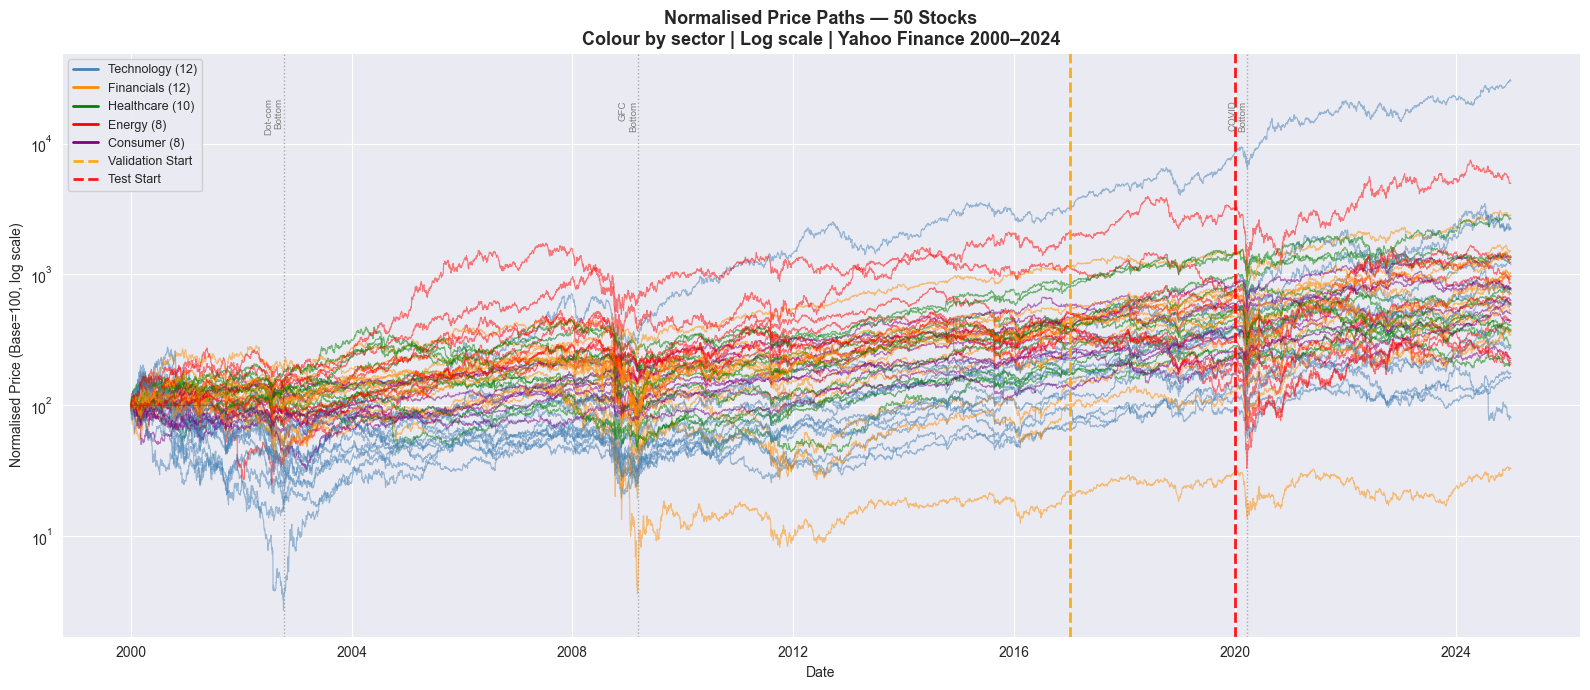

Plot 1 saved: price_paths.png


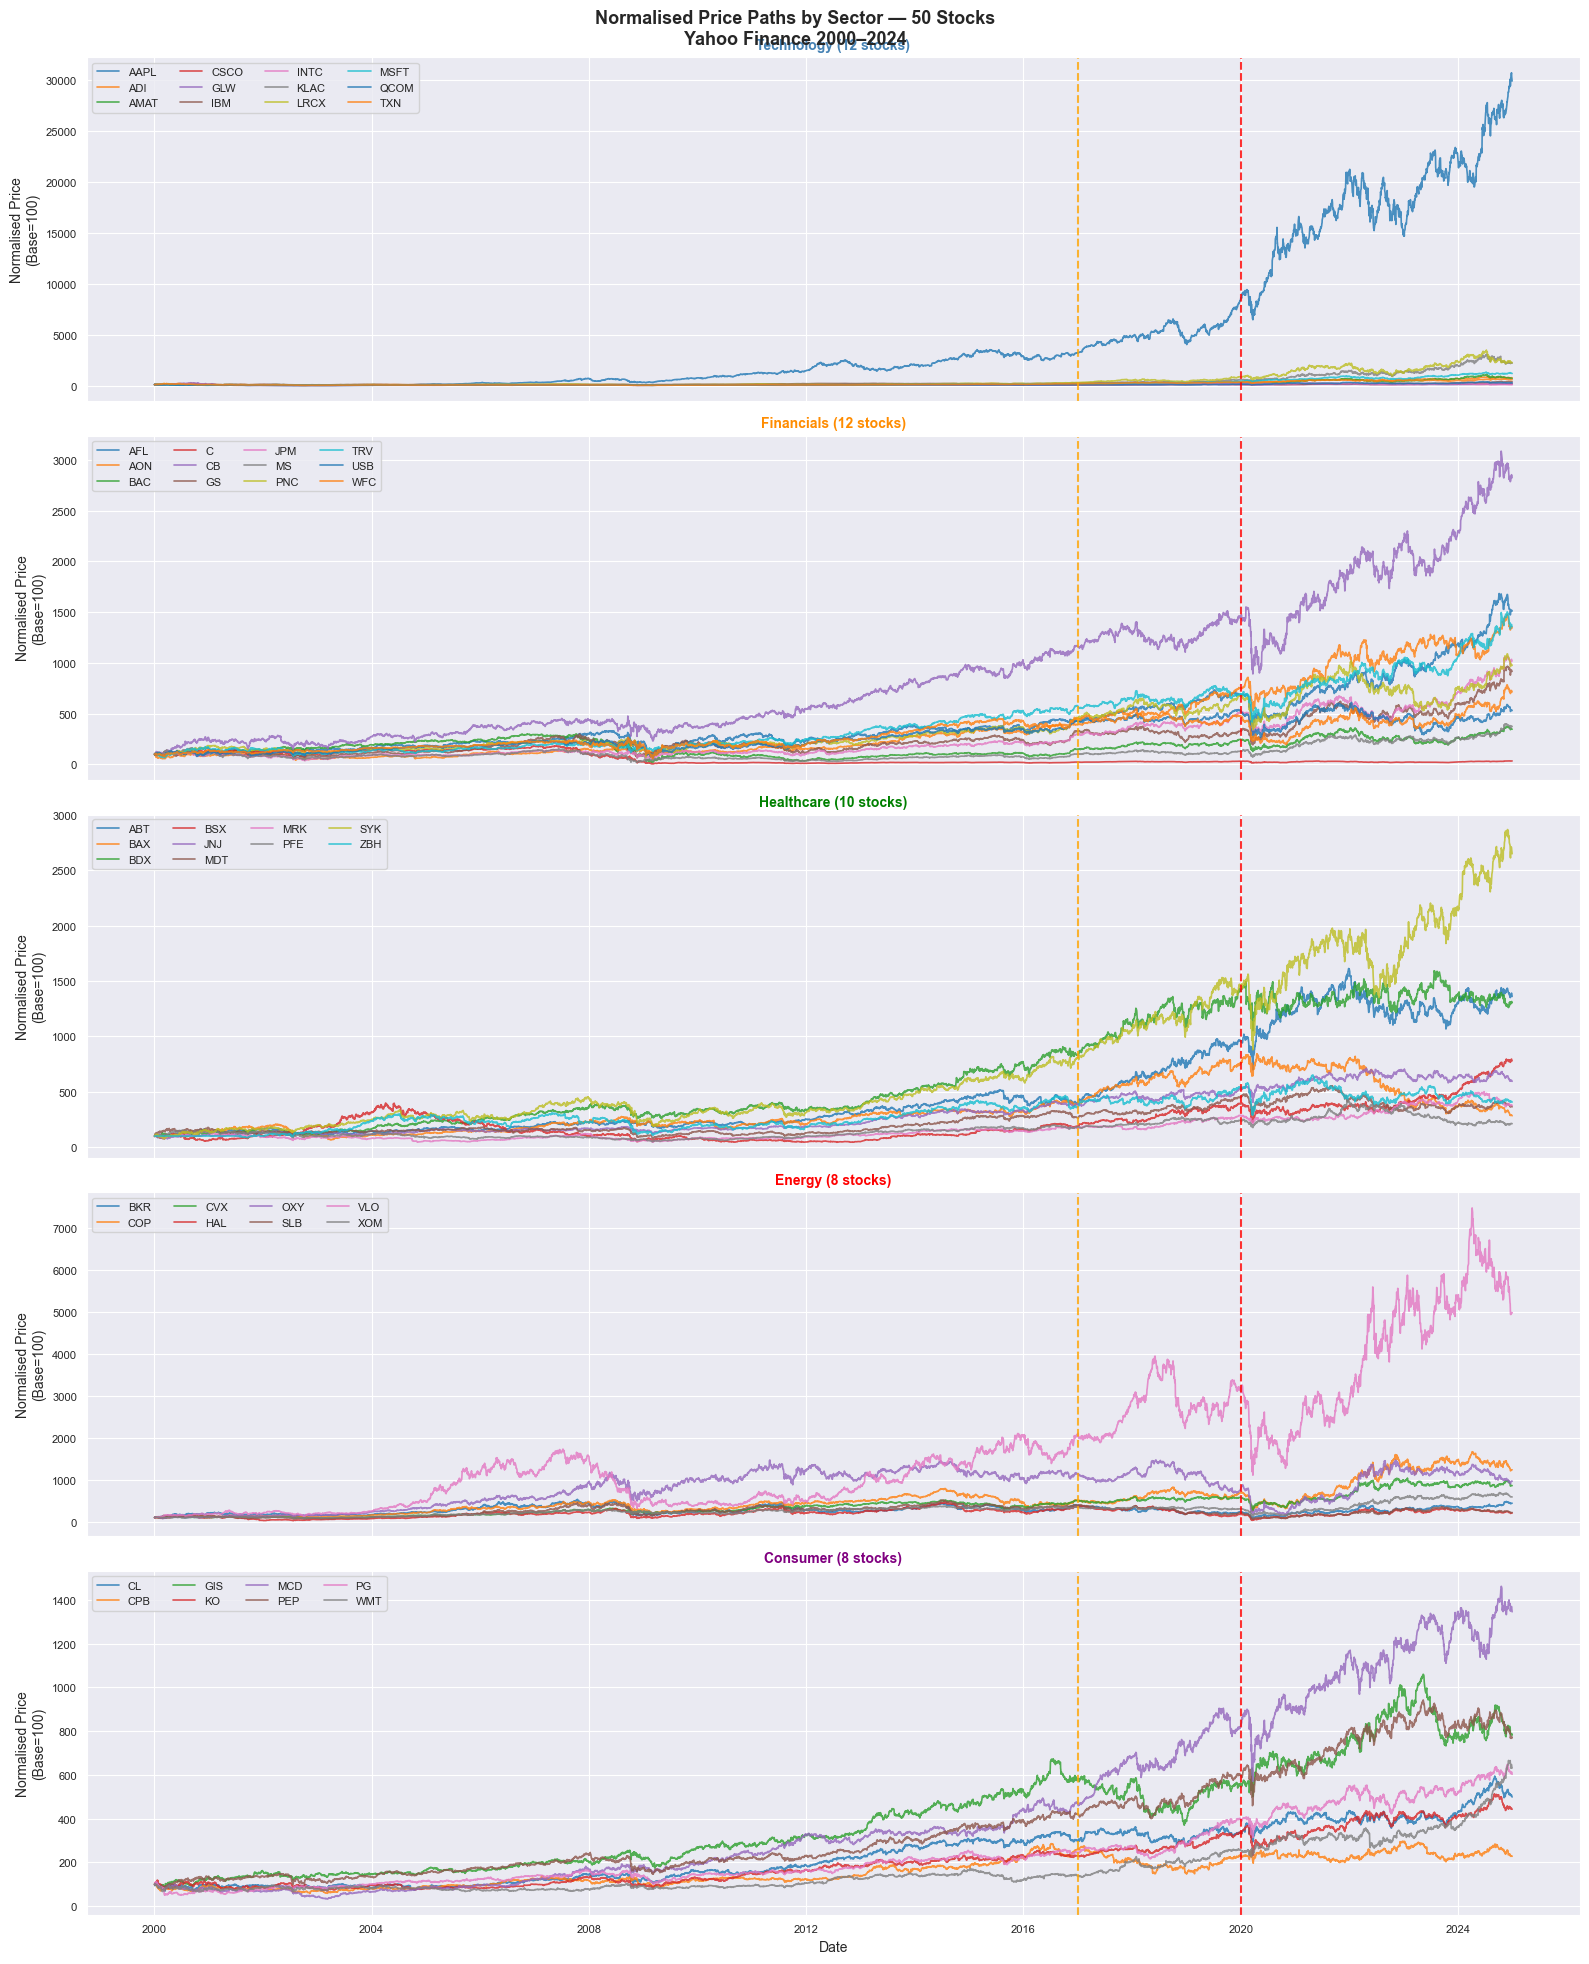

Plot 2 saved: price_paths_by_sector.png


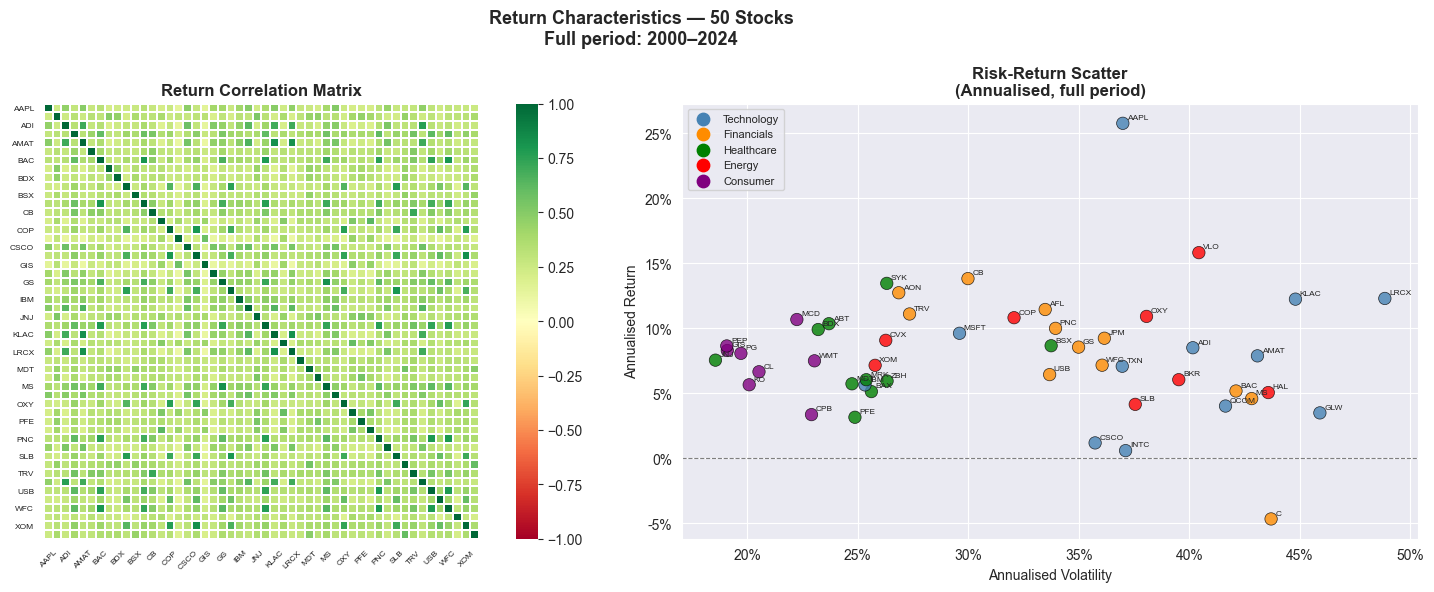

Plot 3 saved: return_characteristics.png

DATA SUMMARY:
──────────────────────────────────────────────────
  Asset pool       : 50 stocks
  Final N_ASSETS   : 50
  Total days       : 6,287
  Training days    : 4,276
  Validation days  : 754
  Test days        : 1,257
  Date range       : 2000-01-04 to 2024-12-30
──────────────────────────────────────────────────

Sector breakdown:
  Technology      : 12 stocks — ['AAPL', 'ADI', 'AMAT', 'CSCO', 'GLW', 'IBM', 'INTC', 'KLAC', 'LRCX', 'MSFT', 'QCOM', 'TXN']
  Financials      : 12 stocks — ['AFL', 'AON', 'BAC', 'C', 'CB', 'GS', 'JPM', 'MS', 'PNC', 'TRV', 'USB', 'WFC']
  Healthcare      : 10 stocks — ['ABT', 'BAX', 'BDX', 'BSX', 'JNJ', 'MDT', 'MRK', 'PFE', 'SYK', 'ZBH']
  Energy          :  8 stocks — ['BKR', 'COP', 'CVX', 'HAL', 'OXY', 'SLB', 'VLO', 'XOM']
  Consumer        :  8 stocks — ['CL', 'CPB', 'GIS', 'KO', 'MCD', 'PEP', 'PG', 'WMT']

Cell 7 complete


In [8]:
# ============================================================
# CELL 7: VISUALISE THE DATA
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style('darkgrid')

# ============================================================
# PLOT 1: NORMALISED PRICE PATHS (LOG SCALE)
# ============================================================

# Normalise all prices to 100 on first trading day
# Log scale used because AAPL's extreme growth
# would flatten all other stocks on a linear scale
normalised = (prices / prices.iloc[0]) * 100

fig1, ax1 = plt.subplots(figsize=(16, 7))

for ticker in normalised.columns:
    sector = SECTOR_MAP.get(ticker, 'Other')
    colour = SECTOR_COLOURS.get(sector, 'grey')
    ax1.plot(
        normalised.index,
        normalised[ticker],
        color=colour,
        linewidth=0.8,
        alpha=0.5
    )

# ---- Add sector legend ----
for sector, colour in SECTOR_COLOURS.items():
    # Only add to legend if sector is in our pool
    sector_tickers = [
        t for t in TICKERS
        if SECTOR_MAP.get(t) == sector
    ]
    if len(sector_tickers) > 0:
        ax1.plot(
            [], [],
            color=colour,
            linewidth=2,
            label=f'{sector} ({len(sector_tickers)})'
        )

# ---- Add split boundary lines ----
for date, label, colour in [
    ('2017-01-01', 'Validation Start', 'orange'),
    ('2020-01-01', 'Test Start',       'red'),
]:
    ax1.axvline(
        pd.Timestamp(date),
        color=colour,
        linewidth=2.0,
        linestyle='--',
        label=label,
        alpha=0.9
    )

# ---- Add market event markers ----
for date, label in [
    ('2002-10-09', 'Dot-com\nBottom'),
    ('2009-03-09', 'GFC\nBottom'),
    ('2020-03-23', 'COVID\nBottom'),
]:
    ax1.axvline(
        pd.Timestamp(date),
        color='grey',
        linewidth=1.0,
        linestyle=':',
        alpha=0.6
    )
    ax1.text(
        pd.Timestamp(date),
        ax1.get_ylim()[1] * 0.5
        if ax1.get_ylim()[1] > 0 else 1000,
        label,
        fontsize=7,
        color='grey',
        rotation=90,
        va='center',
        ha='right'
    )

ax1.set_yscale('log')
ax1.set_title(
    f'Normalised Price Paths — {DATA_POOL} Stocks\n'
    f'Colour by sector | Log scale | '
    f'Yahoo Finance 2000–2024',
    fontsize=13,
    fontweight='bold'
)
ax1.set_ylabel('Normalised Price (Base=100, log scale)')
ax1.set_xlabel('Date')
ax1.legend(
    fontsize=9,
    loc='upper left',
    framealpha=0.9
)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'price_paths.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Plot 1 saved: price_paths.png")

# ============================================================
# PLOT 2: SECTOR SUBPLOTS
# ============================================================

sectors_ordered = [
    'Technology',
    'Financials',
    'Healthcare',
    'Energy',
    'Consumer'
]

# Only include sectors present in current pool
sectors_to_plot = []
for sector in sectors_ordered:
    sector_tickers = [
        t for t in TICKERS
        if SECTOR_MAP.get(t) == sector
        and t in normalised.columns
    ]
    if len(sector_tickers) > 0:
        sectors_to_plot.append(
            (sector, sector_tickers))

n_sectors = len(sectors_to_plot)

fig2, axes2 = plt.subplots(
    n_sectors, 1,
    figsize=(16, 4 * n_sectors),
    sharex=True
)

if n_sectors == 1:
    axes2 = [axes2]

fig2.suptitle(
    f'Normalised Price Paths by Sector — '
    f'{DATA_POOL} Stocks\n'
    f'Yahoo Finance 2000–2024',
    fontsize=13,
    fontweight='bold'
)

for ax, (sector, sector_tickers) in zip(
    axes2, sectors_to_plot
):
    colour = SECTOR_COLOURS.get(sector, 'grey')

    for ticker in sector_tickers:
        ax.plot(
            normalised.index,
            normalised[ticker],
            linewidth=1.2,
            alpha=0.8,
            label=ticker
        )

    # Add split lines
    for date, split_colour, style in [
        ('2017-01-01', 'orange', '--'),
        ('2020-01-01', 'red',    '--'),
    ]:
        ax.axvline(
            pd.Timestamp(date),
            color=split_colour,
            linewidth=1.5,
            linestyle=style,
            alpha=0.8
        )

    ax.set_title(
        f'{sector} ({len(sector_tickers)} stocks)',
        fontweight='bold',
        color=colour,
        fontsize=10
    )
    ax.set_ylabel('Normalised Price\n(Base=100)')
    ax.legend(
        fontsize=8,
        loc='upper left',
        ncol=4,
        framealpha=0.8
    )
    ax.tick_params(labelsize=8)

axes2[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'price_paths_by_sector.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Plot 2 saved: price_paths_by_sector.png")

# ============================================================
# PLOT 3: RETURN DISTRIBUTION
# ============================================================

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle(
    f'Return Characteristics — {DATA_POOL} Stocks\n'
    f'Full period: 2000–2024',
    fontsize=13,
    fontweight='bold'
)

# ---- Left: Correlation heatmap ----
ax3a = axes3[0]
corr = log_returns.corr()

sns.heatmap(
    corr,
    annot=DATA_POOL <= 30,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.3,
    ax=ax3a,
    annot_kws={'size': 6}
)
ax3a.set_title(
    'Return Correlation Matrix',
    fontweight='bold'
)
ax3a.tick_params(
    axis='x', rotation=45, labelsize=6)
ax3a.tick_params(
    axis='y', rotation=0,  labelsize=6)

# ---- Right: Distribution of mean returns ----
ax3b = axes3[1]

mean_returns = log_returns.mean() * 252
std_returns  = log_returns.std() * np.sqrt(252)

ax3b.scatter(
    std_returns,
    mean_returns,
    c=[
        list(SECTOR_COLOURS.values())[
            list(SECTOR_COLOURS.keys()).index(
                SECTOR_MAP.get(t, 'Consumer')
            )
        ]
        for t in log_returns.columns
    ],
    alpha=0.8,
    s=80,
    edgecolors='black',
    linewidths=0.5
)

# Add ticker labels
for ticker in log_returns.columns:
    ax3b.annotate(
        ticker,
        (std_returns[ticker], mean_returns[ticker]),
        fontsize=6,
        xytext=(3, 3),
        textcoords='offset points'
    )

# Add sector legend
for sector, colour in SECTOR_COLOURS.items():
    sector_tickers = [
        t for t in TICKERS
        if SECTOR_MAP.get(t) == sector
    ]
    if len(sector_tickers) > 0:
        ax3b.scatter(
            [], [],
            color=colour,
            label=sector,
            s=80
        )

ax3b.set_title(
    'Risk-Return Scatter\n'
    '(Annualised, full period)',
    fontweight='bold'
)
ax3b.set_xlabel('Annualised Volatility')
ax3b.set_ylabel('Annualised Return')
ax3b.legend(fontsize=8, loc='upper left')
ax3b.axhline(y=0, color='black',
             linewidth=0.8, linestyle='--',
             alpha=0.5)

# Format axes as percentages
ax3b.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f'{x*100:.0f}%'))
ax3b.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f'{x*100:.0f}%'))

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER,
                 'return_characteristics.png'),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Plot 3 saved: return_characteristics.png")

# ============================================================
# DATA SUMMARY
# ============================================================

print(f"\nDATA SUMMARY:")
print(f"{'─'*50}")
print(f"  Asset pool       : {DATA_POOL} stocks")
print(f"  Final N_ASSETS   : {N_ASSETS}")
print(f"  Total days       : {len(log_returns):,}")
print(f"  Training days    : {len(train_returns):,}")
print(f"  Validation days  : {len(val_returns):,}")
print(f"  Test days        : {len(test_returns):,}")
print(f"  Date range       : "
      f"{log_returns.index[0].date()} to "
      f"{log_returns.index[-1].date()}")
print(f"{'─'*50}")

# Sector breakdown
print(f"\nSector breakdown:")
for sector in sectors_ordered:
    sector_tickers = [
        t for t in TICKERS
        if SECTOR_MAP.get(t) == sector
        and t in log_returns.columns
    ]
    if sector_tickers:
        print(f"  {sector:<15} : "
              f"{len(sector_tickers):>2} stocks "
              f"— {sector_tickers}")

print(f"\nCell 7 complete")

In [9]:
# ============================================================
# CELL 8: SAVE ALL DATA TO DISK
# ============================================================

import os
import json

# ---- Save cleaned prices ----
# Adjusted closing prices after cleaning
prices.to_csv(
    os.path.join(DATA_FOLDER, 'clean_prices.csv'))
print("Saved: clean_prices.csv")

# ---- Save full log returns ----
# Complete return series covering 2000-2024
# Used by robustness notebook for walk-forward
log_returns.to_csv(
    os.path.join(DATA_FOLDER, 'log_returns.csv'))
print("Saved: log_returns.csv")

# ---- Save each split separately ----
# Later sections load these directly
# Keeping splits separate prevents accidental
# data leakage during signature computation
train_returns.to_csv(
    os.path.join(DATA_FOLDER, 'train_returns.csv'))
print("Saved: train_returns.csv")

val_returns.to_csv(
    os.path.join(DATA_FOLDER, 'val_returns.csv'))
print("Saved: val_returns.csv")

test_returns.to_csv(
    os.path.join(DATA_FOLDER, 'test_returns.csv'))
print("Saved: test_returns.csv")

# ---- Save configuration as JSON ----
# This stores all key settings in one place
# Later sections load this to stay consistent
# with whatever DATA_POOL was set in Cell 1
config = {
    'DATA_POOL'   : DATA_POOL,
    'DATA_FOLDER' : DATA_FOLDER,
    'SIG_FOLDER'  : SIG_FOLDER,
    'MODELS_FOLDER': MODELS_FOLDER,
    'ROBUST_FOLDER': ROBUST_FOLDER,
    'N_ASSETS'    : N_ASSETS,
    'TICKERS'     : TICKERS,
    'LOOKBACK'    : LOOKBACK,
    'SIG_ORDER'   : SIG_ORDER,
    'TRAIN_START' : TRAIN_START,
    'TRAIN_END'   : TRAIN_END,
    'VAL_START'   : VAL_START,
    'VAL_END'     : VAL_END,
    'TEST_START'  : TEST_START,
    'TEST_END'    : TEST_END,
}

config_path = os.path.join(
    DATA_FOLDER, 'config.json')

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print("Saved: config.json")

# ---- Verify all files exist ----
print(f"\nVerifying saved files in {DATA_FOLDER}/:")
expected_files = [
    'clean_prices.csv',
    'log_returns.csv',
    'train_returns.csv',
    'val_returns.csv',
    'test_returns.csv',
    'config.json',
]

all_saved = True
for filename in expected_files:
    filepath = os.path.join(DATA_FOLDER, filename)
    exists   = os.path.exists(filepath)
    size_kb  = (
        os.path.getsize(filepath) / 1024
        if exists else 0
    )
    status   = "OK" if exists else "MISSING"
    print(f"  {status} {filename} "
          f"({size_kb:.1f} KB)")
    if not exists:
        all_saved = False

if all_saved:
    print(f"\nAll files saved successfully")
else:
    print(f"\nWARNING: Some files are missing")

# ---- Final summary ----
print(f"\n{'='*50}")
print(f"  SECTION 1 COMPLETE — DATA COLLECTION")
print(f"{'='*50}")
print(f"  Asset pool   : {DATA_POOL} stocks")
print(f"  N_ASSETS     : {N_ASSETS}")
print(f"  Training     : {len(train_returns):,} days")
print(f"  Validation   : {len(val_returns):,} days")
print(f"  Test         : {len(test_returns):,} days")
print(f"{'='*50}")
print(f"\nNext: Cell 9 — Path Signature Computation")

Saved: clean_prices.csv
Saved: log_returns.csv
Saved: train_returns.csv
Saved: val_returns.csv
Saved: test_returns.csv
Saved: config.json

Verifying saved files in data_paper_50/:
  OK clean_prices.csv (5679.5 KB)
  OK log_returns.csv (6613.8 KB)
  OK train_returns.csv (4488.4 KB)
  OK val_returns.csv (798.6 KB)
  OK test_returns.csv (1327.2 KB)
  OK config.json (1.0 KB)

All files saved successfully

  SECTION 1 COMPLETE — DATA COLLECTION
  Asset pool   : 50 stocks
  N_ASSETS     : 50
  Training     : 4,276 days
  Validation   : 754 days
  Test         : 1,257 days

Next: Cell 9 — Path Signature Computation


In [10]:
# ============================================================
# CELL 9: COMPUTE PATH SIGNATURE FEATURES
# ============================================================
# SECTION 2: PATH SIGNATURES
#
# What is a path signature?
# A path signature transforms a time series into a
# collection of numbers called iterated integrals
# These numbers capture:
#   - Total move of each asset (first order terms)
#   - How assets moved relative to each other and
#     in what ORDER (second order terms)
#   - Three-way interactions between assets
#     (third order terms)
#
# Why use signatures instead of raw returns?
# Raw returns tell you WHERE prices ended up
# Signatures tell you the SHAPE of the journey
# For example: "Asset A rose then Asset B fell"
# is captured differently from
# "Asset B fell then Asset A rose"
# This ordering information is lost in raw returns
# but preserved in path signatures
#
# Implementation:
# For each trading day t we take the last LOOKBACK
# days of returns and compute the signature of that
# rolling window path
# LOOKBACK = 20 days (set in Cell 1)
# SIG_ORDER = 3 (set in Cell 1)

import iisignature
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import os
import pickle

# ---- Compute signature feature vector size ----
# For d assets and order M the number of terms is:
# (d^(M+1) - 1) / (d - 1) - 1
d        = N_ASSETS
M        = SIG_ORDER
n_terms  = int((d**(M+1) - 1) / (d - 1)) - 1

print(f"{'='*55}")
print(f"  SECTION 2: PATH SIGNATURE COMPUTATION")
print(f"{'='*55}")
print(f"  Assets (d)          : {d}")
print(f"  Signature order (M) : {M}")
print(f"  Lookback window     : {LOOKBACK} days")
print(f"  Feature vector size : {n_terms:,} terms")
print(f"{'='*55}")
print(f"\nThis may take 5-15 minutes for large pools")
print(f"Progress will be shown for each split\n")

# ---- Define sliding window function ----
def compute_signature_features(
    returns_df,
    lookback=LOOKBACK,
    sig_order=SIG_ORDER,
    split_name='split'
):
    """
    Compute path signature features using a sliding window.

    For each day t starting from day lookback:
    1. Extract returns from day t-lookback to day t
    2. Convert to cumulative path via running sum
       Signatures work better on smooth cumulative
       paths than on raw return jumps
    3. Compute truncated signature of that path
    4. Store as one row of the feature matrix

    Parameters
    ----------
    returns_df : pd.DataFrame
        Daily log returns shape (T, N_ASSETS)
    lookback : int
        Number of days in each sliding window
    sig_order : int
        Truncation order for signature computation
    split_name : str
        Name for progress printing

    Returns
    -------
    features : np.ndarray
        Shape (T - lookback, n_sig_terms)
    dates : pd.DatetimeIndex
        Dates for each window end point
    """
    returns_array = returns_df.values
    T             = returns_array.shape[0]
    d             = returns_array.shape[1]

    # Pre-compute number of signature terms
    n_sig_terms = int(
        (d**(sig_order+1) - 1) / (d - 1)) - 1

    # Number of windows to compute
    n_windows = T - lookback

    # Pre-allocate output array
    features = np.zeros((n_windows, n_sig_terms))

    print(f"  Computing {split_name}: "
          f"{n_windows} windows...")

    # Loop over each sliding window
    for i in range(n_windows):

        # Extract window: rows i to i+lookback
        window = returns_array[i:i + lookback]

        # Convert to cumulative path
        # Running sum makes the path smooth
        # which is better suited for signature
        # computation than raw jumpy returns
        cumulative_path = np.cumsum(window, axis=0)

        # Compute truncated signature
        sig            = iisignature.sig(
            cumulative_path, sig_order)
        features[i]    = sig

        # Print progress every 500 windows
        if (i + 1) % 500 == 0:
            pct = (i + 1) / n_windows * 100
            print(f"    {i+1}/{n_windows} "
                  f"({pct:.0f}%)")

    # Dates correspond to window end points
    dates = returns_df.index[lookback:]

    print(f"  {split_name} complete — "
          f"shape: {features.shape}")

    return features, dates


# ---- Compute signatures for all three splits ----

print("Computing training signatures...")
train_features, train_dates = \
    compute_signature_features(
        train_returns,
        split_name='Training'
    )

print("\nComputing validation signatures...")
val_features, val_dates = \
    compute_signature_features(
        val_returns,
        split_name='Validation'
    )

print("\nComputing test signatures...")
test_features, test_dates = \
    compute_signature_features(
        test_returns,
        split_name='Test'
    )

# ---- Print summary ----
print(f"\nSIGNATURE COMPUTATION COMPLETE:")
print(f"{'─'*50}")
print(f"  Training features   : {train_features.shape}")
print(f"  Validation features : {val_features.shape}")
print(f"  Test features       : {test_features.shape}")
print(f"  Feature vector size : {train_features.shape[1]:,}")
print(f"{'─'*50}")
print(f"\nCell 9 complete")

  SECTION 2: PATH SIGNATURE COMPUTATION
  Assets (d)          : 50
  Signature order (M) : 2
  Lookback window     : 20 days
  Feature vector size : 2,550 terms

This may take 5-15 minutes for large pools
Progress will be shown for each split

Computing training signatures...
  Computing Training: 4256 windows...
    500/4256 (12%)
    1000/4256 (23%)
    1500/4256 (35%)
    2000/4256 (47%)
    2500/4256 (59%)
    3000/4256 (70%)
    3500/4256 (82%)
    4000/4256 (94%)
  Training complete — shape: (4256, 2550)

Computing validation signatures...
  Computing Validation: 734 windows...
    500/734 (68%)
  Validation complete — shape: (734, 2550)

Computing test signatures...
  Computing Test: 1237 windows...
    500/1237 (40%)
    1000/1237 (81%)
  Test complete — shape: (1237, 2550)

SIGNATURE COMPUTATION COMPLETE:
──────────────────────────────────────────────────
  Training features   : (4256, 2550)
  Validation features : (734, 2550)
  Test features       : (1237, 2550)
  Feature vec

In [11]:
# ============================================================
# CELL 10: NORMALISE AND ALIGN SIGNATURE FEATURES
# ============================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ============================================================
# PART A: NORMALISE FEATURES
# ============================================================

# Neural networks train much better when input features
# are on a similar scale — typically mean 0 and std 1
# This is called standardisation or z-score normalisation
#
# IMPORTANT RULE — fit on training data only
# We compute mean and std ONLY from the training set
# then apply those same values to validation and test
# If we used test set statistics here it would be
# data leakage — the model would indirectly see
# future information during training

print(f"{'='*55}")
print(f"  PART A: FEATURE NORMALISATION")
print(f"{'='*55}")

# Create StandardScaler
# This learns mean and std from training data
scaler = StandardScaler()

# Fit on training data and transform it in one step
# fit_transform learns the statistics AND applies them
train_features_scaled = scaler.fit_transform(
    train_features)

# Transform validation using TRAINING statistics only
# We use transform (not fit_transform) — critical
val_features_scaled   = scaler.transform(
    val_features)

# Transform test using TRAINING statistics only
test_features_scaled  = scaler.transform(
    test_features)

# ---- Verify normalisation ----
print(f"Normalisation verification:")
print(f"  Training   — mean: "
      f"{train_features_scaled.mean():.6f} "
      f"std: {train_features_scaled.std():.6f}")
print(f"  Validation — mean: "
      f"{val_features_scaled.mean():.6f} "
      f"std: {val_features_scaled.std():.6f}")
print(f"  Test       — mean: "
      f"{test_features_scaled.mean():.6f} "
      f"std: {test_features_scaled.std():.6f}")
print(f"\nTraining mean and std should be ~0 and ~1")
print(f"Val and test will be close but not exact")
print(f"because they use training statistics")

# ============================================================
# PART B: ALIGN RETURNS WITH FEATURES
# ============================================================

# The signature feature for day t uses returns from
# day t-LOOKBACK to day t to predict weights for day t
# The portfolio then earns the return on day t+1
#
# Therefore we need to align:
#   features[t]  →  returns[t+1]
#
# The sliding window starts from day LOOKBACK
# Features cover days LOOKBACK to T-1
# Corresponding next-day returns: LOOKBACK+1 to T

print(f"\n{'='*55}")
print(f"  PART B: ALIGNING RETURNS WITH FEATURES")
print(f"{'='*55}")

# ---- Training alignment ----
# Returns: skip first LOOKBACK+1 rows
# Features: drop last row to match
train_returns_aligned = train_returns.iloc[
    LOOKBACK+1:].values
train_features_final  = train_features_scaled[:-1]
train_dates_final     = train_dates[:-1]

# ---- Validation alignment ----
val_returns_aligned = val_returns.iloc[
    LOOKBACK+1:].values
val_features_final  = val_features_scaled[:-1]
val_dates_final     = val_dates[:-1]

# ---- Test alignment ----
test_returns_aligned = test_returns.iloc[
    LOOKBACK+1:].values
test_features_final  = test_features_scaled[:-1]
test_dates_final     = test_dates[:-1]

# ---- Verify alignment ----
print(f"Alignment verification:")
print(f"  Training   — features: "
      f"{train_features_final.shape} "
      f"returns: {train_returns_aligned.shape}")
print(f"  Validation — features: "
      f"{val_features_final.shape} "
      f"returns: {val_returns_aligned.shape}")
print(f"  Test       — features: "
      f"{test_features_final.shape} "
      f"returns: {test_returns_aligned.shape}")

# ---- Assert shapes match ----
# First dimension of features and returns
# must be identical for each split
assert train_features_final.shape[0] == \
    train_returns_aligned.shape[0], \
    "Training alignment failed"
assert val_features_final.shape[0] == \
    val_returns_aligned.shape[0], \
    "Validation alignment failed"
assert test_features_final.shape[0] == \
    test_returns_aligned.shape[0], \
    "Test alignment failed"

print(f"\nAll alignment checks passed")

print(f"\nCell 10 complete")

  PART A: FEATURE NORMALISATION
Normalisation verification:
  Training   — mean: 0.000000 std: 1.000000
  Validation — mean: -0.065317 std: 0.500567
  Test       — mean: 0.072293 std: 1.401784

Training mean and std should be ~0 and ~1
Val and test will be close but not exact
because they use training statistics

  PART B: ALIGNING RETURNS WITH FEATURES
Alignment verification:
  Training   — features: (4255, 2550) returns: (4255, 50)
  Validation — features: (733, 2550) returns: (733, 50)
  Test       — features: (1236, 2550) returns: (1236, 50)

All alignment checks passed

Cell 10 complete


In [12]:
# ============================================================
# CELL 11: SAVE SIGNATURE FEATURES TO DISK
# ============================================================

import numpy as np
import pandas as pd
import pickle
import os

# ---- Save signature features as numpy arrays ----
# We use numpy .npy format which is much faster
# than CSV for large numerical arrays
# Loading a .npy file is nearly instantaneous
# compared to parsing a large CSV

print(f"{'='*55}")
print(f"  SAVING SIGNATURE FEATURES")
print(f"{'='*55}")

# ---- Save features ----
np.save(
    os.path.join(SIG_FOLDER, 'train_features.npy'),
    train_features_final
)
print(f"Saved: train_features.npy  "
      f"{train_features_final.shape}")

np.save(
    os.path.join(SIG_FOLDER, 'val_features.npy'),
    val_features_final
)
print(f"Saved: val_features.npy    "
      f"{val_features_final.shape}")

np.save(
    os.path.join(SIG_FOLDER, 'test_features.npy'),
    test_features_final
)
print(f"Saved: test_features.npy   "
      f"{test_features_final.shape}")

# ---- Save aligned returns ----
np.save(
    os.path.join(SIG_FOLDER,
                 'train_returns_aligned.npy'),
    train_returns_aligned
)
print(f"Saved: train_returns_aligned.npy  "
      f"{train_returns_aligned.shape}")

np.save(
    os.path.join(SIG_FOLDER,
                 'val_returns_aligned.npy'),
    val_returns_aligned
)
print(f"Saved: val_returns_aligned.npy    "
      f"{val_returns_aligned.shape}")

np.save(
    os.path.join(SIG_FOLDER,
                 'test_returns_aligned.npy'),
    test_returns_aligned
)
print(f"Saved: test_returns_aligned.npy   "
      f"{test_returns_aligned.shape}")

# ---- Save dates ----
# Numpy cannot store datetime objects natively
# so we save dates as CSV files
pd.Series(
    train_dates_final.values,
    name='date'
).to_csv(
    os.path.join(SIG_FOLDER, 'train_dates.csv'),
    index=False
)
print(f"Saved: train_dates.csv")

pd.Series(
    val_dates_final.values,
    name='date'
).to_csv(
    os.path.join(SIG_FOLDER, 'val_dates.csv'),
    index=False
)
print(f"Saved: val_dates.csv")

pd.Series(
    test_dates_final.values,
    name='date'
).to_csv(
    os.path.join(SIG_FOLDER, 'test_dates.csv'),
    index=False
)
print(f"Saved: test_dates.csv")

# ---- Save scaler ----
# We save the fitted scaler so it can be reused
# in robustness testing without refitting
# Refitting on different data would change the
# normalisation statistics and make results
# incomparable across runs
with open(
    os.path.join(SIG_FOLDER, 'scaler.pkl'), 'wb'
) as f:
    pickle.dump(scaler, f)
print(f"Saved: scaler.pkl")

# ---- Save key dimensions ----
# Store N_FEATURES for use in model definition
N_FEATURES = train_features_final.shape[1]

sig_config = {
    'N_FEATURES'  : N_FEATURES,
    'N_ASSETS'    : N_ASSETS,
    'LOOKBACK'    : LOOKBACK,
    'SIG_ORDER'   : SIG_ORDER,
    'train_shape' : list(train_features_final.shape),
    'val_shape'   : list(val_features_final.shape),
    'test_shape'  : list(test_features_final.shape),
}

import json
with open(
    os.path.join(SIG_FOLDER, 'sig_config.json'), 'w'
) as f:
    json.dump(sig_config, f, indent=2)
print(f"Saved: sig_config.json")

# ---- Verify all files exist ----
print(f"\nVerifying saved files in {SIG_FOLDER}/:")
expected_files = [
    'train_features.npy',
    'val_features.npy',
    'test_features.npy',
    'train_returns_aligned.npy',
    'val_returns_aligned.npy',
    'test_returns_aligned.npy',
    'train_dates.csv',
    'val_dates.csv',
    'test_dates.csv',
    'scaler.pkl',
    'sig_config.json',
]

all_saved = True
for filename in expected_files:
    filepath = os.path.join(SIG_FOLDER, filename)
    exists   = os.path.exists(filepath)
    size_kb  = (
        os.path.getsize(filepath) / 1024
        if exists else 0
    )
    status = "OK" if exists else "MISSING"
    print(f"  {status} {filename} "
          f"({size_kb:.1f} KB)")
    if not exists:
        all_saved = False

if all_saved:
    print(f"\nAll files saved successfully")
else:
    print(f"\nWARNING: Some files missing")

# ---- Final summary ----
print(f"\n{'='*55}")
print(f"  SECTION 2 COMPLETE — PATH SIGNATURES")
print(f"{'='*55}")
print(f"  N_FEATURES     : {N_FEATURES:,}")
print(f"  N_ASSETS       : {N_ASSETS}")
print(f"  SIG_ORDER      : {SIG_ORDER}")
print(f"  LOOKBACK       : {LOOKBACK} days")
print(f"  Train samples  : {train_features_final.shape[0]:,}")
print(f"  Val samples    : {val_features_final.shape[0]:,}")
print(f"  Test samples   : {test_features_final.shape[0]:,}")
print(f"{'='*55}")
print(f"\nNext: Cell 12 — Define SIT Model")

  SAVING SIGNATURE FEATURES
Saved: train_features.npy  (4255, 2550)
Saved: val_features.npy    (733, 2550)
Saved: test_features.npy   (1236, 2550)
Saved: train_returns_aligned.npy  (4255, 50)
Saved: val_returns_aligned.npy    (733, 50)
Saved: test_returns_aligned.npy   (1236, 50)
Saved: train_dates.csv
Saved: val_dates.csv
Saved: test_dates.csv
Saved: scaler.pkl
Saved: sig_config.json

Verifying saved files in data_paper_50\signatures/:
  OK train_features.npy (84767.7 KB)
  OK val_features.npy (14602.9 KB)
  OK test_features.npy (24623.6 KB)
  OK train_returns_aligned.npy (1662.2 KB)
  OK val_returns_aligned.npy (286.5 KB)
  OK test_returns_aligned.npy (482.9 KB)
  OK train_dates.csv (49.9 KB)
  OK val_dates.csv (8.6 KB)
  OK test_dates.csv (14.5 KB)
  OK scaler.pkl (60.2 KB)
  OK sig_config.json (0.2 KB)

All files saved successfully

  SECTION 2 COMPLETE — PATH SIGNATURES
  N_FEATURES     : 2,550
  N_ASSETS       : 50
  SIG_ORDER      : 2
  LOOKBACK       : 20 days
  Train samples  

In [13]:
# ============================================================
# CELL 12: DEFINE THE SIT MODEL ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import json
import os
import random

# ============================================================
# SAFETY BLOCK — reload everything if missing
# ============================================================

# ---- Redefine set_all_seeds if missing ----
try:
    set_all_seeds
except NameError:
    def set_all_seeds(seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['PYTHONHASHSEED'] = str(seed)
        print(f"Seeds set to {seed}")
    print("set_all_seeds redefined")

# ---- Redefine GLOBAL_SEED if missing ----
try:
    GLOBAL_SEED
except NameError:
    GLOBAL_SEED = 42
    print(f"GLOBAL_SEED set to {GLOBAL_SEED}")

# ---- Redefine DEVICE if missing ----
try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'cpu')
    print(f"DEVICE set to {DEVICE}")

# ---- Reload DATA_FOLDER if missing ----
try:
    DATA_FOLDER
except NameError:
    DATA_FOLDER = 'data_paper_50'
    print(f"DATA_FOLDER set to {DATA_FOLDER}")

# ---- Reload SIG_FOLDER if missing ----
try:
    SIG_FOLDER
except NameError:
    SIG_FOLDER = os.path.join(
        DATA_FOLDER, 'signatures')
    print(f"SIG_FOLDER set to {SIG_FOLDER}")

# ---- Reload MODELS_FOLDER if missing ----
try:
    MODELS_FOLDER
except NameError:
    MODELS_FOLDER = os.path.join(
        DATA_FOLDER, 'models')
    if not os.path.exists(MODELS_FOLDER):
        os.makedirs(MODELS_FOLDER)
    print(f"MODELS_FOLDER set to {MODELS_FOLDER}")

# ---- Reload N_FEATURES and N_ASSETS ----
try:
    N_FEATURES
    N_ASSETS
except NameError:
    sig_config_path = os.path.join(
        SIG_FOLDER, 'sig_config.json')
    if os.path.exists(sig_config_path):
        with open(sig_config_path) as f:
            sig_config = json.load(f)
        N_FEATURES = sig_config['N_FEATURES']
        N_ASSETS   = sig_config['N_ASSETS']
        print(f"N_FEATURES loaded: {N_FEATURES}")
        print(f"N_ASSETS loaded  : {N_ASSETS}")
    else:
        print(f"ERROR: {sig_config_path} not found")
        print("Please run Cells 9-11 first")
        raise FileNotFoundError(sig_config_path)

# ---- Reload model hyperparameters ----
try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
    BATCH_SIZE
except NameError:
    D_MODEL    = 64
    N_HEADS    = 4
    N_LAYERS   = 2
    DROPOUT    = 0.1
    BATCH_SIZE = 64
    print(f"Model hyperparameters set to defaults")
    print(f"  D_MODEL    : {D_MODEL}")
    print(f"  N_HEADS    : {N_HEADS}")
    print(f"  N_LAYERS   : {N_LAYERS}")
    print(f"  DROPOUT    : {DROPOUT}")
    print(f"  BATCH_SIZE : {BATCH_SIZE}")

# ---- Reload DATA_POOL if missing ----
try:
    DATA_POOL
except NameError:
    config_path = os.path.join(
        DATA_FOLDER, 'config.json')
    if os.path.exists(config_path):
        with open(config_path) as f:
            config = json.load(f)
        DATA_POOL = config['DATA_POOL']
        print(f"DATA_POOL loaded: {DATA_POOL}")
    else:
        DATA_POOL = 50
        print(f"DATA_POOL defaulted to {DATA_POOL}")

# ---- Print confirmed values ----
print(f"\nAll variables confirmed:")
print(f"  N_FEATURES    : {N_FEATURES}")
print(f"  N_ASSETS      : {N_ASSETS}")
print(f"  D_MODEL       : {D_MODEL}")
print(f"  N_HEADS       : {N_HEADS}")
print(f"  N_LAYERS      : {N_LAYERS}")
print(f"  DROPOUT       : {DROPOUT}")
print(f"  BATCH_SIZE    : {BATCH_SIZE}")
print(f"  DEVICE        : {DEVICE}")
print(f"  GLOBAL_SEED   : {GLOBAL_SEED}")

# ============================================================
# SIT MODEL CLASS
# ============================================================

class SIT(nn.Module):
    """
    Signature-Informed Transformer for Portfolio Allocation.

    Replication of Hwang and Zohren (2025).
    Trained end-to-end using a single risk objective
    applied directly to portfolio returns.
    No separate return forecasting stage.

    Architecture:
    1. Input projection  — signature features → d_model
    2. Transformer encoder — multi-head self-attention
    3. Output projection — d_model → n_assets
    4. Softmax           — raw scores → portfolio weights
    """

    def __init__(
        self,
        n_features,
        n_assets,
        d_model=64,
        n_heads=4,
        n_layers=2,
        dropout=0.1
    ):
        """
        Parameters
        ----------
        n_features : int
            Size of input signature feature vector
        n_assets : int
            Number of stocks — also the output size
        d_model : int
            Internal Transformer dimension
        n_heads : int
            Number of parallel attention heads
        n_layers : int
            Number of stacked Transformer layers
        dropout : float
            Dropout rate for regularisation
        """

        super(SIT, self).__init__()

        self.n_features = n_features
        self.n_assets   = n_assets
        self.d_model    = d_model

        # ---- Layer 1: Input Projection ----
        # Projects large signature feature vector
        # down to model dimension
        # Learns which signature combinations matter
        self.input_projection = nn.Linear(
            n_features, d_model)

        # ---- Layer 2: Transformer Encoder ----
        # Multi-head self-attention
        # batch_first=True — input is
        # (batch, sequence, features)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = n_heads,
            dim_feedforward = 4 * d_model,
            dropout         = dropout,
            batch_first     = True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # ---- Layer 3: Output Projection ----
        # Maps model dimension to number of assets
        self.output_projection = nn.Linear(
            d_model, n_assets)

        # ---- Layer 4: Softmax ----
        # Converts raw scores to portfolio weights
        # All weights positive and sum to 1
        self.softmax = nn.Softmax(dim=1)

        # ---- Weight Initialisation ----
        self._initialise_weights()

    def _initialise_weights(self):
        """
        Xavier uniform weight initialisation.
        Keeps gradients at a stable scale
        at the start of training.
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        """
        Forward pass: features → portfolio weights.

        Parameters
        ----------
        x : torch.Tensor
            Shape (batch_size, n_features)

        Returns
        -------
        weights : torch.Tensor
            Shape (batch_size, n_assets)
            Positive, summing to 1 per sample
        """

        # Step 1: Project to model dimension
        # (batch, n_features) → (batch, d_model)
        x = self.input_projection(x)

        # Step 2: Add sequence dimension
        # (batch, d_model) → (batch, 1, d_model)
        x = x.unsqueeze(1)

        # Step 3: Transformer encoder
        # (batch, 1, d_model) → (batch, 1, d_model)
        x = self.transformer_encoder(x)

        # Step 4: Remove sequence dimension
        # (batch, 1, d_model) → (batch, d_model)
        x = x.squeeze(1)

        # Step 5: Project to asset dimension
        # (batch, d_model) → (batch, n_assets)
        x = self.output_projection(x)

        # Step 6: Softmax → portfolio weights
        weights = self.softmax(x)

        return weights


# ============================================================
# TEST MODEL INSTANTIATION
# ============================================================

set_all_seeds(GLOBAL_SEED)

test_model = SIT(
    n_features = N_FEATURES,
    n_assets   = N_ASSETS,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    dropout    = DROPOUT
).to(DEVICE)

# ---- Print architecture ----
print(f"\n{'='*55}")
print(f"  SIT MODEL ARCHITECTURE")
print(f"{'='*55}")
print(test_model)
print(f"{'='*55}")

# ---- Count parameters ----
total_params = sum(
    p.numel()
    for p in test_model.parameters()
    if p.requires_grad
)
print(f"\nTotal trainable parameters: {total_params:,}")

# ---- Test forward pass ----
dummy_input = torch.randn(
    BATCH_SIZE, N_FEATURES).to(DEVICE)

with torch.no_grad():
    dummy_output = test_model(dummy_input)

print(f"\nForward pass test:")
print(f"  Input shape  : {dummy_input.shape}")
print(f"  Output shape : {dummy_output.shape}")
print(f"  Weight sum   : "
      f"{dummy_output.sum(dim=1).mean():.6f} "
      f"(should be ~1.0)")
print(f"  Min weight   : "
      f"{dummy_output.min():.6f} "
      f"(should be > 0)")

# ---- Clean up test model ----
del test_model, dummy_input, dummy_output

print(f"\nSIT class defined successfully")
print(f"\nCell 12 complete")


All variables confirmed:
  N_FEATURES    : 2550
  N_ASSETS      : 50
  D_MODEL       : 64
  N_HEADS       : 4
  N_LAYERS      : 2
  DROPOUT       : 0.1
  BATCH_SIZE    : 64
  DEVICE        : cpu
  GLOBAL_SEED   : 42
All seeds locked to: 42

  SIT MODEL ARCHITECTURE
SIT(
  (input_projection): Linear(in_features=2550, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (d

In [14]:
# ============================================================
# CELL 13: DEFINE DATASET AND DATALOADERS
# ============================================================

import torch
import numpy as np
import os
from torch.utils.data import DataLoader, Dataset

# ---- Safety checks ----
try:
    N_FEATURES
    N_ASSETS
    BATCH_SIZE
    SIG_FOLDER
except NameError:
    import json
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(
        DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(
        DATA_FOLDER, 'models')
    BATCH_SIZE    = 64
    with open(os.path.join(
        SIG_FOLDER, 'sig_config.json'
    )) as f:
        sig_config  = json.load(f)
    N_FEATURES  = sig_config['N_FEATURES']
    N_ASSETS    = sig_config['N_ASSETS']
    print("Variables reloaded from config")

# ---- Reload aligned arrays if missing ----
try:
    train_features_final
    val_features_final
    test_features_final
    train_returns_aligned
    val_returns_aligned
    test_returns_aligned
except NameError:
    print("Reloading arrays from disk...")
    train_features_final  = np.load(
        os.path.join(SIG_FOLDER,
                     'train_features.npy'))
    val_features_final    = np.load(
        os.path.join(SIG_FOLDER,
                     'val_features.npy'))
    test_features_final   = np.load(
        os.path.join(SIG_FOLDER,
                     'test_features.npy'))
    train_returns_aligned = np.load(
        os.path.join(SIG_FOLDER,
                     'train_returns_aligned.npy'))
    val_returns_aligned   = np.load(
        os.path.join(SIG_FOLDER,
                     'val_returns_aligned.npy'))
    test_returns_aligned  = np.load(
        os.path.join(SIG_FOLDER,
                     'test_returns_aligned.npy'))
    print("Arrays reloaded successfully")
    print(f"  train_features : "
          f"{train_features_final.shape}")
    print(f"  val_features   : "
          f"{val_features_final.shape}")
    print(f"  test_features  : "
          f"{test_features_final.shape}")

# ---- Reload dates if missing ----
try:
    train_dates_final
    val_dates_final
    test_dates_final
except NameError:
    import pandas as pd
    train_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER,
                         'train_dates.csv'),
            header=0
        ).iloc[:, 0]
    )
    val_dates_final   = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER,
                         'val_dates.csv'),
            header=0
        ).iloc[:, 0]
    )
    test_dates_final  = pd.to_datetime(
        pd.read_csv(
            os.path.join(SIG_FOLDER,
                         'test_dates.csv'),
            header=0
        ).iloc[:, 0]
    )
    print("Dates reloaded successfully")

# ============================================================
# PORTFOLIO DATASET CLASS
# ============================================================

class PortfolioDataset(Dataset):
    """
    Custom PyTorch Dataset for portfolio optimisation.

    Each sample consists of:
    - features : signature feature vector for day t
                 shape (N_FEATURES,)
    - returns  : next day returns for all assets
                 shape (N_ASSETS,)

    The model receives features and outputs weights
    The portfolio return = sum(weights * returns)
    which is the weighted sum of next day returns
    """

    def __init__(self, features, returns):
        """
        Parameters
        ----------
        features : np.ndarray
            Signature features shape (T, N_FEATURES)
        returns : np.ndarray
            Next day returns shape (T, N_ASSETS)
        """

        # Convert numpy arrays to PyTorch tensors
        # float32 is standard for neural network training
        self.features  = torch.tensor(
            features, dtype=torch.float32)
        self.returns   = torch.tensor(
            returns,  dtype=torch.float32)
        self.n_samples = features.shape[0]

    def __len__(self):
        """Return total number of samples."""
        return self.n_samples

    def __getitem__(self, idx):
        """
        Return one sample by index.
        Called automatically by DataLoader
        when building each batch.
        """
        return self.features[idx], self.returns[idx]


# ============================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================

# ---- Create dataset objects ----
train_dataset = PortfolioDataset(
    train_features_final,
    train_returns_aligned
)
val_dataset   = PortfolioDataset(
    val_features_final,
    val_returns_aligned
)
test_dataset  = PortfolioDataset(
    test_features_final,
    test_returns_aligned
)

# ---- Create DataLoaders ----
# DataLoader handles batching shuffling and loading

# Training loader shuffles data each epoch
# Shuffling prevents the model from memorising
# the order of samples which would cause overfitting
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Validation and test loaders do NOT shuffle
# We want consistent order for evaluation
val_loader   = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader  = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ---- Verify DataLoaders ----
print(f"{'='*55}")
print(f"  DATASETS AND DATALOADERS")
print(f"{'='*55}")
print(f"  Batch size          : {BATCH_SIZE}")
print(f"  Training samples    : {len(train_dataset):,}")
print(f"  Validation samples  : {len(val_dataset):,}")
print(f"  Test samples        : {len(test_dataset):,}")
print(f"  Training batches    : {len(train_loader):,}")
print(f"  Validation batches  : {len(val_loader):,}")
print(f"  Test batches        : {len(test_loader):,}")
print(f"{'='*55}")

# ---- Test one batch ----
# Grab one batch and confirm shapes are correct
sample_features, sample_returns = next(
    iter(train_loader))

print(f"\nSample batch shapes:")
print(f"  Features batch : {sample_features.shape}")
print(f"  Returns batch  : {sample_returns.shape}")
print(f"  Expected       : "
      f"({BATCH_SIZE}, {N_FEATURES}) and "
      f"({BATCH_SIZE}, {N_ASSETS})")

# Confirm shapes match expectations
assert sample_features.shape == \
    torch.Size([BATCH_SIZE, N_FEATURES]), \
    "Feature batch shape mismatch"
assert sample_returns.shape == \
    torch.Size([BATCH_SIZE, N_ASSETS]), \
    "Returns batch shape mismatch"

print(f"\nBatch shape checks passed")
print(f"\nCell 13 complete")

  DATASETS AND DATALOADERS
  Batch size          : 64
  Training samples    : 4,255
  Validation samples  : 733
  Test samples        : 1,236
  Training batches    : 67
  Validation batches  : 12
  Test batches        : 20

Sample batch shapes:
  Features batch : torch.Size([64, 2550])
  Returns batch  : torch.Size([64, 50])
  Expected       : (64, 2550) and (64, 50)

Batch shape checks passed

Cell 13 complete


In [15]:
# ============================================================
# CELL 14: DEFINE ALL FIVE LOSS FUNCTIONS
# ============================================================

import torch
import numpy as np

# ---- Safety check ----
try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'cpu')
    print(f"DEVICE set to: {DEVICE}")

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def compute_portfolio_returns(weights, returns):
    """
    Compute portfolio return for each day in the batch.

    Multiplies weights by returns element-wise
    then sums across the asset dimension
    giving the weighted portfolio return per day

    Parameters
    ----------
    weights : torch.Tensor, shape (batch, n_assets)
        Portfolio weights from the model
    returns : torch.Tensor, shape (batch, n_assets)
        Next day asset returns

    Returns
    -------
    port_returns : torch.Tensor, shape (batch,)
        Portfolio return for each day in the batch
    """
    return (weights * returns).sum(dim=1)


def compute_drawdown_series(port_returns):
    """
    Compute drawdown at each point in a return series.

    Drawdown at time t = how far below the previous
    peak we currently are as a fraction of the peak

    Parameters
    ----------
    port_returns : torch.Tensor, shape (T,)
        Portfolio returns over time

    Returns
    -------
    drawdowns : torch.Tensor, shape (T,)
        Drawdown values between 0 and 1
    """

    # Convert returns to cumulative wealth index
    # Starting wealth = 1
    # Each day multiplied by (1 + return)
    cum_wealth = torch.cumprod(
        1 + port_returns, dim=0)

    # Running maximum wealth up to each point
    # Represents the previous peak at each step
    running_peak = torch.cummax(
        cum_wealth, dim=0).values

    # Drawdown = how far below peak we currently are
    # Clamp at 0 to avoid negative values from
    # floating point precision errors
    drawdowns = torch.clamp(
        (running_peak - cum_wealth) / running_peak,
        min=0.0
    )

    return drawdowns


# ============================================================
# LOSS FUNCTION 1: CVaR
# ============================================================

def cvar_loss(weights, returns, alpha=0.05):
    """
    Conditional Value at Risk loss.
    Rockafellar and Uryasev (2000).

    This is the ORIGINAL PAPER'S training objective.
    Serves as our baseline for comparison.

    Minimises the expected loss on the worst alpha
    fraction of trading days in the batch.
    alpha=0.05 means we focus on the worst 5% of days.

    Directly targets single-period tail losses.
    Does not consider duration or sustained losses.
    """

    # Portfolio return for each day in batch
    port_ret = compute_portfolio_returns(
        weights, returns)

    # Convert to losses (negate returns)
    losses = -port_ret

    # Number of samples in batch
    n = losses.shape[0]

    # Sort losses smallest to largest
    sorted_losses, _ = torch.sort(losses)

    # Index of the alpha quantile (VaR threshold)
    # For alpha=0.05 and n=64: idx = int(0.95*64) = 60
    var_idx = int((1 - alpha) * n)

    # CVaR = average of losses beyond VaR threshold
    # These are the worst alpha fraction of days
    cvar = sorted_losses[var_idx:].mean()

    return cvar


# ============================================================
# LOSS FUNCTION 2: AVERAGE DRAWDOWN
# ============================================================

def avg_drawdown_loss(weights, returns):
    """
    Average Drawdown loss.

    Minimises the mean drawdown across all days
    in the batch. Treats all underwater periods
    equally regardless of how deep they are.

    Does not penalise deep drawdowns more than
    shallow ones — every day below the peak
    contributes equally to the loss.

    Simple and smooth — easiest to train with.
    """

    port_ret  = compute_portfolio_returns(
        weights, returns)
    drawdowns = compute_drawdown_series(port_ret)

    return drawdowns.mean()


# ============================================================
# LOSS FUNCTION 3: CDaR
# ============================================================

def cdar_loss(weights, returns, alpha=0.05):
    """
    Conditional Drawdown at Risk.
    Chekhlov, Uryasev and Zabarankin (2005).

    The drawdown equivalent of CVaR.
    Minimises the expected drawdown on the worst
    alpha fraction of days in the batch.

    Structurally identical to CVaR but applied to
    the drawdown series rather than return series.
    Most theoretically principled drawdown extension
    of the original paper — same mathematics,
    different input series.
    """

    port_ret  = compute_portfolio_returns(
        weights, returns)
    drawdowns = compute_drawdown_series(port_ret)

    n            = drawdowns.shape[0]
    sorted_dd, _ = torch.sort(drawdowns)
    dd_idx       = int((1 - alpha) * n)

    # Handle edge case where idx equals n
    if dd_idx >= n:
        return sorted_dd[-1:]

    return sorted_dd[dd_idx:].mean()


# ============================================================
# LOSS FUNCTION 4: ULCER INDEX
# ============================================================

def ulcer_index_loss(weights, returns):
    """
    Ulcer Index loss.
    Martin and McCann (1989).

    Minimises the root mean square of drawdowns.
    Squaring drawdown values means deeper drawdowns
    are penalised disproportionately more than
    shallow ones.

    Also captures duration — a long shallow drawdown
    accumulates more squared penalty over time than
    a brief deep one.

    Simplest loss to implement with the cleanest
    gradient flow of all five objectives.
    """

    port_ret  = compute_portfolio_returns(
        weights, returns)
    drawdowns = compute_drawdown_series(port_ret)

    # Small epsilon prevents gradient instability
    # when drawdowns are near zero
    epsilon = 1e-8
    ulcer   = torch.sqrt(
        (drawdowns ** 2).mean() + epsilon)

    return ulcer


# ============================================================
# LOSS FUNCTION 5: SMOOTH MAXIMUM DRAWDOWN
# ============================================================

def smooth_maxdd_loss(weights, returns, beta=50.0):
    """
    Smooth approximation of Maximum Drawdown.
    Magdon-Ismail and Atiya (2004).

    True Maximum Drawdown is not differentiable
    because the hard max operation has zero gradient
    almost everywhere — making it untrainable.

    We use the log-sum-exp trick to create a smooth
    differentiable approximation that converges to
    the true maximum drawdown as beta increases.

    beta=50 gives a close approximation while
    maintaining stable gradients for training.
    """

    port_ret  = compute_portfolio_returns(
        weights, returns)
    drawdowns = compute_drawdown_series(port_ret)

    # Soft maximum via log-sum-exp
    # log(sum(exp(beta * d))) / beta
    # approximates max(d) for large beta
    soft_max = torch.logsumexp(
        beta * drawdowns, dim=0) / beta

    return soft_max


# ============================================================
# COLLECT ALL LOSS FUNCTIONS
# ============================================================

LOSS_FUNCTIONS = {
    'CVaR'        : cvar_loss,
    'AvgDD'       : avg_drawdown_loss,
    'CDaR'        : cdar_loss,
    'UlcerIndex'  : ulcer_index_loss,
    'SmoothMaxDD' : smooth_maxdd_loss,
}

# ============================================================
# SANITY TEST
# ============================================================

# Test each loss function with random dummy data
# to confirm they all run without errors
print(f"{'='*55}")
print(f"  LOSS FUNCTION SANITY TESTS")
print(f"{'='*55}")

# Dummy weights — random softmax outputs
dummy_weights = torch.softmax(
    torch.randn(32, N_ASSETS), dim=1)

# Dummy returns — small random values
dummy_returns = torch.randn(32, N_ASSETS) * 0.01

print(f"  Dummy batch size : 32")
print(f"  Dummy n_assets   : {N_ASSETS}")
print(f"{'─'*55}")

all_passed = True
for name, fn in LOSS_FUNCTIONS.items():
    try:
        loss_val = fn(dummy_weights, dummy_returns)
        print(f"  {name:<15} : "
              f"loss = {loss_val.item():.6f} ✓")
    except Exception as e:
        print(f"  {name:<15} : ERROR — {e}")
        all_passed = False

print(f"{'─'*55}")

if all_passed:
    print(f"\nAll five loss functions passed")
else:
    print(f"\nWARNING: Some loss functions failed")

print(f"\nLoss functions defined:")
for name in LOSS_FUNCTIONS:
    print(f"  {name}")

print(f"\nCell 14 complete")

  LOSS FUNCTION SANITY TESTS
  Dummy batch size : 32
  Dummy n_assets   : 50
───────────────────────────────────────────────────────
  CVaR            : loss = 0.004176 ✓
  AvgDD           : loss = 0.010363 ✓
  CDaR            : loss = 0.019365 ✓
  UlcerIndex      : loss = 0.012151 ✓
  SmoothMaxDD     : loss = 0.080639 ✓
───────────────────────────────────────────────────────

All five loss functions passed

Loss functions defined:
  CVaR
  AvgDD
  CDaR
  UlcerIndex
  SmoothMaxDD

Cell 14 complete


In [16]:
# ============================================================
# CELL 15: DEFINE PERFORMANCE METRICS
# ============================================================
# These metrics evaluate portfolio performance on the
# test set after training is complete
# We align our metrics with the original SIT paper
# which reports: Annualised Return, Annualised Volatility,
# Sharpe Ratio, Sortino Ratio, Max Drawdown, Calmar Ratio
# and Turnover
#
# We additionally include Ulcer Index and Time Underwater
# because our extension specifically targets drawdown
# and these metrics directly measure what we optimise for

import numpy as np
import pandas as pd


def compute_metrics(portfolio_returns,
                    risk_free_rate=0.02):
    """
    Compute all portfolio performance metrics.

    Aligned with the original SIT paper metrics plus
    additional drawdown metrics for our extension.

    Parameters
    ----------
    portfolio_returns : np.ndarray, shape (T,)
        Daily portfolio returns over the test period
    risk_free_rate : float
        Annual risk free rate used in ratio calculations
        2% is a reasonable approximation for 2020-2024

    Returns
    -------
    metrics : dict
        All computed performance metrics
    """

    # ---- Convert annual risk free rate to daily ----
    # There are approximately 252 trading days per year
    # So daily rf = annual rf / 252
    daily_rf = risk_free_rate / 252

    # ---- Metric 1: Annualised Return ----
    # Compound all daily returns to get total return
    # then raise to power of 252/T to annualise
    # This is the geometric mean annual return
    total_days = len(portfolio_returns)
    cum_return = np.prod(1 + portfolio_returns)
    ann_return = cum_return ** (252 / total_days) - 1

    # ---- Metric 2: Annualised Volatility ----
    # Standard deviation of daily returns
    # multiplied by sqrt(252) to annualise
    # Measures total risk — both up and downside moves
    ann_vol = portfolio_returns.std() * np.sqrt(252)

    # ---- Metric 3: Sharpe Ratio ----
    # Excess return per unit of TOTAL volatility
    # Both upside and downside moves are penalised
    # Higher is better — above 1.0 is good
    excess_returns = portfolio_returns - daily_rf
    sharpe = (
        excess_returns.mean() /
        portfolio_returns.std()
    ) * np.sqrt(252)

    # ---- Metric 4: Sortino Ratio ----
    # Excess return per unit of DOWNSIDE volatility only
    # Only negative returns contribute to the denominator
    # More appropriate than Sharpe for drawdown-focused
    # strategies because it does not penalise upside moves
    # This is a key metric in the original SIT paper
    #
    # Step 1: Compute downside returns only
    # Returns below zero are kept as-is
    # Returns above zero are replaced with zero
    downside_returns = np.minimum(
        portfolio_returns - daily_rf,  # excess returns
        0                               # floor at zero
    )
    # Step 2: Compute downside deviation
    # Square the downside returns, average, take sqrt
    # This is the standard deviation of downside returns
    downside_std = np.sqrt(
        (downside_returns ** 2).mean()
    )
    # Step 3: Compute Sortino ratio
    # Divide mean excess return by downside deviation
    # Annualise by multiplying by sqrt(252)
    if downside_std > 0:
        sortino = (
            excess_returns.mean() / downside_std
        ) * np.sqrt(252)
    else:
        # If no downside deviation all returns were positive
        sortino = np.nan

    # ---- Metric 5: Maximum Drawdown ----
    # Largest peak to trough decline over the full period
    # Expressed as a positive fraction
    # e.g. 0.35 means the portfolio fell 35% from its peak
    cum_wealth   = np.cumprod(1 + portfolio_returns)
    running_peak = np.maximum.accumulate(cum_wealth)
    drawdowns    = (
        (running_peak - cum_wealth) / running_peak
    )
    max_drawdown = drawdowns.max()

    # ---- Metric 6: Calmar Ratio ----
    # Annualised return divided by maximum drawdown
    # Measures return earned per unit of drawdown risk
    # Higher is better
    if max_drawdown > 0:
        calmar = ann_return / max_drawdown
    else:
        # No drawdown occurred — avoid division by zero
        calmar = np.nan

    # ---- Metric 7: Ulcer Index ----
    # Root mean square of all drawdown values
    # Captures both the depth AND the duration of losses
    # Lower is better
    # We include this because our extension specifically
    # tests the Ulcer Index as a training objective
    ulcer_index = np.sqrt(
        (drawdowns ** 2).mean()
    )

    # ---- Metric 8: Time Underwater ----
    # Fraction of all days where the portfolio was
    # below its previous peak — i.e. in a drawdown
    # A value of 0.30 means 30% of days had a drawdown
    # Lower is better — less time suffering losses
    time_underwater = (drawdowns > 0).mean()

    # ---- Metric 9: Turnover ----
    # Placeholder — computed separately after this
    # function because it requires the weight series
    # not just the return series
    turnover = np.nan

    # ---- Collect all metrics into a dictionary ----
    # Round to 4 decimal places for clean display
    # float() converts numpy scalars to Python floats
    metrics = {
        'Annualised Return' : round(
            float(ann_return),      4),
        'Annualised Vol'    : round(
            float(ann_vol),         4),
        'Sharpe Ratio'      : round(
            float(sharpe),          4),
        'Sortino Ratio'     : round(
            float(sortino),         4),
        'Max Drawdown'      : round(
            float(max_drawdown),    4),
        'Calmar Ratio'      : round(
            float(calmar),          4),
        'Ulcer Index'       : round(
            float(ulcer_index),     4),
        'Time Underwater'   : round(
            float(time_underwater), 4),
        'Turnover'          : turnover,
    }

    return metrics


def compute_turnover(weights_series):
    """
    Compute average daily portfolio turnover.

    Turnover measures how much the portfolio changes
    each day. High turnover implies more trading which
    means higher transaction costs in practice.

    Formula:
    Turnover = average of sum of absolute weight
               changes across all assets per day

    A value of 0.10 means 10% of the portfolio is
    reallocated on average each trading day.

    Parameters
    ----------
    weights_series : np.ndarray, shape (T, N_ASSETS)
        Portfolio weights for each trading day

    Returns
    -------
    turnover : float
        Average daily portfolio turnover
    """

    # Compute absolute weight change from day to day
    # np.diff computes weights[t] - weights[t-1]
    # np.abs takes the absolute value of each change
    weight_changes = np.abs(
        np.diff(weights_series, axis=0)
    )

    # Sum absolute changes across all assets per day
    # then take the average across all days
    # This gives the average total reallocation per day
    turnover = weight_changes.sum(axis=1).mean()

    # Return as a rounded Python float
    return round(float(turnover), 4)


def print_metrics(metrics, model_name):
    """
    Print all metrics in a clean formatted table.

    Metrics that represent proportions or rates
    are displayed as percentages for readability.
    Ratio metrics are displayed as plain numbers.

    Parameters
    ----------
    metrics : dict
        Dictionary of metric name to value
    model_name : str
        Name of the model being displayed
    """

    # These metrics are displayed as percentages
    # because they represent fractions of 1
    pct_metrics = [
        'Annualised Return',
        'Annualised Vol',
        'Max Drawdown',
        'Ulcer Index',
        'Time Underwater',
        'Turnover'
    ]

    # Print header
    print(f"\n{'='*48}")
    print(f"  {model_name}")
    print(f"{'='*48}")

    for metric_name, value in metrics.items():

        # Handle NaN values gracefully
        if value is np.nan or (
            isinstance(value, float) and
            np.isnan(value)
        ):
            # Print N/A for missing values
            print(f"  {metric_name:<22} : "
                  f"{'N/A':>8}")

        elif metric_name in pct_metrics:
            # Display as percentage with 2 decimal places
            print(f"  {metric_name:<22} : "
                  f"{value*100:>7.2f}%")

        else:
            # Display as plain number with 4 decimal places
            print(f"  {metric_name:<22} : "
                  f"{value:>7.4f}")

    print(f"{'='*48}")


# ============================================================
# SANITY TEST
# ============================================================

print(f"{'='*55}")
print(f"  METRIC FUNCTION SANITY TESTS")
print(f"{'='*55}")

# Generate a random return series for testing
# 500 days with daily returns of roughly 1% std
np.random.seed(42)
dummy_rets    = np.random.randn(500) * 0.01

# Compute all metrics on the dummy series
dummy_metrics = compute_metrics(dummy_rets)

# Print the results
print_metrics(dummy_metrics, "Sanity Check")

# Test turnover function with random weights
# np.random.dirichlet generates weights summing to 1
dummy_weights  = np.random.dirichlet(
    np.ones(N_ASSETS), size=500)
dummy_turnover = compute_turnover(dummy_weights)
print(f"\nDummy turnover: {dummy_turnover:.4f}")

# Confirm Sortino ratio is computed
if 'Sortino Ratio' in dummy_metrics:
    print(f"\nSortino Ratio confirmed in metrics")
else:
    print(f"\nWARNING: Sortino Ratio missing")

print(f"\nAll metrics defined:")
for metric in dummy_metrics:
    print(f"  {metric}")

print(f"\nCell 15 complete")

  METRIC FUNCTION SANITY TESTS

  Sanity Check
  Annualised Return      :    0.52%
  Annualised Vol         :   15.56%
  Sharpe Ratio           : -0.0178
  Sortino Ratio          : -0.0257
  Max Drawdown           :   16.81%
  Calmar Ratio           :  0.0306
  Ulcer Index            :    9.54%
  Time Underwater        :   96.60%
  Turnover               :      N/A

Dummy turnover: 0.9901

Sortino Ratio confirmed in metrics

All metrics defined:
  Annualised Return
  Annualised Vol
  Sharpe Ratio
  Sortino Ratio
  Max Drawdown
  Calmar Ratio
  Ulcer Index
  Time Underwater
  Turnover

Cell 15 complete


In [17]:
# ============================================================
# CELL 16: DEFINE THE TRAINING LOOP
# ============================================================

import torch
import torch.optim as optim
import numpy as np
import os

# ---- Safety check ----
try:
    DEVICE
    MODELS_FOLDER
except NameError:
    DEVICE        = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'cpu')
    DATA_FOLDER   = 'data_paper_50'
    MODELS_FOLDER = os.path.join(
        DATA_FOLDER, 'models')
    if not os.path.exists(MODELS_FOLDER):
        os.makedirs(MODELS_FOLDER)
    print(f"DEVICE        : {DEVICE}")
    print(f"MODELS_FOLDER : {MODELS_FOLDER}")

def train_model(
    model,
    train_loader,
    val_loader,
    loss_fn,
    model_name,
    n_epochs      = 100,
    learning_rate = 1e-4,
    patience      = 15,
    models_folder = 'models'
):
    """
    Train the SIT model using the given loss function.

    Parameters
    ----------
    model : SIT
        The Transformer model to train
    train_loader : DataLoader
        Training data in batches
    val_loader : DataLoader
        Validation data in batches
    loss_fn : callable
        Loss function to minimise
        One of our five objectives
    model_name : str
        Name for saving checkpoint to disk
    n_epochs : int
        Maximum number of training epochs
        One epoch = one full pass through training
    learning_rate : float
        Step size for Adam optimiser
        1e-4 is safe default for Transformers
    patience : int
        Epochs to wait without improvement
        before stopping training early
    models_folder : str
        Folder to save model checkpoints

    Returns
    -------
    history : dict
        Training and validation loss per epoch
    best_val_loss : float
        Best validation loss achieved
    """

    # Create models folder if needed
    if not os.path.exists(models_folder):
        os.makedirs(models_folder)

    # ---- Adam optimiser ----
    # Adaptive learning rate optimiser
    # Adjusts learning rate per parameter
    # based on gradient history
    # Much more stable than plain gradient descent
    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    # ---- Tracking variables ----
    history = {
        'train_loss' : [],
        'val_loss'   : []
    }

    best_val_loss    = float('inf')
    patience_counter = 0

    # Path to save best model weights
    checkpoint_path = os.path.join(
        models_folder,
        f'{model_name}_best.pt'
    )

    print(f"\nTraining: {model_name}")
    print(f"{'─'*50}")
    print(f"  Max epochs     : {n_epochs}")
    print(f"  Learning rate  : {learning_rate}")
    print(f"  Early stopping : patience={patience}")
    print(f"  Checkpoint     : {checkpoint_path}")
    print(f"{'─'*50}")

    # ============================================================
    # MAIN TRAINING LOOP
    # ============================================================

    for epoch in range(n_epochs):

        # ------------------------------------------------
        # TRAINING PHASE
        # ------------------------------------------------

        # Enable dropout during training
        model.train()

        epoch_train_loss = 0.0
        n_train_batches  = 0

        for features_batch, returns_batch in \
                train_loader:

            # Move to device
            features_batch = features_batch.to(DEVICE)
            returns_batch  = returns_batch.to(DEVICE)

            # Zero gradients from previous batch
            # Gradients accumulate by default
            # so we must reset each batch
            optimizer.zero_grad()

            # Forward pass
            # Features → model → portfolio weights
            weights = model(features_batch)

            # Compute loss
            loss = loss_fn(weights, returns_batch)

            # Backward pass
            # Compute gradients via autograd
            loss.backward()

            # Gradient clipping
            # Prevents exploding gradients
            # causing huge unstable update steps
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            # Update parameters
            optimizer.step()

            epoch_train_loss += loss.item()
            n_train_batches  += 1

        avg_train_loss = (epoch_train_loss /
                          n_train_batches)

        # ------------------------------------------------
        # VALIDATION PHASE
        # ------------------------------------------------

        # Disable dropout for evaluation
        model.eval()

        epoch_val_loss = 0.0
        n_val_batches  = 0

        # No gradients needed during validation
        with torch.no_grad():

            for features_batch, returns_batch in \
                    val_loader:

                features_batch = \
                    features_batch.to(DEVICE)
                returns_batch  = \
                    returns_batch.to(DEVICE)

                weights  = model(features_batch)
                val_loss = loss_fn(
                    weights, returns_batch)

                epoch_val_loss += val_loss.item()
                n_val_batches  += 1

        avg_val_loss = (epoch_val_loss /
                        n_val_batches)

        # Record history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)

        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(
                f"  Epoch {epoch+1:>4}/{n_epochs} | "
                f"Train: {avg_train_loss:.6f} | "
                f"Val: {avg_val_loss:.6f} | "
                f"Patience: "
                f"{patience_counter}/{patience}"
            )

        # ------------------------------------------------
        # EARLY STOPPING
        # ------------------------------------------------

        if avg_val_loss < best_val_loss:
            # Improvement — save checkpoint
            best_val_loss    = avg_val_loss
            patience_counter = 0
            torch.save(
                model.state_dict(),
                checkpoint_path
            )
        else:
            # No improvement
            patience_counter += 1
            if patience_counter >= patience:
                print(
                    f"\n  Early stopping at "
                    f"epoch {epoch+1}"
                )
                print(
                    f"  Best val loss: "
                    f"{best_val_loss:.6f}"
                )
                break

    print(f"\n  Training complete")
    print(f"  Best val loss : {best_val_loss:.6f}")
    print(f"  Saved to      : {checkpoint_path}")

    return history, best_val_loss


print("Training loop defined successfully")
print("\nCell 16 complete")

Training loop defined successfully

Cell 16 complete


In [18]:
# ============================================================
# CELL 17: DEFINE THE EVALUATION FUNCTION
# ============================================================

import torch
import numpy as np
import os

# ---- Safety check ----
try:
    DEVICE
    MODELS_FOLDER
except NameError:
    DEVICE        = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'cpu')
    DATA_FOLDER   = 'data_paper_50'
    MODELS_FOLDER = os.path.join(
        DATA_FOLDER, 'models')
    print(f"DEVICE        : {DEVICE}")
    print(f"MODELS_FOLDER : {MODELS_FOLDER}")

def evaluate_model(
    model,
    model_name,
    features,
    returns,
    models_folder = 'models'
):
    """
    Load best saved model and evaluate on a dataset.

    Parameters
    ----------
    model : SIT
        Model architecture
        Weights loaded from saved checkpoint
    model_name : str
        Name to find the saved checkpoint file
    features : np.ndarray, shape (T, N_FEATURES)
        Signature features for evaluation
    returns : np.ndarray, shape (T, N_ASSETS)
        Asset returns for evaluation
    models_folder : str
        Folder containing saved checkpoints

    Returns
    -------
    metrics : dict
        All performance metrics
    portfolio_returns : np.ndarray
        Daily portfolio returns
    weights_series : np.ndarray
        Portfolio weights for each day
    """

    # ---- Load best saved weights ----
    checkpoint_path = os.path.join(
        models_folder,
        f'{model_name}_best.pt'
    )

    # Confirm checkpoint exists
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"No checkpoint found at "
            f"{checkpoint_path}\n"
            f"Ensure the model was trained "
            f"before calling evaluate_model"
        )

    # Load weights
    # map_location='cpu' ensures correct loading
    # even if weights were saved on a GPU machine
    # weights_only=True is safer in newer PyTorch
    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location='cpu',
            weights_only=True
        )
    )

    # Set to evaluation mode
    # Disables dropout for deterministic predictions
    model.eval()

    # ---- Convert features to tensor ----
    features_tensor = torch.tensor(
        features,
        dtype=torch.float32
    ).to(DEVICE)

    # ---- Run forward pass ----
    # No gradients needed for evaluation
    with torch.no_grad():
        weights_tensor = model(features_tensor)

    # ---- Convert to numpy ----
    weights_series = weights_tensor.cpu().numpy()

    # ---- Compute portfolio returns ----
    # Weighted sum of asset returns each day
    portfolio_returns = (
        weights_series * returns
    ).sum(axis=1)

    # ---- Compute metrics ----
    metrics = compute_metrics(portfolio_returns)

    # ---- Add turnover ----
    metrics['Turnover'] = compute_turnover(
        weights_series)

    return metrics, portfolio_returns, weights_series


print("Evaluation function defined successfully")
print("\nCell 17 complete")

Evaluation function defined successfully

Cell 17 complete


In [19]:
# ============================================================
# CELL 17: DEFINE THE EVALUATION FUNCTION
# ============================================================
# This function loads the best saved model checkpoint
# and evaluates it on any dataset we pass to it
# We use it on the test set after all training is complete
# It returns metrics, portfolio returns and weights

import torch
import numpy as np
import os

# ---- Safety check ----
# Redefine DEVICE and MODELS_FOLDER if they were lost
# when the kernel restarted or cells ran out of order
try:
    # Try to access DEVICE — if it exists move on
    DEVICE
    MODELS_FOLDER
except NameError:
    # DEVICE not found — redefine it
    # torch.cuda.is_available() checks if GPU exists
    # We fall back to CPU if no GPU is available
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'cpu')

    # Set the data and models folder paths
    DATA_FOLDER   = 'data_paper_50'
    MODELS_FOLDER = os.path.join(
        DATA_FOLDER, 'models')

    # Print confirmation so we know reload happened
    print(f"DEVICE        : {DEVICE}")
    print(f"MODELS_FOLDER : {MODELS_FOLDER}")


def evaluate_model(
    model,          # the SIT model architecture
    model_name,     # name used to find checkpoint file
    features,       # signature features shape (T, N_FEATURES)
    returns,        # asset returns shape (T, N_ASSETS)
    models_folder='models'  # folder with saved checkpoints
):
    """
    Load the best saved model checkpoint and evaluate
    it on the provided features and returns dataset.

    This function is called after training completes
    to get test set performance for each model.
    It loads the weights that achieved the lowest
    validation loss during training — not the final
    weights from the last epoch.

    Parameters
    ----------
    model : SIT
        The model architecture class
        Weights will be loaded from disk into this
    model_name : str
        Used to construct the checkpoint file path
        e.g. 'CVaR' → looks for 'CVaR_best.pt'
    features : np.ndarray, shape (T, N_FEATURES)
        Signature features for the evaluation period
    returns : np.ndarray, shape (T, N_ASSETS)
        Asset returns for the evaluation period
        Used to compute portfolio returns from weights
    models_folder : str
        Folder where checkpoint files are stored

    Returns
    -------
    metrics : dict
        All performance metrics for this model
        Sharpe, MaxDD, Calmar, Ulcer etc
    portfolio_returns : np.ndarray, shape (T,)
        Daily portfolio returns over the test period
    weights_series : np.ndarray, shape (T, N_ASSETS)
        Portfolio weights for each day in test period
    """

    # ---- Build path to the checkpoint file ----
    # Checkpoint files are named {model_name}_best.pt
    # e.g. for CVaR the file is CVaR_best.pt
    checkpoint_path = os.path.join(
        models_folder,        # folder path
        f'{model_name}_best.pt'  # filename
    )

    # ---- Confirm the checkpoint exists ----
    # If the file is missing it means the model
    # was never trained or the path is wrong
    # We raise a clear error rather than silently failing
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"No checkpoint found at "
            f"{checkpoint_path}\n"
            f"Ensure the model was trained "
            f"before calling evaluate_model"
        )

    # ---- Load saved weights into the model ----
    # torch.load reads the saved state dictionary
    # from disk — a dictionary of parameter name
    # to tensor value for every layer in the model
    # map_location='cpu' ensures correct loading
    # even if the weights were originally saved
    # on a GPU machine — we are on CPU here
    # weights_only=True is the safer loading mode
    # in newer versions of PyTorch
    model.load_state_dict(
        torch.load(
            checkpoint_path,      # file to load from
            map_location='cpu',   # load onto CPU
            weights_only=True     # safer loading mode
        )
    )

    # ---- Set model to evaluation mode ----
    # model.eval() disables dropout layers
    # During training dropout randomly zeros activations
    # to prevent overfitting — but during evaluation
    # we want deterministic consistent predictions
    # so dropout must be disabled
    model.eval()

    # ---- Convert features to PyTorch tensor ----
    # The model expects PyTorch tensors not numpy arrays
    # dtype=torch.float32 is the standard for neural nets
    # .to(DEVICE) moves the tensor to CPU or GPU
    features_tensor = torch.tensor(
        features,             # numpy array input
        dtype=torch.float32   # convert to float32
    ).to(DEVICE)              # move to correct device

    # ---- Run the forward pass ----
    # torch.no_grad() disables gradient computation
    # We do not need gradients during evaluation
    # Disabling them saves memory and speeds things up
    # The model takes features and returns weights
    with torch.no_grad():
        # Pass all test features through the model
        # at once to get portfolio weights for each day
        weights_tensor = model(features_tensor)

    # ---- Convert weights back to numpy ----
    # .cpu() moves tensor from GPU to CPU if needed
    # .numpy() converts PyTorch tensor to numpy array
    # We use numpy for all metric calculations
    weights_series = weights_tensor.cpu().numpy()

    # ---- Compute portfolio returns ----
    # For each day: portfolio return = sum(w_i * r_i)
    # weights_series shape: (T, N_ASSETS)
    # returns shape:        (T, N_ASSETS)
    # element-wise multiply then sum across assets
    # gives portfolio return for each day
    # result shape: (T,) — one return per day
    portfolio_returns = (
        weights_series * returns  # element-wise multiply
    ).sum(axis=1)                 # sum across assets

    # ---- Compute all performance metrics ----
    # compute_metrics was defined in Cell 15
    # It takes daily returns and computes Sharpe,
    # MaxDD, Calmar, Ulcer Index etc
    metrics = compute_metrics(portfolio_returns)

    # ---- Add turnover to metrics ----
    # Turnover requires the weight series not just returns
    # so we compute it separately here and add it
    # compute_turnover was defined in Cell 15
    metrics['Turnover'] = compute_turnover(
        weights_series)

    # ---- Return all three outputs ----
    # Metrics dict — for the results table
    # portfolio_returns — for plotting wealth curves
    # weights_series — for turnover and weight plots
    return metrics, portfolio_returns, weights_series


# ---- Confirm function is defined ----
print("Evaluation function defined successfully")
print("\nWhat this function does:")
print("  1. Loads best saved checkpoint from disk")
print("  2. Sets model to evaluation mode")
print("  3. Runs forward pass on all test features")
print("  4. Computes portfolio returns from weights")
print("  5. Returns metrics, returns and weights")
print("\nCell 17 complete")

Evaluation function defined successfully

What this function does:
  1. Loads best saved checkpoint from disk
  2. Sets model to evaluation mode
  3. Runs forward pass on all test features
  4. Computes portfolio returns from weights
  5. Returns metrics, returns and weights

Cell 17 complete


In [20]:
# ============================================================
# CELL 18: COMPUTE BENCHMARK PERFORMANCE
# ============================================================
# Before training any models we establish benchmark
# performance — simple strategies our models must beat
# to demonstrate that deep learning adds value
#
# We use one benchmark:
# Equal Weight (1/N) — allocate equally to all stocks
# This is the simplest possible diversification strategy
# Research by DeMiguel et al (2009) showed that 1/N
# is surprisingly difficult to beat consistently
# making it a strong and honest benchmark

import numpy as np
import pandas as pd
import os

# ---- Safety check ----
# Reload test returns and N_ASSETS if missing
# This handles cases where cells ran out of order
try:
    # Try to access test_returns_aligned
    # If it exists in memory move on
    test_returns_aligned
    N_ASSETS
except NameError:
    # Not found — reload from disk
    print("Reloading test data from disk...")

    # Build folder path from saved config
    DATA_FOLDER  = 'data_paper_50'
    SIG_FOLDER   = os.path.join(
        DATA_FOLDER, 'signatures')

    # Load test returns numpy array
    # These are the next-day returns the portfolio
    # will earn during the test period
    test_returns_aligned = np.load(
        os.path.join(
            SIG_FOLDER,
            'test_returns_aligned.npy'
        )
    )

    # Load signature config to get N_ASSETS
    import json
    with open(
        os.path.join(SIG_FOLDER, 'sig_config.json')
    ) as f:
        sig_config = json.load(f)

    # Number of assets in our portfolio
    N_ASSETS = sig_config['N_ASSETS']

    print(f"test_returns_aligned shape: "
          f"{test_returns_aligned.shape}")
    print(f"N_ASSETS: {N_ASSETS}")

# ---- Reload test dates if missing ----
try:
    # Try to access test_dates_final
    test_dates_final
except NameError:
    # Not found — reload from disk
    DATA_FOLDER  = 'data_paper_50'
    SIG_FOLDER   = os.path.join(
        DATA_FOLDER, 'signatures')

    # Load test dates from CSV
    # pd.to_datetime converts strings to datetime
    # iloc[:,0] extracts the single column as Series
    test_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(
                SIG_FOLDER, 'test_dates.csv'),
            header=0
        ).iloc[:, 0]
    )
    print("test_dates_final reloaded successfully")

# ---- Reload compute_metrics if missing ----
try:
    # Try to access compute_metrics function
    compute_metrics
    compute_turnover
    print_metrics
except NameError:
    print("ERROR: Metric functions not defined")
    print("Please run Cell 15 first")
    raise

# ============================================================
# EQUAL WEIGHT BENCHMARK
# ============================================================

# ---- Build equal weight matrix ----
# Allocate exactly 1/N to each stock every day
# For 50 stocks this means 2% in each stock daily
# np.ones creates a matrix of all 1s
# shape: (T, N_ASSETS) — one row per test day
# Dividing by N_ASSETS gives equal weights
equal_weights = np.ones(
    (len(test_returns_aligned),  # number of test days
     N_ASSETS)                   # number of stocks
) / N_ASSETS                     # divide to get 1/N

# ---- Compute equal weight daily returns ----
# For each day: portfolio return = sum(w_i * r_i)
# equal_weights shape: (T, N_ASSETS)
# test_returns_aligned shape: (T, N_ASSETS)
# element-wise multiply then sum across axis=1 (assets)
# result shape: (T,) — one return per day
ew_returns = (
    equal_weights *        # weights for each stock
    test_returns_aligned   # returns for each stock
).sum(axis=1)              # sum across assets

# ---- Compute all metrics for equal weight ----
# compute_metrics defined in Cell 15
# Takes daily returns and computes all 8 metrics
ew_metrics = compute_metrics(ew_returns)

# ---- Add turnover to equal weight metrics ----
# Equal weight rebalances to 1/N every day
# so turnover depends on how much prices moved
# compute_turnover measures average daily reallocation
ew_metrics['Turnover'] = compute_turnover(
    equal_weights)

# ---- Print equal weight benchmark results ----
print("BENCHMARK PERFORMANCE:")
print_metrics(ew_metrics, "Equal Weight (1/N)")

# ============================================================
# INITIALISE RESULTS STORAGE
# ============================================================

# ---- Create dictionary to store all results ----
# We add results here for every model we train
# Structure:
# {
#   'ModelName': {
#     'metrics'           : dict of metric values,
#     'portfolio_returns' : np.array of daily returns,
#     'weights_series'    : np.array of daily weights
#   }
# }
all_results = {
    # Add equal weight benchmark as first entry
    'EqualWeight' : {
        # Performance metrics dictionary
        'metrics'           : ew_metrics,
        # Daily portfolio returns array
        'portfolio_returns' : ew_returns,
        # Daily weights array
        'weights_series'    : equal_weights
    }
}

# ---- Confirm storage is ready ----
print(f"\nResults dictionary initialised")
print(f"Current entries: {list(all_results.keys())}")
print(f"\nFive model results will be added")
print(f"after the horse race in Cell 19")

# ---- Print equal weight summary ----
print(f"\nEQUAL WEIGHT BENCHMARK SUMMARY:")
print(f"{'─'*40}")
print(f"  Annualised Return : "
      f"{ew_metrics['Annualised Return']*100:.2f}%")
print(f"  Sharpe Ratio      : "
      f"{ew_metrics['Sharpe Ratio']:.4f}")
print(f"  Max Drawdown      : "
      f"{ew_metrics['Max Drawdown']*100:.2f}%")
print(f"  Ulcer Index       : "
      f"{ew_metrics['Ulcer Index']*100:.2f}%")
print(f"  Calmar Ratio      : "
      f"{ew_metrics['Calmar Ratio']:.4f}")
print(f"{'─'*40}")
print(f"\nThis is the benchmark all five models")
print(f"must beat to demonstrate that deep")
print(f"learning adds value over naive allocation")

print(f"\nCell 18 complete")

BENCHMARK PERFORMANCE:

  Equal Weight (1/N)
  Annualised Return      :    8.19%
  Annualised Vol         :   21.68%
  Sharpe Ratio           :  0.3801
  Sortino Ratio          :  0.5271
  Max Drawdown           :   38.56%
  Calmar Ratio           :  0.2125
  Ulcer Index            :    8.94%
  Time Underwater        :   91.67%
  Turnover               :    0.00%

Results dictionary initialised
Current entries: ['EqualWeight']

Five model results will be added
after the horse race in Cell 19

EQUAL WEIGHT BENCHMARK SUMMARY:
────────────────────────────────────────
  Annualised Return : 8.19%
  Sharpe Ratio      : 0.3801
  Max Drawdown      : 38.56%
  Ulcer Index       : 8.94%
  Calmar Ratio      : 0.2125
────────────────────────────────────────

This is the benchmark all five models
must beat to demonstrate that deep
learning adds value over naive allocation

Cell 18 complete


In [21]:
# ============================================================
# CELL 19: THE HORSE RACE — TRAIN ALL FIVE MODELS
# ============================================================
# This cell trains five separate SIT models
# each using a different loss function
#
# Everything is identical across all five models:
#   - Same architecture (SIT class from Cell 12)
#   - Same data (paper dataset from Cell 3)
#   - Same train/val/test split (Cell 6)
#   - Same hyperparameters (Cell 1)
#   - Same random seed before each model
#
# The ONLY difference is the loss function
# This ensures any performance difference is
# purely due to the choice of risk measure
# and not any other confounding factor
#
# This is the core of our horse race methodology

import torch
import numpy as np
import pandas as pd
import os
import json
from torch.utils.data import DataLoader, Dataset

# ============================================================
# SAFETY CHECKS
# ============================================================

# ---- Redefine set_all_seeds if missing ----
try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock Python random seed
        random.seed(seed)
        # Lock NumPy random seed
        np.random.seed(seed)
        # Lock PyTorch CPU seed
        torch.manual_seed(seed)
        # Lock PyTorch GPU seed
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Force deterministic operations
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        # Lock Python hash seed
        os.environ['PYTHONHASHSEED'] = str(seed)
        print(f"Seeds set to {seed}")
    print("set_all_seeds redefined")

# ---- Reload GLOBAL_SEED if missing ----
try:
    GLOBAL_SEED
except NameError:
    # Default seed used throughout this project
    GLOBAL_SEED = 42
    print(f"GLOBAL_SEED set to {GLOBAL_SEED}")

# ---- Reload DEVICE if missing ----
try:
    DEVICE
except NameError:
    # Use GPU if available otherwise CPU
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available()
        else 'cpu')
    print(f"DEVICE set to {DEVICE}")

# ---- Reload folder paths if missing ----
try:
    DATA_FOLDER
    SIG_FOLDER
    MODELS_FOLDER
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(
        DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(
        DATA_FOLDER, 'models')
    if not os.path.exists(MODELS_FOLDER):
        os.makedirs(MODELS_FOLDER)
    print(f"Folder paths set")

# ---- Reload N_FEATURES and N_ASSETS if missing ----
try:
    N_FEATURES
    N_ASSETS
except NameError:
    with open(os.path.join(
        SIG_FOLDER, 'sig_config.json'
    )) as f:
        sig_config = json.load(f)
    N_FEATURES = sig_config['N_FEATURES']
    N_ASSETS   = sig_config['N_ASSETS']
    print(f"N_FEATURES: {N_FEATURES}")
    print(f"N_ASSETS  : {N_ASSETS}")

# ---- Reload model hyperparameters if missing ----
try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
    BATCH_SIZE
    N_EPOCHS
    LEARNING_RATE
    PATIENCE
except NameError:
    D_MODEL       = 64
    N_HEADS       = 4
    N_LAYERS      = 2
    DROPOUT       = 0.1
    BATCH_SIZE    = 64
    N_EPOCHS      = 100
    LEARNING_RATE = 1e-4
    PATIENCE      = 15
    print("Hyperparameters set to defaults")

# ---- Reload arrays if missing ----
try:
    train_features_final
    val_features_final
    test_features_final
    train_returns_aligned
    val_returns_aligned
    test_returns_aligned
except NameError:
    print("Reloading arrays from disk...")
    train_features_final  = np.load(
        os.path.join(SIG_FOLDER,
                     'train_features.npy'))
    val_features_final    = np.load(
        os.path.join(SIG_FOLDER,
                     'val_features.npy'))
    test_features_final   = np.load(
        os.path.join(SIG_FOLDER,
                     'test_features.npy'))
    train_returns_aligned = np.load(
        os.path.join(SIG_FOLDER,
                     'train_returns_aligned.npy'))
    val_returns_aligned   = np.load(
        os.path.join(SIG_FOLDER,
                     'val_returns_aligned.npy'))
    test_returns_aligned  = np.load(
        os.path.join(SIG_FOLDER,
                     'test_returns_aligned.npy'))
    print("Arrays reloaded successfully")

# ---- Reload test dates if missing ----
try:
    test_dates_final
except NameError:
    test_dates_final = pd.to_datetime(
        pd.read_csv(
            os.path.join(
                SIG_FOLDER, 'test_dates.csv'),
            header=0
        ).iloc[:, 0]
    )
    print("test_dates_final reloaded")

# ---- Rebuild DataLoaders if missing ----
try:
    train_loader
    val_loader
    test_loader
except NameError:
    print("Rebuilding DataLoaders...")

    # Redefine PortfolioDataset class
    # needed if kernel was restarted
    class PortfolioDataset(Dataset):
        # Wraps features and returns as PyTorch dataset
        def __init__(self, features, returns):
            # Convert numpy to float32 tensors
            self.features  = torch.tensor(
                features, dtype=torch.float32)
            self.returns   = torch.tensor(
                returns,  dtype=torch.float32)
            # Store sample count
            self.n_samples = features.shape[0]
        def __len__(self):
            # Return total number of samples
            return self.n_samples
        def __getitem__(self, idx):
            # Return one sample by index
            return (self.features[idx],
                    self.returns[idx])

    # Build dataset objects for each split
    train_dataset = PortfolioDataset(
        train_features_final,
        train_returns_aligned)
    val_dataset   = PortfolioDataset(
        val_features_final,
        val_returns_aligned)
    test_dataset  = PortfolioDataset(
        test_features_final,
        test_returns_aligned)

    # Build DataLoaders
    # shuffle=True for training — prevents memorising order
    # shuffle=False for val/test — consistent evaluation
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True)
    val_loader   = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False)
    test_loader  = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False)
    print("DataLoaders rebuilt successfully")

# ---- Check required functions are defined ----
try:
    SIT
except NameError:
    print("ERROR: SIT class not defined")
    print("Please run Cell 12 first")
    raise

try:
    LOSS_FUNCTIONS
except NameError:
    print("Redefining loss functions...")

    # Helper: weighted portfolio return per day
    def compute_portfolio_returns(weights, returns):
        # Element-wise multiply then sum across assets
        return (weights * returns).sum(dim=1)

    # Helper: drawdown series from return series
    def compute_drawdown_series(port_returns):
        # Cumulative wealth index starting at 1
        cum_wealth   = torch.cumprod(
            1 + port_returns, dim=0)
        # Running maximum — the previous peak
        running_peak = torch.cummax(
            cum_wealth, dim=0).values
        # Drawdown = distance below peak
        # clamped at 0 to avoid floating point issues
        drawdowns    = torch.clamp(
            (running_peak - cum_wealth) / running_peak,
            min=0.0)
        return drawdowns

    # Loss 1: CVaR — original paper baseline
    def cvar_loss(weights, returns, alpha=0.05):
        port_ret         = compute_portfolio_returns(
            weights, returns)
        # Negate returns to get losses
        losses           = -port_ret
        n                = losses.shape[0]
        # Sort losses ascending
        sorted_losses, _ = torch.sort(losses)
        # Index of VaR threshold
        var_idx          = int((1 - alpha) * n)
        # Average of worst alpha fraction
        return sorted_losses[var_idx:].mean()

    # Loss 2: Average Drawdown
    def avg_drawdown_loss(weights, returns):
        port_ret  = compute_portfolio_returns(
            weights, returns)
        drawdowns = compute_drawdown_series(port_ret)
        # Simple mean of all drawdown values
        return drawdowns.mean()

    # Loss 3: CDaR — CVaR applied to drawdowns
    def cdar_loss(weights, returns, alpha=0.05):
        port_ret     = compute_portfolio_returns(
            weights, returns)
        drawdowns    = compute_drawdown_series(port_ret)
        n            = drawdowns.shape[0]
        # Sort drawdowns ascending
        sorted_dd, _ = torch.sort(drawdowns)
        # Index of drawdown threshold
        dd_idx       = int((1 - alpha) * n)
        # Handle edge case where index equals n
        if dd_idx >= n:
            return sorted_dd[-1:]
        # Average of worst alpha fraction of drawdowns
        return sorted_dd[dd_idx:].mean()

    # Loss 4: Ulcer Index — root mean square drawdown
    def ulcer_index_loss(weights, returns):
        port_ret  = compute_portfolio_returns(
            weights, returns)
        drawdowns = compute_drawdown_series(port_ret)
        # Small epsilon prevents zero gradient issues
        epsilon   = 1e-8
        # Square drawdowns to penalise depth more
        # Take mean then square root
        return torch.sqrt(
            (drawdowns ** 2).mean() + epsilon)

    # Loss 5: Smooth MaxDD — differentiable approximation
    def smooth_maxdd_loss(
        weights, returns, beta=50.0
    ):
        port_ret  = compute_portfolio_returns(
            weights, returns)
        drawdowns = compute_drawdown_series(port_ret)
        # Log-sum-exp approximates max when beta is large
        # Dividing by beta rescales to drawdown scale
        return torch.logsumexp(
            beta * drawdowns, dim=0) / beta

    # Collect all five in a dictionary
    # Key = model name, Value = loss function
    LOSS_FUNCTIONS = {
        'CVaR'        : cvar_loss,
        'AvgDD'       : avg_drawdown_loss,
        'CDaR'        : cdar_loss,
        'UlcerIndex'  : ulcer_index_loss,
        'SmoothMaxDD' : smooth_maxdd_loss,
    }
    print("Loss functions redefined")

try:
    compute_metrics
    compute_turnover
    print_metrics
except NameError:
    print("ERROR: Metric functions not defined")
    print("Please run Cell 15 first")
    raise

try:
    train_model
except NameError:
    print("ERROR: train_model not defined")
    print("Please run Cell 16 first")
    raise

try:
    evaluate_model
except NameError:
    print("ERROR: evaluate_model not defined")
    print("Please run Cell 17 first")
    raise

try:
    all_results
except NameError:
    # Initialise empty results dictionary
    all_results = {}
    print("all_results initialised")

# ============================================================
# HORSE RACE TRAINING
# ============================================================

# ---- Storage for training curves ----
# Records loss at each epoch for every model
# Used to plot training progress in Cell 20
horse_race_history = {}

# ---- Storage for test metrics ----
# Records final test performance for every model
horse_race_metrics = {}

# ---- Print training plan ----
print(f"\n{'='*55}")
print(f"  HORSE RACE — TRAINING PLAN")
print(f"{'='*55}")
print(f"  Dataset          : Paper replication")
print(f"  Asset pool       : {N_ASSETS} stocks")
print(f"  Models to train  : {len(LOSS_FUNCTIONS)}")
print(f"  Max epochs each  : {N_EPOCHS}")
print(f"  Early stopping   : {PATIENCE} epochs")
print(f"  Learning rate    : {LEARNING_RATE}")
print(f"  Random seed      : {GLOBAL_SEED} (locked)")
print(f"  Models folder    : {MODELS_FOLDER}/")
print(f"{'='*55}")
print(f"\nStarting training...\n")

# ============================================================
# TRAIN EACH MODEL IN SEQUENCE
# ============================================================

for model_name, loss_fn in LOSS_FUNCTIONS.items():

    # Print which model we are training now
    model_idx = list(
        LOSS_FUNCTIONS.keys()).index(model_name) + 1
    print(f"\n{'='*55}")
    print(f"  MODEL {model_idx}/5 : {model_name}")
    print(f"{'='*55}")

    # ---- Step 1: Reset all seeds ----
    # Resetting before each model ensures identical
    # weight initialisation for every model
    # This makes the comparison fair — the only
    # difference is the loss function
    set_all_seeds(GLOBAL_SEED)

    # ---- Step 2: Create a fresh model ----
    # We create a brand new SIT model for each
    # loss function so no information carries over
    # between models from previous training runs
    current_model = SIT(
        n_features = N_FEATURES,  # 2550 features
        n_assets   = N_ASSETS,    # 50 stocks
        d_model    = D_MODEL,     # 64 internal dims
        n_heads    = N_HEADS,     # 4 attention heads
        n_layers   = N_LAYERS,    # 2 encoder layers
        dropout    = DROPOUT      # 0.1 dropout rate
    ).to(DEVICE)                  # move to CPU/GPU

    # ---- Step 3: Train the model ----
    # train_model defined in Cell 16
    # Returns loss history and best validation loss
    history, best_val_loss = train_model(
        model         = current_model,
        train_loader  = train_loader,
        val_loader    = val_loader,
        loss_fn       = loss_fn,
        model_name    = model_name,
        n_epochs      = N_EPOCHS,
        learning_rate = LEARNING_RATE,
        patience      = PATIENCE,
        models_folder = MODELS_FOLDER
    )

    # Store training curves for plotting later
    horse_race_history[model_name] = history

    # ---- Step 4: Evaluate on test set ----
    # evaluate_model defined in Cell 17
    # Loads best checkpoint and evaluates on test data
    # Returns metrics, daily returns and daily weights
    metrics, port_returns, weights_series = \
        evaluate_model(
            model         = current_model,
            model_name    = model_name,
            features      = test_features_final,
            returns       = test_returns_aligned,
            models_folder = MODELS_FOLDER
        )

    # Store test metrics for comparison table
    horse_race_metrics[model_name] = metrics

    # Store full results for plotting
    all_results[model_name] = {
        'metrics'           : metrics,
        'portfolio_returns' : port_returns,
        'weights_series'    : weights_series
    }

    # Print test metrics for this model
    print_metrics(metrics, model_name)
    print(f"\n  {model_name} complete and saved")

# ============================================================
# FINAL SUMMARY
# ============================================================

print(f"\n{'='*55}")
print(f"  HORSE RACE COMPLETE")
print(f"{'='*55}")

# ---- Collect Sharpe ratios for ranking ----
# Include all five models plus equal weight benchmark
all_sharpes = {}
for name in (
    list(LOSS_FUNCTIONS.keys()) + ['EqualWeight']
):
    if name in all_results:
        # Extract Sharpe ratio for this model
        all_sharpes[name] = \
            all_results[name]['metrics']['Sharpe Ratio']

# ---- Sort by Sharpe ratio descending ----
# Highest Sharpe ratio = best risk-adjusted return
ranked = sorted(
    all_sharpes.items(),
    key=lambda x: x[1],  # sort by Sharpe value
    reverse=True          # highest first
)

# ---- Print ranking ----
print(f"\nFINAL SHARPE RATIO RANKING:")
print(f"{'─'*45}")
for rank, (name, sharpe) in enumerate(ranked, 1):
    # Mark the winner with an arrow
    marker = " ← WINNER" if rank == 1 else ""
    print(f"  {rank}. {name:<15} "
          f"Sharpe = {sharpe:.4f}{marker}")
print(f"{'─'*45}")

# ---- Store winning model name ----
# Used in Cell 20 for composite ranking
# and in robustness testing cells
WINNING_MODEL = ranked[0][0]
print(f"\nWinning model : {WINNING_MODEL}")

# ---- Save results to CSV ----
# Build results DataFrame for report tables
results_rows = []
for name in (
    list(LOSS_FUNCTIONS.keys()) + ['EqualWeight']
):
    if name in all_results:
        # One row per model
        row = {'Model': name}
        # Add all metric values to the row
        row.update(all_results[name]['metrics'])
        results_rows.append(row)

# Create DataFrame with Model as index
results_df = pd.DataFrame(
    results_rows).set_index('Model')

# Save to CSV in data folder
results_path = os.path.join(
    DATA_FOLDER, 'horse_race_results.csv')
results_df.to_csv(results_path)
print(f"\nResults saved to {results_path}")

print(f"\nCell 19 complete")
print(f"Next: Cell 20 — Multi-metric ranking")


  HORSE RACE — TRAINING PLAN
  Dataset          : Paper replication
  Asset pool       : 50 stocks
  Models to train  : 5
  Max epochs each  : 100
  Early stopping   : 15 epochs
  Learning rate    : 0.0001
  Random seed      : 42 (locked)
  Models folder    : data_paper_50\models/

Starting training...


  MODEL 1/5 : CVaR
All seeds locked to: 42

Training: CVaR
──────────────────────────────────────────────────
  Max epochs     : 100
  Learning rate  : 0.0001
  Early stopping : patience=15
  Checkpoint     : data_paper_50\models\CVaR_best.pt
──────────────────────────────────────────────────
  Epoch   10/100 | Train: 0.014517 | Val: 0.018008 | Patience: 8/15

  Early stopping at epoch 16
  Best val loss: 0.015591

  Training complete
  Best val loss : 0.015591
  Saved to      : data_paper_50\models\CVaR_best.pt

  CVaR
  Annualised Return      :   11.53%
  Annualised Vol         :   17.96%
  Sharpe Ratio           :  0.5863
  Sortino Ratio          :  0.8269
  Max Drawdown           

  RAW RESULTS TABLE — PAPER REPLICATION DATASET
  Asset pool: 50 stocks | Test period: 2020-2024
             Annualised Return  Annualised Vol  Sharpe Ratio  Sortino Ratio  Max Drawdown  Calmar Ratio  Ulcer Index  Time Underwater  Turnover
Model                                                                                                                                          
EqualWeight             0.0819          0.2168        0.3801         0.5271        0.3856        0.2125       0.0894           0.9167    0.0000
CVaR                    0.1153          0.1796        0.5863         0.8269        0.3020        0.3816       0.0570           0.8964    0.3578
AvgDD                   0.1062          0.1900        0.5212         0.7291        0.3269        0.3248       0.0582           0.9053    0.3711
CDaR                    0.1011          0.1785        0.5174         0.7221        0.3031        0.3336       0.0529           0.9078    0.3794
UlcerIndex              0.1074         

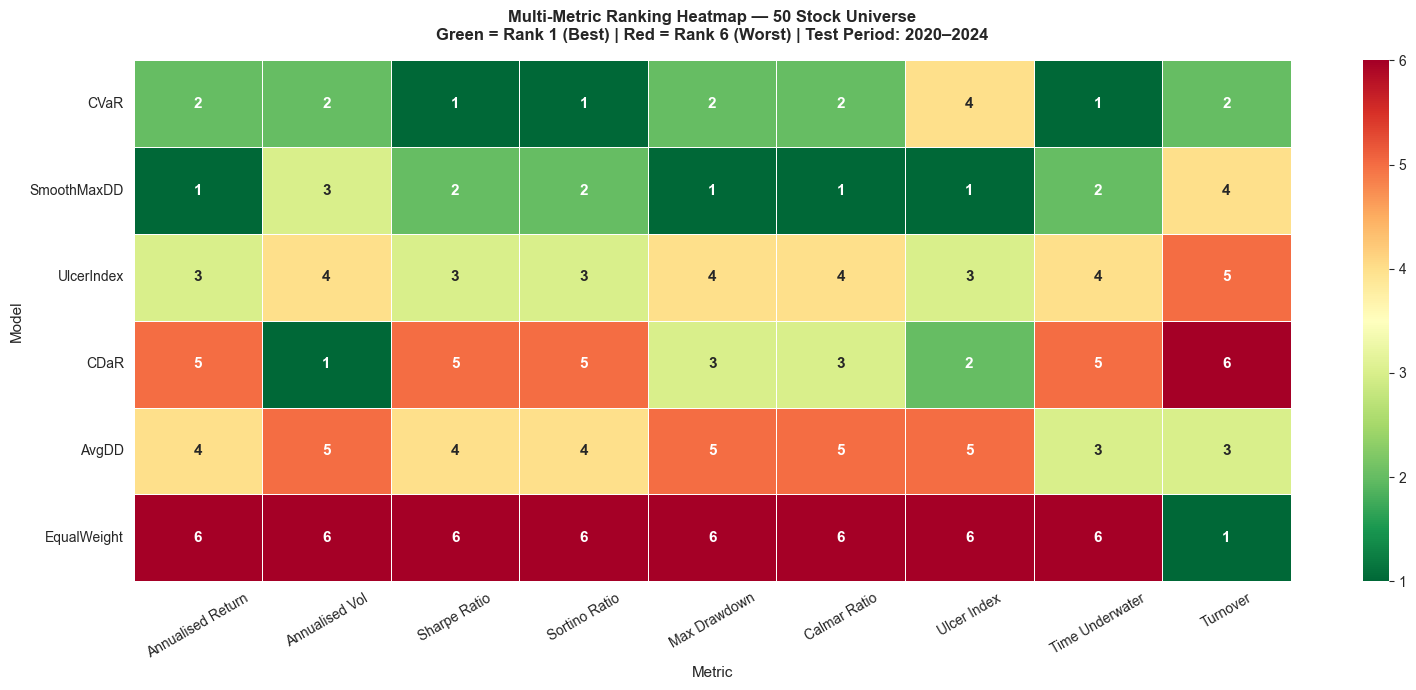

Ranking heatmap saved


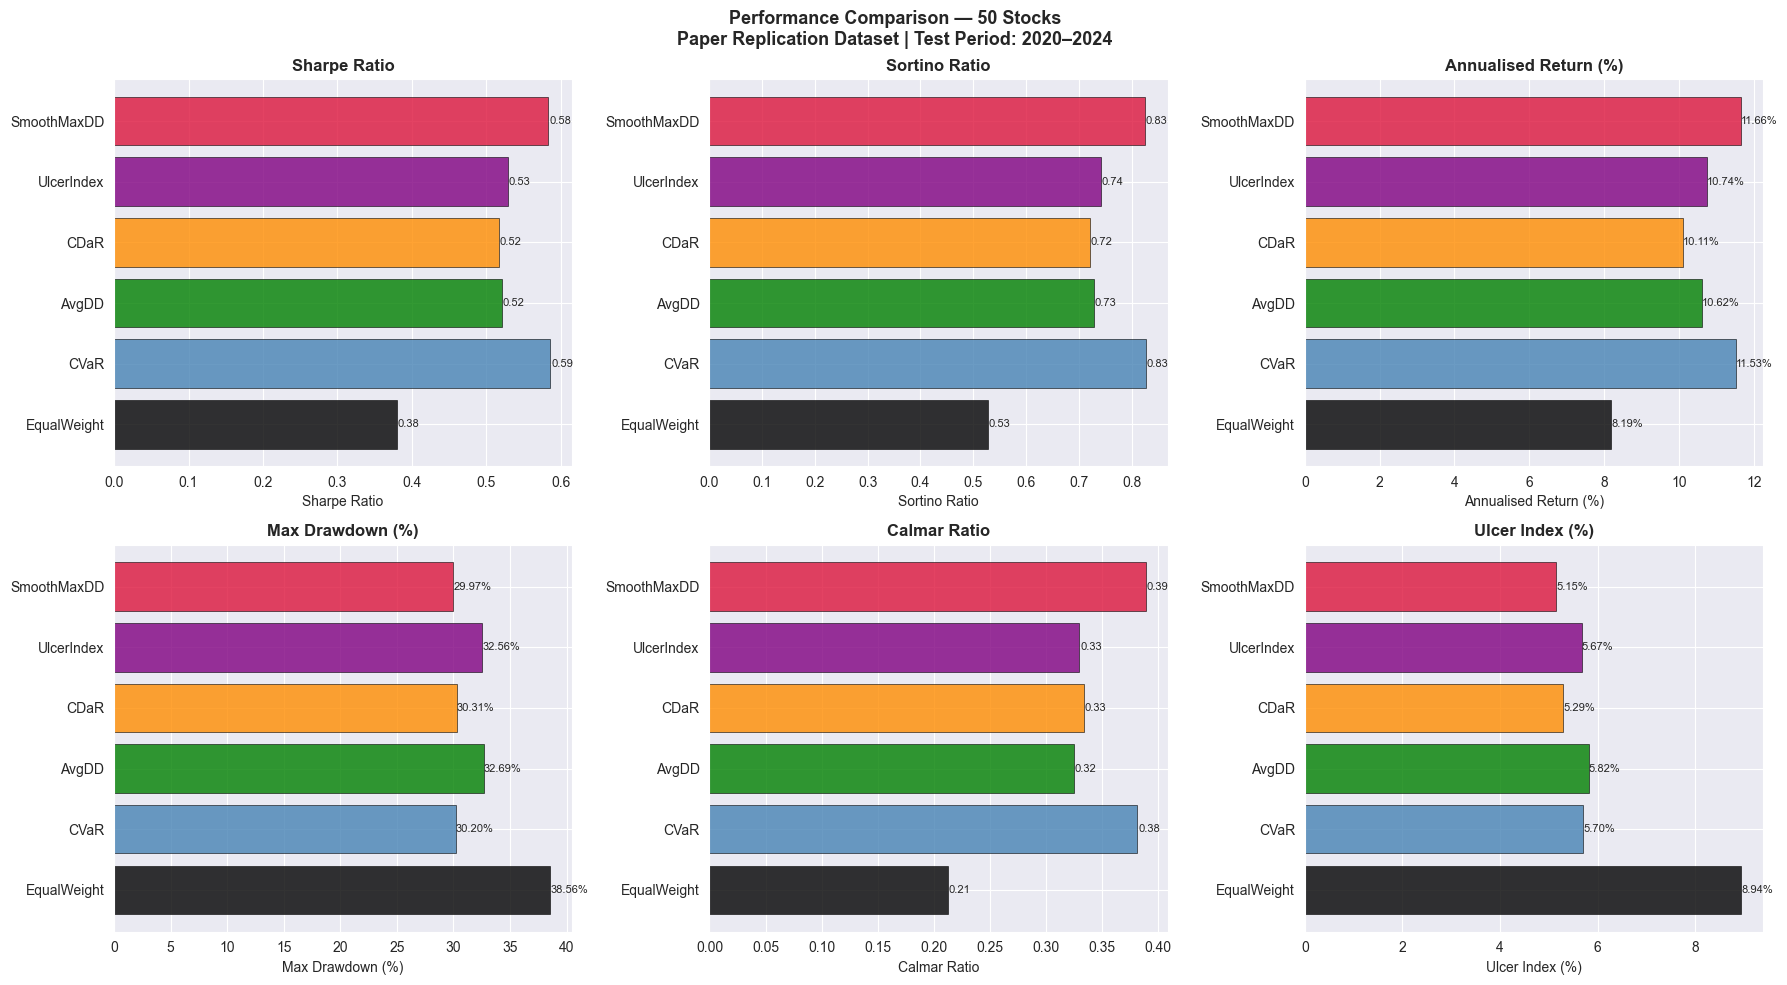

Performance comparison plot saved
Results saved to data_paper_50/horse_race_results.csv
Composite ranking saved to data_paper_50/composite_ranking.csv

Winners saved to data_paper_50\winners.json:
  WINNING_MODEL             : CVaR
  COMPOSITE_WINNER          : CVaR
  BEST_DRAWDOWN_MODEL       : SmoothMaxDD
  DATA_POOL                 : 50
  DATA_FOLDER               : data_paper_50

  SUMMARY OF WINNERS BY CATEGORY
  Dataset: 50 stocks | 2020-2024

  Individual metric winners:
    Annualised Return      : SmoothMaxDD     (11.66%)
    Annualised Vol         : CDaR            (17.85%)
    Sharpe Ratio           : CVaR            (0.5863)
    Sortino Ratio          : CVaR            (0.8269)
    Max Drawdown           : SmoothMaxDD     (29.97%)
    Calmar Ratio           : SmoothMaxDD     (0.3890)
    Ulcer Index            : SmoothMaxDD     (5.15%)
    Time Underwater        : CVaR            (89.64%)
    Turnover               : EqualWeight     (0.00%)

  Overall winners:
    Sharpe ra

In [22]:
# ============================================================
# CELL 20: MULTI-METRIC COMPOSITE RANKING
# ============================================================
# Sharpe ratio alone is insufficient to crown a winner
# because it only measures return per unit of total volatility
# Our extension specifically targets drawdown risk so we
# must evaluate models across multiple dimensions
#
# We use a composite ranking approach:
# 1. Rank each model on each individual metric
#    Rank 1 = best performance on that metric
#    Rank 6 = worst performance on that metric
# 2. Average ranks across all metrics
#    Lower composite score = better overall performance
# 3. Also compute a drawdown-specific ranking
#    using only the four drawdown metrics
#    This directly evaluates our extension's objective
#
# At the end we save the winner names to winners.json
# so Cells 23 24 and 25 can load them dynamically
# without any hardcoding

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import json

# ---- Safety check ----
try:
    all_results
except NameError:
    print("ERROR: all_results not defined")
    print("Please run Cell 19 first")
    raise

# ---- Check folder paths ----
try:
    DATA_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER = 'data_paper_50'
    DATA_POOL   = 50
    print(f"DATA_FOLDER set to {DATA_FOLDER}")

# Set consistent plot style
sns.set_style('darkgrid')

# ============================================================
# STEP 1: BUILD THE FULL RESULTS TABLE
# ============================================================

# Include all five models plus Equal Weight benchmark
all_model_names = (
    ['EqualWeight'] +
    list(LOSS_FUNCTIONS.keys())
)

# Define all metrics and their direction
# +1 means higher value is better for that metric
# -1 means lower value is better for that metric
metric_directions = {
    'Annualised Return' : +1,  # higher return = better
    'Annualised Vol'    : -1,  # lower risk = better
    'Sharpe Ratio'      : +1,  # higher ratio = better
    'Sortino Ratio'     : +1,  # higher ratio = better
    'Max Drawdown'      : -1,  # lower drawdown = better
    'Calmar Ratio'      : +1,  # higher ratio = better
    'Ulcer Index'       : -1,  # lower UI = better
    'Time Underwater'   : -1,  # less time = better
    'Turnover'          : -1,  # lower turnover = better
}

# ---- Build raw results DataFrame ----
rows = []
for name in all_model_names:
    if name in all_results:
        row = {'Model': name}         # model name
        row.update(all_results[name]['metrics'])  # all metrics
        rows.append(row)

# Create DataFrame with Model as row index
results_df = pd.DataFrame(rows).set_index('Model')

# ---- Print raw results table ----
print(f"{'='*70}")
print(f"  RAW RESULTS TABLE — PAPER REPLICATION DATASET")
print(f"  Asset pool: {DATA_POOL} stocks | Test period: 2020-2024")
print(f"{'='*70}")
print(results_df.round(4).to_string())
print(f"{'='*70}")

# ============================================================
# STEP 2: RANK EACH MODEL ON EACH METRIC
# ============================================================

# For each metric assign ranks 1 to 6
# Rank 1 = best performance on that metric
# Rank 6 = worst performance on that metric

rank_df = pd.DataFrame(index=results_df.index)

for metric, direction in metric_directions.items():
    if metric not in results_df.columns:
        continue  # skip metrics not in results

    values = results_df[metric]  # values for this metric

    if direction == +1:
        # Higher is better — rank 1 = highest value
        rank_df[metric] = values.rank(ascending=False)
    else:
        # Lower is better — rank 1 = lowest value
        rank_df[metric] = values.rank(ascending=True)

# ---- Print rank table ----
print(f"\nRANK TABLE (1 = best on that metric):")
print(f"{'─'*70}")
print(rank_df.round(1).to_string())
print(f"{'─'*70}")

# ============================================================
# STEP 3: COMPUTE COMPOSITE SCORE
# ============================================================

# Average rank across ALL metrics
# Lower composite score = better overall performance
rank_df['Composite Score'] = rank_df.mean(axis=1)

# Sort ascending — lower composite score is better
rank_df = rank_df.sort_values('Composite Score')

# ---- Print composite ranking ----
print(f"\nCOMPOSITE RANKING (lower score = better):")
print(f"{'='*55}")
for rank, (model, row) in enumerate(rank_df.iterrows(), 1):
    marker = " ← WINNER" if rank == 1 else ""
    print(
        f"  {rank}. {model:<15} "
        f"Composite Score = "
        f"{row['Composite Score']:.2f}{marker}"
    )
print(f"{'='*55}")

# Store composite winner
COMPOSITE_WINNER = rank_df.index[0]
print(f"\nComposite winner : {COMPOSITE_WINNER}")

# ============================================================
# STEP 4: DRAWDOWN-SPECIFIC RANKING
# ============================================================

# Rank models specifically on drawdown metrics only
# This directly evaluates our extension's objective
# A model trained to minimise drawdown should rank
# highly on these four metrics

drawdown_metrics = {
    'Max Drawdown'    : -1,  # lower = better
    'Ulcer Index'     : -1,  # lower = better
    'Time Underwater' : -1,  # lower = better
    'Calmar Ratio'    : +1,  # higher = better
    'Sortino Ratio'   : +1,  # higher = better
}

# Build drawdown-specific rank DataFrame
dd_rank_df = pd.DataFrame(index=results_df.index)

for metric, direction in drawdown_metrics.items():
    if metric not in results_df.columns:
        continue
    values = results_df[metric]
    if direction == +1:
        dd_rank_df[metric] = values.rank(ascending=False)
    else:
        dd_rank_df[metric] = values.rank(ascending=True)

# Average drawdown ranks
dd_rank_df['Drawdown Score'] = dd_rank_df.mean(axis=1)
dd_rank_df = dd_rank_df.sort_values('Drawdown Score')

# ---- Print drawdown ranking ----
print(f"\nDRAWDOWN-SPECIFIC RANKING:")
print(f"{'='*55}")
for rank, (model, row) in enumerate(
    dd_rank_df.iterrows(), 1
):
    marker = (
        " ← BEST DRAWDOWN PROTECTION"
        if rank == 1 else ""
    )
    print(
        f"  {rank}. {model:<15} "
        f"Drawdown Score = "
        f"{row['Drawdown Score']:.2f}{marker}"
    )
print(f"{'='*55}")

BEST_DRAWDOWN_MODEL = dd_rank_df.index[0]
print(f"\nBest drawdown model : {BEST_DRAWDOWN_MODEL}")

# ============================================================
# STEP 5: PLOT RANKING HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(16, 7))

# Drop composite score column for heatmap display
heatmap_data = rank_df.drop(columns=['Composite Score'])

# Plot heatmap — green = rank 1 (best) red = rank 6 (worst)
sns.heatmap(
    heatmap_data,
    annot     = True,           # show rank numbers in cells
    fmt       = '.0f',          # format as integers
    cmap      = 'RdYlGn_r',    # red=worst green=best
    vmin      = 1,              # rank 1 = darkest green
    vmax      = len(all_model_names),  # rank 6 = darkest red
    linewidths= 0.5,            # thin lines between cells
    ax        = ax,
    annot_kws = {'size': 11, 'fontweight': 'bold'}
)

ax.set_title(
    f'Multi-Metric Ranking Heatmap — '
    f'{DATA_POOL} Stock Universe\n'
    f'Green = Rank 1 (Best) | '
    f'Red = Rank 6 (Worst) | '
    f'Test Period: 2020–2024',
    fontsize   = 12,
    fontweight = 'bold',
    pad        = 15
)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Model',  fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'ranking_heatmap.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Ranking heatmap saved")

# ============================================================
# STEP 6: PERFORMANCE BAR CHARTS
# ============================================================

fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle(
    f'Performance Comparison — {DATA_POOL} Stocks\n'
    f'Paper Replication Dataset | Test Period: 2020–2024',
    fontsize=13, fontweight='bold'
)

# Colours for each model
model_colours = {
    'EqualWeight' : 'black',
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson'
}

# Metrics to plot in each subplot
plot_metrics = [
    ('Sharpe Ratio',      False, 'Sharpe Ratio'),
    ('Sortino Ratio',     False, 'Sortino Ratio'),
    ('Annualised Return', True,  'Annualised Return (%)'),
    ('Max Drawdown',      True,  'Max Drawdown (%)'),
    ('Calmar Ratio',      False, 'Calmar Ratio'),
    ('Ulcer Index',       True,  'Ulcer Index (%)'),
]

for ax, (metric, as_pct, label) in zip(
    axes2.flatten(), plot_metrics
):
    # Get values for each model
    values = [
        results_df.loc[m, metric]
        if m in results_df.index else 0
        for m in all_model_names
    ]

    # Convert to percentage if needed
    plot_values = (
        [v * 100 for v in values] if as_pct else values)

    # Get colours for each model
    colours = [
        model_colours.get(m, 'grey')
        for m in all_model_names
    ]

    # Plot horizontal bar chart
    bars = ax.barh(
        all_model_names, plot_values,
        color=colours, alpha=0.8,
        edgecolor='black', linewidth=0.5
    )

    # Add value labels on bars
    for bar, val in zip(bars, plot_values):
        ax.text(
            bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}{"%" if as_pct else ""}',
            va='center', fontsize=8
        )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)

plt.tight_layout()
plt.savefig(
    os.path.join(DATA_FOLDER, 'performance_comparison.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Performance comparison plot saved")

# ============================================================
# STEP 7: SAVE RESULTS TO CSV
# ============================================================

# Save raw results table
results_df.to_csv(
    os.path.join(DATA_FOLDER, 'horse_race_results.csv'))
print(f"Results saved to {DATA_FOLDER}/horse_race_results.csv")

# Save composite ranking
rank_df.to_csv(
    os.path.join(DATA_FOLDER, 'composite_ranking.csv'))
print(f"Composite ranking saved to "
      f"{DATA_FOLDER}/composite_ranking.csv")

# ============================================================
# STEP 8: SAVE WINNER NAMES TO JSON
# ============================================================
# This is the key addition that makes Cells 23 24 25
# dynamic — they load from this file instead of hardcoding
# Every time you change DATA_POOL and rerun the notebook
# this file is updated automatically with the new winners

winners = {
    'WINNING_MODEL'       : str(COMPOSITE_WINNER),
    'COMPOSITE_WINNER'    : str(COMPOSITE_WINNER),
    'BEST_DRAWDOWN_MODEL' : str(BEST_DRAWDOWN_MODEL),
    'DATA_POOL'           : DATA_POOL,
    'DATA_FOLDER'         : DATA_FOLDER,
}

winners_path = os.path.join(DATA_FOLDER, 'winners.json')
with open(winners_path, 'w') as f:
    json.dump(winners, f, indent=2)  # save with formatting

print(f"\nWinners saved to {winners_path}:")
for k, v in winners.items():
    print(f"  {k:<25} : {v}")

# ============================================================
# STEP 9: FINAL SUMMARY
# ============================================================

print(f"\n{'='*60}")
print(f"  SUMMARY OF WINNERS BY CATEGORY")
print(f"  Dataset: {DATA_POOL} stocks | 2020-2024")
print(f"{'='*60}")

print(f"\n  Individual metric winners:")
for metric, direction in metric_directions.items():
    if metric not in results_df.columns:
        continue
    if direction == +1:
        winner = results_df[metric].idxmax()
        best   = results_df[metric].max()
    else:
        winner = results_df[metric].idxmin()
        best   = results_df[metric].min()

    # Format value as percentage or plain number
    if metric in [
        'Annualised Return', 'Annualised Vol',
        'Max Drawdown', 'Ulcer Index',
        'Time Underwater', 'Turnover'
    ]:
        val_str = f"{best*100:.2f}%"
    else:
        val_str = f"{best:.4f}"

    print(f"    {metric:<22} : "
          f"{winner:<15} ({val_str})")

print(f"\n  Overall winners:")
print(f"    Sharpe ranking    : "
      f"{results_df['Sharpe Ratio'].idxmax()}")
print(f"    Composite ranking : {COMPOSITE_WINNER}")
print(f"    Drawdown ranking  : {BEST_DRAWDOWN_MODEL}")

# Update WINNING_MODEL for use in robustness cells
WINNING_MODEL = COMPOSITE_WINNER
print(f"\nWINNING_MODEL updated to: {WINNING_MODEL}")
print(f"This model will be used in robustness testing")

print(f"\nCell 20 complete")
print(f"Next: Cell 21 — Cumulative Wealth Plot")

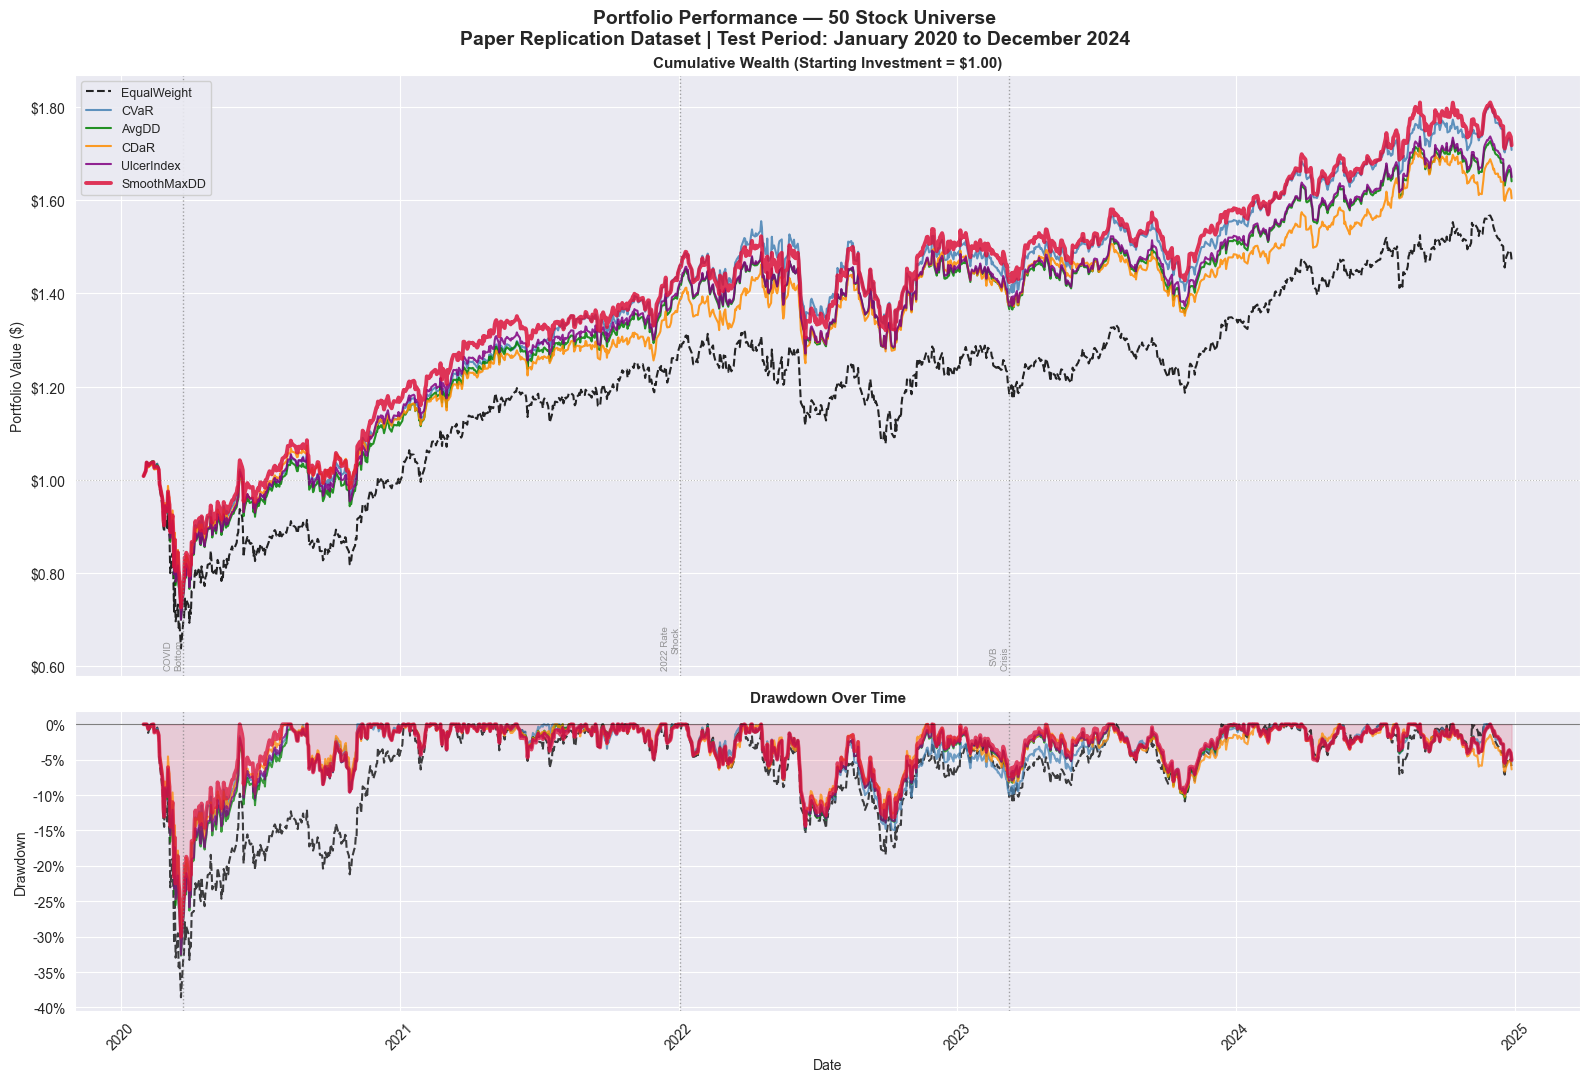

Cumulative wealth plot saved to data_paper_50/cumulative_wealth.png

FINAL WEALTH SUMMARY ($1 invested at start of test period):
─────────────────────────────────────────────
  1. SmoothMaxDD     $1.7175 ← WINNER
  2. CVaR            $1.7075
  3. UlcerIndex      $1.6494
  4. AvgDD           $1.6402
  5. CDaR            $1.6040
  6. EqualWeight     $1.4714
─────────────────────────────────────────────

Cell 21 complete
Next: Cell 22 — Training curves plot


In [23]:
# ============================================================
# CELL 21: CUMULATIVE WEALTH AND DRAWDOWN PLOTS
# ============================================================
# These are the two most important visualisations
# for your report:
#
# Plot 1: Cumulative wealth curves
#   Shows how $1 invested at the start of the test
#   period grew under each strategy
#   Most intuitive chart for investors and examiners
#
# Plot 2: Drawdown over time
#   Shows how far below the peak each strategy was
#   at every point during the test period
#   Directly illustrates what each model was trained
#   to minimise

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import os

# ---- Safety check ----
try:
    all_results
    test_dates_final
    DATA_FOLDER
    DATA_POOL
except NameError:
    print("ERROR: Required variables not found")
    print("Please run Cells 18-20 first")
    raise

# ---- Define consistent colours and styles ----
# Same colours used across all plots in this notebook
# for visual consistency in your report
MODEL_COLOURS = {
    'EqualWeight' : 'black',
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson'
}

# Winning model gets a thicker line to stand out
MODEL_WIDTHS = {
    'EqualWeight' : 1.5,
    'CVaR'        : 1.5,
    'AvgDD'       : 1.5,
    'CDaR'        : 1.5,
    'UlcerIndex'  : 1.5,
    'SmoothMaxDD' : 2.8   # thicker for winner
}

# Dashed line for benchmark
MODEL_STYLES = {
    'EqualWeight' : '--',
    'CVaR'        : '-',
    'AvgDD'       : '-',
    'CDaR'        : '-',
    'UlcerIndex'  : '-',
    'SmoothMaxDD' : '-'
}

# ---- Convert test dates to datetime ----
# pd.to_datetime ensures dates are in correct format
plot_dates = pd.to_datetime(test_dates_final.values)

# ============================================================
# FIGURE 1: CUMULATIVE WEALTH AND DRAWDOWN
# ============================================================

# Create figure with two subplots sharing x-axis
# Top panel: cumulative wealth (taller)
# Bottom panel: drawdown over time (shorter)
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize        = (16, 11),
    sharex         = True,
    gridspec_kw    = {'height_ratios': [2, 1]}
)

fig.suptitle(
    f'Portfolio Performance — {DATA_POOL} Stock Universe\n'
    f'Paper Replication Dataset | '
    f'Test Period: January 2020 to December 2024',
    fontsize     = 14,
    fontweight   = 'bold'
)

# ============================================================
# TOP PANEL: CUMULATIVE WEALTH
# ============================================================

for name, data in all_results.items():

    # Get daily portfolio returns for this model
    port_ret = data['portfolio_returns']

    # Compute cumulative wealth starting at $1
    # np.cumprod multiplies each day's (1+return)
    # giving the running total value of $1 invested
    cum_wealth = np.cumprod(1 + port_ret)

    # Trim dates to match return series length
    # Some alignment differences may cause slight
    # length differences between dates and returns
    dates_trimmed = plot_dates[:len(cum_wealth)]

    # Plot cumulative wealth line
    ax1.plot(
        dates_trimmed,
        cum_wealth,
        label     = name,
        color     = MODEL_COLOURS.get(name, 'grey'),
        linestyle = MODEL_STYLES.get(name, '-'),
        linewidth = MODEL_WIDTHS.get(name, 1.5),
        alpha     = 0.85
    )

# ---- Add market event annotations ----
# Vertical lines mark key stress periods
# Shows how each model behaved during crises
market_events = [
    # (date, label, y_offset)
    ('2020-03-23', 'COVID\nBottom',    0.02),
    ('2022-01-03', '2022 Rate\nShock', 0.02),
    ('2023-03-10', 'SVB\nCrisis',      0.02),
]

for event_date, label, _ in market_events:
    # Add vertical dotted line
    ax1.axvline(
        pd.Timestamp(event_date),
        color     = 'grey',
        linestyle = ':',
        linewidth = 1.0,
        alpha     = 0.7
    )
    # Add text label
    ax1.text(
        pd.Timestamp(event_date),
        ax1.get_ylim()[0] * 1.02
        if ax1.get_ylim()[0] > 0 else 0.95,
        label,
        fontsize  = 7,
        color     = 'grey',
        rotation  = 90,
        va        = 'bottom',
        ha        = 'right',
        alpha     = 0.8
    )

# ---- Reference line at starting value ----
# Horizontal line at $1 shows the break-even point
ax1.axhline(
    y         = 1.0,
    color     = 'grey',
    linestyle = ':',
    linewidth = 0.8,
    alpha     = 0.5
)

# ---- Formatting ----
ax1.set_title(
    'Cumulative Wealth (Starting Investment = $1.00)',
    fontsize   = 11,
    fontweight = 'bold'
)
ax1.set_ylabel('Portfolio Value ($)', fontsize=10)
ax1.legend(
    loc        = 'upper left',
    fontsize   = 9,
    framealpha = 0.9
)
# Format y-axis as dollar values
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f'${x:.2f}'))

# ============================================================
# BOTTOM PANEL: DRAWDOWN OVER TIME
# ============================================================

for name, data in all_results.items():

    # Get daily portfolio returns
    port_ret = data['portfolio_returns']

    # Compute cumulative wealth
    cum_wealth   = np.cumprod(1 + port_ret)

    # Compute running maximum — the previous peak
    # np.maximum.accumulate gives the running max
    running_peak = np.maximum.accumulate(cum_wealth)

    # Compute drawdown as negative values
    # Negative so it plots below the zero line
    # making it intuitive to read
    drawdown = -(running_peak - cum_wealth) / running_peak

    # Trim dates
    dates_trimmed = plot_dates[:len(drawdown)]

    # Plot drawdown line
    ax2.plot(
        dates_trimmed,
        drawdown,
        label     = name,
        color     = MODEL_COLOURS.get(name, 'grey'),
        linestyle = MODEL_STYLES.get(name, '-'),
        linewidth = MODEL_WIDTHS.get(name, 1.5),
        alpha     = 0.75
    )

# ---- Shade winning model drawdown area ----
# Fill the area under the SmoothMaxDD drawdown curve
# to highlight the winning model visually
if 'SmoothMaxDD' in all_results:
    port_ret     = all_results[
        'SmoothMaxDD']['portfolio_returns']
    cum_wealth   = np.cumprod(1 + port_ret)
    running_peak = np.maximum.accumulate(cum_wealth)
    drawdown     = -(
        running_peak - cum_wealth) / running_peak
    dates_trimmed = plot_dates[:len(drawdown)]

    # Fill between zero line and drawdown curve
    ax2.fill_between(
        dates_trimmed,
        drawdown,
        0,
        alpha = 0.15,
        color = 'crimson',
        label = '_nolegend_'
        # underscore prefix hides from legend
    )

# ---- Add market event lines to drawdown panel ----
for event_date, label, _ in market_events:
    ax2.axvline(
        pd.Timestamp(event_date),
        color     = 'grey',
        linestyle = ':',
        linewidth = 1.0,
        alpha     = 0.7
    )

# ---- Zero reference line ----
# Horizontal line at zero — above = at peak
# below = in drawdown
ax2.axhline(
    y         = 0,
    color     = 'black',
    linewidth = 0.8,
    alpha     = 0.5
)

# ---- Formatting ----
ax2.set_title(
    'Drawdown Over Time',
    fontsize   = 11,
    fontweight = 'bold'
)
ax2.set_ylabel('Drawdown', fontsize=10)
ax2.set_xlabel('Date',     fontsize=10)

# Format y-axis as percentages
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, p: f'{x*100:.0f}%'))

# Format x-axis as years
ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(
    mdates.YearLocator())
plt.xticks(rotation=45)

# ============================================================
# SAVE AND SHOW
# ============================================================

plt.tight_layout()
plt.savefig(
    os.path.join(
        DATA_FOLDER, 'cumulative_wealth.png'),
    dpi         = 150,
    bbox_inches = 'tight'
)
plt.show()
print("Cumulative wealth plot saved to "
      f"{DATA_FOLDER}/cumulative_wealth.png")

# ============================================================
# PRINT FINAL WEALTH SUMMARY
# ============================================================

print(f"\nFINAL WEALTH SUMMARY "
      f"($1 invested at start of test period):")
print(f"{'─'*45}")

# Compute final wealth for each model
final_wealth = {}
for name, data in all_results.items():
    port_ret          = data['portfolio_returns']
    cum_wealth        = np.cumprod(1 + port_ret)
    final_wealth[name] = cum_wealth[-1]

# Sort by final wealth descending
sorted_wealth = sorted(
    final_wealth.items(),
    key     = lambda x: x[1],
    reverse = True
)

# Print ranked by final wealth
for rank, (name, wealth) in enumerate(
    sorted_wealth, 1
):
    # Mark winner
    marker = " ← WINNER" if rank == 1 else ""
    print(f"  {rank}. {name:<15} "
          f"${wealth:.4f}{marker}")

print(f"{'─'*45}")
print(f"\nCell 21 complete")
print(f"Next: Cell 22 — Training curves plot")

Models with training history:
  CVaR            : 16 epochs | best val loss = 0.015591 at epoch 1
  AvgDD           : 17 epochs | best val loss = 0.014800 at epoch 2
  CDaR            : 18 epochs | best val loss = 0.045211 at epoch 3
  UlcerIndex      : 17 epochs | best val loss = 0.020526 at epoch 2
  SmoothMaxDD     : 17 epochs | best val loss = 0.104245 at epoch 2


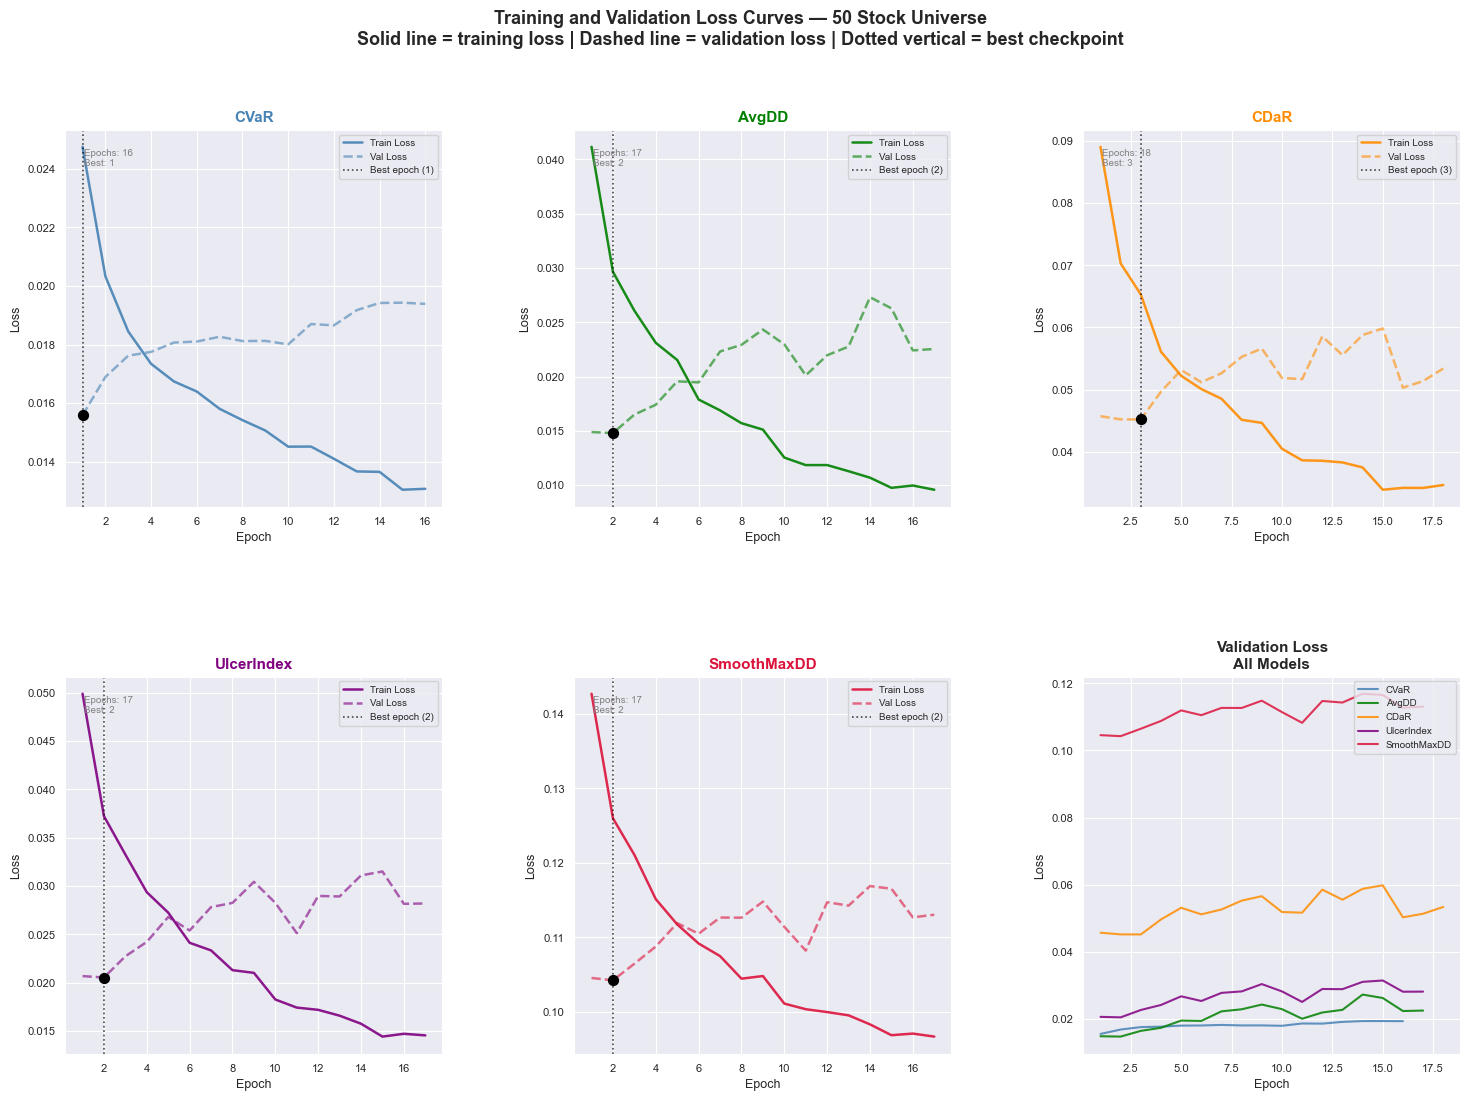

Training curves saved to data_paper_50/training_curves.png

TRAINING SUMMARY TABLE:
─────────────────────────────────────────────────────────────────
  Model             Epochs   Best Epoch   Best Val Loss   Final Train Loss
─────────────────────────────────────────────────────────────────
  CVaR                  16            1        0.015591           0.013078
  AvgDD                 17            2        0.014800           0.009584
  CDaR                  18            3        0.045211           0.034670
  UlcerIndex            17            2        0.020526           0.014537
  SmoothMaxDD           17            2        0.104245           0.096693
─────────────────────────────────────────────────────────────────

Overfitting check:
─────────────────────────────────────────────
  CVaR            : val/train ratio = 1.19 — OK
  AvgDD           : val/train ratio = 1.54 — OK
  CDaR            : val/train ratio = 1.30 — OK
  UlcerIndex      : val/train ratio = 1.41 — OK
  SmoothMa

In [24]:
# ============================================================
# CELL 22: TRAINING CURVES PLOT
# ============================================================
# Visualises how each model's loss changed during training
# This serves three purposes in your report:
#
# 1. Confirms training was stable — no exploding losses
# 2. Shows when early stopping triggered for each model
# 3. Reveals whether any model overfit
#    Overfitting signature: training loss keeps falling
#    while validation loss rises or plateaus
#
# A well-trained model shows both training and validation
# loss declining together and stabilising

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

# ---- Safety check ----
try:
    horse_race_history
    DATA_FOLDER
    DATA_POOL
except NameError:
    print("ERROR: horse_race_history not found")
    print("Please run Cell 19 first")
    raise

# ---- Confirm we have history for all models ----
print(f"Models with training history:")
for name, history in horse_race_history.items():
    n_epochs = len(history['train_loss'])
    best_val = min(history['val_loss'])
    best_ep  = np.argmin(history['val_loss']) + 1
    print(f"  {name:<15} : "
          f"{n_epochs} epochs | "
          f"best val loss = {best_val:.6f} "
          f"at epoch {best_ep}")

# ---- Define consistent colours ----
MODEL_COLOURS = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson'
}

# ============================================================
# FIGURE 1: INDIVIDUAL TRAINING CURVES
# ============================================================

# Create a 2x3 grid — 5 individual plots plus
# one combined overview showing all models together
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(
    2, 3,
    figure  = fig,
    hspace  = 0.45,
    wspace  = 0.35
)

fig.suptitle(
    f'Training and Validation Loss Curves — '
    f'{DATA_POOL} Stock Universe\n'
    f'Solid line = training loss | '
    f'Dashed line = validation loss | '
    f'Dotted vertical = best checkpoint',
    fontsize   = 13,
    fontweight = 'bold'
)

# ---- Plot individual curve for each model ----
for idx, (model_name, history) in enumerate(
    horse_race_history.items()
):
    # Place in grid — row 0: positions 0,1,2
    # row 1: positions 3,4 (position 5 = overview)
    row = idx // 3
    col = idx  % 3
    ax  = fig.add_subplot(gs[row, col])

    # Get colour for this model
    colour = MODEL_COLOURS.get(model_name, 'grey')

    # Number of epochs actually trained
    # May be less than N_EPOCHS if early stopping hit
    n_epochs_trained = len(history['train_loss'])
    epoch_range      = range(1, n_epochs_trained + 1)

    # ---- Plot training loss ----
    # Solid line — what the model learned from
    ax.plot(
        epoch_range,
        history['train_loss'],
        label     = 'Train Loss',
        color     = colour,
        linewidth = 1.8,
        alpha     = 0.9
    )

    # ---- Plot validation loss ----
    # Dashed line — unseen data performance
    ax.plot(
        epoch_range,
        history['val_loss'],
        label     = 'Val Loss',
        color     = colour,
        linewidth = 1.8,
        linestyle = '--',
        alpha     = 0.6
    )

    # ---- Mark the best validation epoch ----
    # This is where the model checkpoint was saved
    # The model loaded during evaluation uses these
    # weights not the final epoch weights
    best_epoch = np.argmin(history['val_loss']) + 1
    best_val   = min(history['val_loss'])

    # Vertical dotted line at best epoch
    ax.axvline(
        x         = best_epoch,
        color     = 'black',
        linestyle = ':',
        linewidth = 1.2,
        alpha     = 0.7,
        label     = f'Best epoch ({best_epoch})'
    )

    # Dot at the best validation point
    ax.scatter(
        best_epoch,
        best_val,
        color  = 'black',
        zorder = 5,
        s      = 50
    )

    # ---- Formatting ----
    ax.set_title(
        f'{model_name}',
        fontweight = 'bold',
        fontsize   = 11,
        color      = colour
    )
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Loss',  fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.tick_params(labelsize=8)

    # Add text showing total epochs and best epoch
    ax.text(
        0.05, 0.95,
        f'Epochs: {n_epochs_trained}\n'
        f'Best: {best_epoch}',
        transform  = ax.transAxes,
        fontsize   = 7,
        color      = 'grey',
        va         = 'top'
    )

# ============================================================
# SIXTH SUBPLOT: COMBINED VALIDATION LOSS
# ============================================================

# Show all five validation loss curves on one axes
# Makes it easy to compare convergence speed
# and final validation loss across all models
ax6 = fig.add_subplot(gs[1, 2])

for model_name, history in horse_race_history.items():
    colour   = MODEL_COLOURS.get(model_name, 'grey')
    n_epochs = len(history['val_loss'])

    # Plot validation loss for this model
    ax6.plot(
        range(1, n_epochs + 1),
        history['val_loss'],
        label     = model_name,
        color     = colour,
        linewidth = 1.5,
        alpha     = 0.85
    )

ax6.set_title(
    'Validation Loss\nAll Models',
    fontweight = 'bold',
    fontsize   = 11
)
ax6.set_xlabel('Epoch', fontsize=9)
ax6.set_ylabel('Loss',  fontsize=9)
ax6.legend(fontsize=7, loc='upper right')
ax6.tick_params(labelsize=8)

# ---- Save figure 1 ----
plt.savefig(
    os.path.join(DATA_FOLDER, 'training_curves.png'),
    dpi         = 150,
    bbox_inches = 'tight'
)
plt.show()
print("Training curves saved to "
      f"{DATA_FOLDER}/training_curves.png")

# ============================================================
# FIGURE 2: TRAINING SUMMARY TABLE
# ============================================================

print(f"\nTRAINING SUMMARY TABLE:")
print(f"{'─'*65}")
print(
    f"  {'Model':<15} "
    f"{'Epochs':>8} "
    f"{'Best Epoch':>12} "
    f"{'Best Val Loss':>15} "
    f"{'Final Train Loss':>18}"
)
print(f"{'─'*65}")

for model_name, history in horse_race_history.items():
    # Total epochs trained
    n_epochs   = len(history['train_loss'])
    # Epoch where best val loss occurred
    best_epoch = np.argmin(history['val_loss']) + 1
    # Best validation loss value
    best_val   = min(history['val_loss'])
    # Final training loss
    final_train = history['train_loss'][-1]

    print(
        f"  {model_name:<15} "
        f"{n_epochs:>8} "
        f"{best_epoch:>12} "
        f"{best_val:>15.6f} "
        f"{final_train:>18.6f}"
    )

print(f"{'─'*65}")

# ---- Check for overfitting ----
# Overfitting: final training loss much lower than
# best validation loss suggests the model memorised
# training data rather than learning general patterns
print(f"\nOverfitting check:")
print(f"{'─'*45}")
for model_name, history in horse_race_history.items():
    final_train = history['train_loss'][-1]
    best_val    = min(history['val_loss'])
    # Ratio of val loss to train loss
    # Ratio close to 1.0 = no overfitting
    # Ratio much greater than 1.0 = overfitting
    ratio = best_val / final_train if \
        final_train > 0 else np.nan
    status = (
        'OK'       if ratio < 2.0
        else 'MILD' if ratio < 3.0
        else 'HIGH'
    )
    print(
        f"  {model_name:<15} : "
        f"val/train ratio = {ratio:.2f} "
        f"— {status}"
    )
print(f"{'─'*45}")

print(f"\nCell 22 complete")
print(f"Next: Cell 23 — Walk-forward validation")

In [25]:
# ============================================================
# CELL 23: LENS 1 — WALK-FORWARD VALIDATION
# ============================================================
# Walk-forward validation asks:
# "Does the composite winning model consistently outperform
#  the best drawdown model across different time periods?"
#
# Method — Expanding window:
#   Training always starts from 2000-01-01
#   The training end date moves forward one year
#   Each window tests on the following calendar year
#
#   Window 1: Train 2000-2007 → Test 2008
#   Window 2: Train 2000-2008 → Test 2009
#   Window 3: Train 2000-2009 → Test 2010
#   Window 4: Train 2000-2010 → Test 2011
#   Window 5: Train 2000-2011 → Test 2012
#   Window 6: Train 2000-2012 → Test 2013
#   Window 7: Train 2000-2013 → Test 2014
#   Window 8: Train 2000-2014 → Test 2015
#   Window 9: Train 2000-2015 → Test 2016
#
# Model assignments are loaded dynamically from
# winners.json saved by Cell 20 — no hardcoding needed
# Change DATA_POOL in Cell 1 and rerun to update winners

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import iisignature
import os
import json
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

# ============================================================
# SAFETY CHECKS — folder paths and config
# ============================================================

# ---- Check DEVICE ----
try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE set to: {DEVICE}")

# ---- Check folder paths ----
try:
    DATA_FOLDER
    SIG_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    if not os.path.exists(ROBUST_FOLDER):
        os.makedirs(ROBUST_FOLDER)
    print("Folder paths set")

# ---- Check config values ----
try:
    LOOKBACK
    SIG_ORDER
except NameError:
    with open(os.path.join(
        SIG_FOLDER, 'sig_config.json')) as f:
        sig_config = json.load(f)
    LOOKBACK  = sig_config['LOOKBACK']
    SIG_ORDER = sig_config['SIG_ORDER']
    print(f"LOOKBACK={LOOKBACK} SIG_ORDER={SIG_ORDER}")

# ---- Check hyperparameters ----
try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
    BATCH_SIZE
    GLOBAL_SEED
except NameError:
    D_MODEL     = 64
    N_HEADS     = 4
    N_LAYERS    = 2
    DROPOUT     = 0.1
    BATCH_SIZE  = 64
    GLOBAL_SEED = 42
    print("Hyperparameters set to defaults")

# ---- Load clean prices and recompute log returns ----
# Load from clean_prices.csv to ensure all stocks available
print("Loading clean prices and recomputing log returns...")
clean_prices = pd.read_csv(
    os.path.join(DATA_FOLDER, 'clean_prices.csv'),
    index_col=0, parse_dates=True
)
print(f"Clean prices shape: {clean_prices.shape}")

# Compute log returns from prices
log_returns = np.log(
    clean_prices / clean_prices.shift(1)
).dropna()

# Winsorise to remove data errors
lower       = log_returns.quantile(0.001)
upper       = log_returns.quantile(0.999)
log_returns = log_returns.clip(
    lower=lower, upper=upper, axis=1)

print(f"Log returns shape: {log_returns.shape}")
ACTUAL_N_ASSETS = log_returns.shape[1]
print(f"Actual N_ASSETS: {ACTUAL_N_ASSETS}")

# ---- Check set_all_seeds ----
try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ['PYTHONHASHSEED'] = str(seed)
    print("set_all_seeds redefined")

# ---- Check SIT class ----
try:
    SIT
except NameError:
    print("ERROR: SIT class not defined — run Cell 12 first")
    raise

# ---- Check metric functions ----
try:
    compute_metrics
    compute_turnover
except NameError:
    print("ERROR: Metric functions not defined — run Cell 15")
    raise

# ---- Verify Sortino Ratio is available ----
_test_check = compute_metrics(np.random.randn(100) * 0.01)
if 'Sortino Ratio' not in _test_check:
    print("ERROR: Sortino Ratio missing — rerun Cell 15")
    raise KeyError("Sortino Ratio not in compute_metrics")
else:
    print("Sortino Ratio confirmed in compute_metrics")

# ============================================================
# LOAD WINNING MODEL DYNAMICALLY FROM CELL 20 RESULTS
# ============================================================
# Winners are saved to winners.json by Cell 20
# This means no hardcoding is needed here
# Change DATA_POOL in Cell 1 and rerun the notebook
# and the correct winners will be loaded automatically

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    # Load winner names from Cell 20 output
    with open(winners_path) as f:
        winners = json.load(f)

    # Composite winner is our primary model to test
    WINNING_MODEL = winners['WINNING_MODEL']

    # Best drawdown model is the comparison model
    # We compare composite winner vs drawdown winner
    # because this is the most interesting comparison
    # for our research question
    BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']

    print(f"\nWinners loaded from {winners_path}")
else:
    # Fallback if Cell 20 was not run
    print(f"WARNING: {winners_path} not found")
    print(f"Please run Cell 20 first")
    WINNING_MODEL  = 'CVaR'
    BASELINE_MODEL = 'SmoothMaxDD'

# Handle edge case where winner and baseline are same model
# This can happen if one model wins both rankings
if WINNING_MODEL == BASELINE_MODEL:
    print(f"WARNING: WINNING_MODEL equals BASELINE_MODEL")
    print(f"Selecting CVaR as baseline instead")
    BASELINE_MODEL = 'CVaR' if WINNING_MODEL != 'CVaR' else 'SmoothMaxDD'

print(f"\nWINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")
print(f"\nThese are loaded dynamically from Cell 20 results")
print(f"Change DATA_POOL in Cell 1 and rerun to update")

# ============================================================
# DEFINE WALK-FORWARD WINDOWS
# ============================================================

WALK_FORWARD_WINDOWS = [
    ('2000-01-01', '2007-12-31', '2008-01-01', '2008-12-31'),
    ('2000-01-01', '2008-12-31', '2009-01-01', '2009-12-31'),
    ('2000-01-01', '2009-12-31', '2010-01-01', '2010-12-31'),
    ('2000-01-01', '2010-12-31', '2011-01-01', '2011-12-31'),
    ('2000-01-01', '2011-12-31', '2012-01-01', '2012-12-31'),
    ('2000-01-01', '2012-12-31', '2013-01-01', '2013-12-31'),
    ('2000-01-01', '2013-12-31', '2014-01-01', '2014-12-31'),
    ('2000-01-01', '2014-12-31', '2015-01-01', '2015-12-31'),
    ('2000-01-01', '2015-12-31', '2016-01-01', '2016-12-31'),
]

# ============================================================
# DEFINE HELPER FUNCTIONS
# ============================================================

def compute_sigs_for_window(
    returns_df, lookback, sig_order):
    """Compute path signature features using sliding window."""
    returns_array = returns_df.values
    T             = returns_array.shape[0]
    d             = returns_array.shape[1]
    n_sig_terms   = int(
        (d**(sig_order+1) - 1) / (d - 1)) - 1
    n_windows     = T - lookback
    features      = np.zeros((n_windows, n_sig_terms))
    for i in range(n_windows):
        window          = returns_array[i:i + lookback]
        cumulative_path = np.cumsum(window, axis=0)
        sig             = iisignature.sig(
            cumulative_path, sig_order)
        features[i]     = sig
    dates = returns_df.index[lookback:]
    return features, dates


def build_loaders_for_window(
    train_feat, train_ret,
    val_feat, val_ret, batch_size
):
    """Build PyTorch DataLoaders for one window."""

    class PortfolioDataset(Dataset):
        def __init__(self, features, returns):
            self.features  = torch.tensor(
                features, dtype=torch.float32)
            self.returns   = torch.tensor(
                returns,  dtype=torch.float32)
            self.n_samples = features.shape[0]
        def __len__(self):
            return self.n_samples
        def __getitem__(self, idx):
            return self.features[idx], self.returns[idx]

    train_ds = PortfolioDataset(train_feat, train_ret)
    val_ds   = PortfolioDataset(val_feat,   val_ret)
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(
        val_ds,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


def get_loss_fn_for_model(model_name):
    """
    Return the correct loss function for a given model name.
    This makes Cell 23 fully dynamic — it looks up the
    loss function by name rather than hardcoding it.
    Works for any model name that appears in the horse race.
    """

    # Helper functions shared by all loss functions
    def _port_ret(w, r):
        # Weighted portfolio return — sum across assets
        return (w * r).sum(dim=1)

    def _drawdowns(pr):
        # Compute drawdown series from return series
        cw   = torch.cumprod(1 + pr, dim=0)  # cumulative wealth
        peak = torch.cummax(cw, dim=0).values  # running peak
        dd   = torch.clamp(
            (peak - cw) / peak, min=0.0)       # distance below peak
        return dd

    # Map model name to its loss function
    if model_name == 'CVaR':
        def loss_fn(weights, returns, alpha=0.05):
            # CVaR — average of worst alpha fraction of losses
            pr           = _port_ret(weights, returns)
            losses       = -pr
            n            = losses.shape[0]
            sl, _        = torch.sort(losses)
            idx          = int((1 - alpha) * n)
            return sl[idx:].mean()
        return loss_fn

    elif model_name == 'AvgDD':
        def loss_fn(weights, returns):
            # Average Drawdown — mean of all drawdown values
            pr = _port_ret(weights, returns)
            dd = _drawdowns(pr)
            return dd.mean()
        return loss_fn

    elif model_name == 'CDaR':
        def loss_fn(weights, returns, alpha=0.05):
            # CDaR — CVaR applied to drawdown series
            pr        = _port_ret(weights, returns)
            dd        = _drawdowns(pr)
            n         = dd.shape[0]
            sd, _     = torch.sort(dd)
            idx       = int((1 - alpha) * n)
            if idx >= n:
                return sd[-1:]
            return sd[idx:].mean()
        return loss_fn

    elif model_name == 'UlcerIndex':
        def loss_fn(weights, returns):
            # Ulcer Index — root mean square of drawdowns
            pr      = _port_ret(weights, returns)
            dd      = _drawdowns(pr)
            epsilon = 1e-8
            return torch.sqrt((dd ** 2).mean() + epsilon)
        return loss_fn

    elif model_name == 'SmoothMaxDD':
        def loss_fn(weights, returns, beta=50.0):
            # Smooth MaxDD — log-sum-exp approximation
            pr = _port_ret(weights, returns)
            dd = _drawdowns(pr)
            return torch.logsumexp(beta * dd, dim=0) / beta
        return loss_fn

    else:
        raise ValueError(
            f"Unknown model name: {model_name}\n"
            f"Must be one of: CVaR, AvgDD, CDaR, "
            f"UlcerIndex, SmoothMaxDD"
        )


def train_and_evaluate_window(
    loss_fn, model_name,
    tr_feat, tr_ret,
    va_feat, va_ret,
    te_feat, te_ret,
    window_idx
):
    """Train fresh SIT model and evaluate on test period."""

    set_all_seeds(GLOBAL_SEED)  # reset seeds for fairness

    # Create model with actual data dimensions
    model = SIT(
        n_features = tr_feat.shape[1],  # actual feature size
        n_assets   = tr_ret.shape[1],   # actual asset count
        d_model    = D_MODEL,
        n_heads    = N_HEADS,
        n_layers   = N_LAYERS,
        dropout    = DROPOUT
    ).to(DEVICE)

    tr_loader, va_loader = build_loaders_for_window(
        tr_feat, tr_ret, va_feat, va_ret, BATCH_SIZE)

    # Unique checkpoint name for this window
    ckpt_name = f'wf_{model_name}_w{window_idx}'
    wf_folder = os.path.join(ROBUST_FOLDER, 'walk_forward')
    if not os.path.exists(wf_folder):
        os.makedirs(wf_folder)
    ckpt_path = os.path.join(
        wf_folder, f'{ckpt_name}_best.pt')

    optimizer        = optim.Adam(
        model.parameters(), lr=1e-4)
    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = 10
    n_epochs         = 80

    for epoch in range(n_epochs):

        # Training phase
        model.train()
        epoch_train_loss = 0.0
        n_batches        = 0

        for feat_b, ret_b in tr_loader:
            feat_b = feat_b.to(DEVICE)
            ret_b  = ret_b.to(DEVICE)
            optimizer.zero_grad()
            weights  = model(feat_b)
            loss     = loss_fn(weights, ret_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_train_loss += loss.item()
            n_batches        += 1

        avg_train = epoch_train_loss / n_batches

        # Validation phase
        model.eval()
        epoch_val_loss = 0.0
        n_val_batches  = 0

        with torch.no_grad():
            for feat_b, ret_b in va_loader:
                feat_b   = feat_b.to(DEVICE)
                ret_b    = ret_b.to(DEVICE)
                weights  = model(feat_b)
                val_loss = loss_fn(weights, ret_b)
                epoch_val_loss += val_loss.item()
                n_val_batches  += 1

        avg_val = epoch_val_loss / n_val_batches

        # Early stopping
        if avg_val < best_val_loss:
            best_val_loss    = avg_val
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    # Load best weights
    model.load_state_dict(torch.load(
        ckpt_path,
        map_location='cpu',
        weights_only=True
    ))
    model.eval()

    # Evaluate on test period
    te_feat_tensor = torch.tensor(
        te_feat, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        weights_tensor = model(te_feat_tensor)

    weights  = weights_tensor.cpu().numpy()
    port_ret = (weights * te_ret).sum(axis=1)
    metrics  = compute_metrics(port_ret)
    metrics['Turnover'] = compute_turnover(weights)

    return metrics, port_ret, weights


# ============================================================
# RUN WALK-FORWARD VALIDATION
# ============================================================

print(f"\n{'='*60}")
print(f"  LENS 1: WALK-FORWARD VALIDATION")
print(f"{'='*60}")
print(f"  Dataset          : {DATA_POOL} stocks")
print(f"  Windows          : {len(WALK_FORWARD_WINDOWS)}")
print(f"  Winning model    : {WINNING_MODEL}")
print(f"  Baseline model   : {BASELINE_MODEL}")
print(f"  Actual N_ASSETS  : {ACTUAL_N_ASSETS}")
print(f"{'='*60}")
print(f"\nThis will take 30-60 minutes on CPU\n")

# Initialise storage
wf_results = {
    WINNING_MODEL  : [],
    BASELINE_MODEL : [],
    'EqualWeight'  : []
}
wf_sharpe  = {
    WINNING_MODEL: [], BASELINE_MODEL: [], 'EqualWeight': []}
wf_max_dd  = {
    WINNING_MODEL: [], BASELINE_MODEL: [], 'EqualWeight': []}
wf_sortino = {
    WINNING_MODEL: [], BASELINE_MODEL: [], 'EqualWeight': []}
wf_ulcer   = {
    WINNING_MODEL: [], BASELINE_MODEL: [], 'EqualWeight': []}
wf_test_years = []

# Get loss functions dynamically by model name
winning_loss_fn  = get_loss_fn_for_model(WINNING_MODEL)
baseline_loss_fn = get_loss_fn_for_model(BASELINE_MODEL)

print(f"Loss functions loaded:")
print(f"  {WINNING_MODEL}  → winning_loss_fn")
print(f"  {BASELINE_MODEL} → baseline_loss_fn")

# Loop over each window
for w_idx, (tr_start, tr_end, te_start, te_end) in enumerate(WALK_FORWARD_WINDOWS):

    print(f"\n{'─'*60}")
    print(f"Window {w_idx+1}/{len(WALK_FORWARD_WINDOWS)}")
    print(f"  Train : {tr_start} to {tr_end}")
    print(f"  Test  : {te_start} to {te_end}")
    print(f"{'─'*60}")

    wf_test_years.append(te_start[:4])

    # Extract data slices
    val_start_dt  = (pd.Timestamp(tr_end) -
                     pd.DateOffset(years=1))
    val_start_str = val_start_dt.strftime('%Y-%m-%d')

    pure_train_df = log_returns[tr_start:val_start_str]
    val_ret_df    = log_returns[val_start_str:tr_end]
    test_ret_df   = log_returns[te_start:te_end]

    # Fill missing values to keep all stocks
    pure_train_df = pure_train_df.ffill().bfill().dropna()
    val_ret_df    = val_ret_df.ffill().bfill().dropna()
    test_ret_df   = test_ret_df.ffill().bfill().dropna()

    n_assets_window = pure_train_df.shape[1]
    print(f"  Assets in window : {n_assets_window}")

    if (len(pure_train_df) < LOOKBACK + 50 or
            len(test_ret_df) < LOOKBACK + 10):
        print(f"  Skipping — insufficient data")
        continue

    # Compute signatures
    try:
        tr_feat, _ = compute_sigs_for_window(
            pure_train_df, LOOKBACK, SIG_ORDER)
        va_feat, _ = compute_sigs_for_window(
            val_ret_df, LOOKBACK, SIG_ORDER)
        te_feat, _ = compute_sigs_for_window(
            test_ret_df, LOOKBACK, SIG_ORDER)
    except Exception as e:
        print(f"  Signature error: {e} — skipping")
        continue

    # Align returns with signatures
    tr_ret          = pure_train_df.values[LOOKBACK+1:]
    va_ret          = val_ret_df.values[LOOKBACK+1:]
    te_ret          = test_ret_df.values[LOOKBACK+1:]
    tr_feat_trimmed = tr_feat[:-1]
    va_feat_trimmed = va_feat[:-1]
    te_feat_trimmed = te_feat[:-1]

    # Normalise features
    wf_scaler      = StandardScaler()
    tr_feat_scaled = wf_scaler.fit_transform(tr_feat_trimmed)
    va_feat_scaled = wf_scaler.transform(va_feat_trimmed)
    te_feat_scaled = wf_scaler.transform(te_feat_trimmed)

    print(f"  Shapes — tr: {tr_feat_scaled.shape} "
          f"ret: {tr_ret.shape}")

    if (tr_feat_scaled.shape[0] != tr_ret.shape[0] or
            te_feat_scaled.shape[0] != te_ret.shape[0]):
        print(f"  Sample mismatch — skipping")
        continue

    # Train and evaluate WINNING MODEL
    print(f"\n  Training {WINNING_MODEL}...")
    wm_metrics, wm_ret, wm_weights = train_and_evaluate_window(
        loss_fn    = winning_loss_fn,
        model_name = WINNING_MODEL,
        tr_feat    = tr_feat_scaled, tr_ret=tr_ret,
        va_feat    = va_feat_scaled, va_ret=va_ret,
        te_feat    = te_feat_scaled, te_ret=te_ret,
        window_idx = w_idx
    )

    wf_results[WINNING_MODEL].append(wm_metrics)
    wf_sharpe[WINNING_MODEL].append(
        wm_metrics['Sharpe Ratio'])
    wf_max_dd[WINNING_MODEL].append(
        wm_metrics['Max Drawdown'])
    wf_sortino[WINNING_MODEL].append(
        wm_metrics.get('Sortino Ratio', np.nan))
    wf_ulcer[WINNING_MODEL].append(
        wm_metrics['Ulcer Index'])

    print(f"    {WINNING_MODEL:<15} "
          f"Sharpe={wm_metrics['Sharpe Ratio']:.3f} "
          f"MaxDD={wm_metrics['Max Drawdown']*100:.1f}% "
          f"Sortino={wm_metrics.get('Sortino Ratio', np.nan):.3f}")

    # Train and evaluate BASELINE MODEL
    print(f"\n  Training {BASELINE_MODEL}...")
    bm_metrics, bm_ret, bm_weights = train_and_evaluate_window(
        loss_fn    = baseline_loss_fn,
        model_name = BASELINE_MODEL,
        tr_feat    = tr_feat_scaled, tr_ret=tr_ret,
        va_feat    = va_feat_scaled, va_ret=va_ret,
        te_feat    = te_feat_scaled, te_ret=te_ret,
        window_idx = w_idx
    )

    wf_results[BASELINE_MODEL].append(bm_metrics)
    wf_sharpe[BASELINE_MODEL].append(
        bm_metrics['Sharpe Ratio'])
    wf_max_dd[BASELINE_MODEL].append(
        bm_metrics['Max Drawdown'])
    wf_sortino[BASELINE_MODEL].append(
        bm_metrics.get('Sortino Ratio', np.nan))
    wf_ulcer[BASELINE_MODEL].append(
        bm_metrics['Ulcer Index'])

    print(f"    {BASELINE_MODEL:<15} "
          f"Sharpe={bm_metrics['Sharpe Ratio']:.3f} "
          f"MaxDD={bm_metrics['Max Drawdown']*100:.1f}% "
          f"Sortino={bm_metrics.get('Sortino Ratio', np.nan):.3f}")

    # Equal weight benchmark
    ew_weights = (np.ones((len(te_ret), n_assets_window))
                  / n_assets_window)
    ew_ret     = (ew_weights * te_ret).sum(axis=1)
    ew_metrics = compute_metrics(ew_ret)
    ew_metrics['Turnover'] = compute_turnover(ew_weights)

    wf_results['EqualWeight'].append(ew_metrics)
    wf_sharpe['EqualWeight'].append(
        ew_metrics['Sharpe Ratio'])
    wf_max_dd['EqualWeight'].append(
        ew_metrics['Max Drawdown'])
    wf_sortino['EqualWeight'].append(
        ew_metrics.get('Sortino Ratio', np.nan))
    wf_ulcer['EqualWeight'].append(
        ew_metrics['Ulcer Index'])

    print(f"    {'EqualWeight':<15} "
          f"Sharpe={ew_metrics['Sharpe Ratio']:.3f} "
          f"MaxDD={ew_metrics['Max Drawdown']*100:.1f}% "
          f"Sortino={ew_metrics.get('Sortino Ratio', np.nan):.3f}")

# ============================================================
# WALK-FORWARD SUMMARY
# ============================================================

print(f"\n{'='*60}")
print(f"  WALK-FORWARD COMPLETE")
print(f"{'='*60}")

n_windows = len(wf_sharpe[WINNING_MODEL])
print(f"  Windows completed : {n_windows}")

# Win rates — all on single lines
sharpe_wins  = sum(1 for i in range(n_windows) if wf_sharpe[WINNING_MODEL][i] > wf_sharpe[BASELINE_MODEL][i])
dd_wins      = sum(1 for i in range(n_windows) if wf_max_dd[WINNING_MODEL][i] < wf_max_dd[BASELINE_MODEL][i])
sortino_wins = sum(1 for i in range(n_windows) if wf_sortino[WINNING_MODEL][i] > wf_sortino[BASELINE_MODEL][i])
ulcer_wins   = sum(1 for i in range(n_windows) if wf_ulcer[WINNING_MODEL][i] < wf_ulcer[BASELINE_MODEL][i])

print(f"\n  {WINNING_MODEL} vs {BASELINE_MODEL} win rates:")
print(f"  {'─'*45}")
print(f"    Sharpe Ratio  : {sharpe_wins}/{n_windows} ({sharpe_wins/n_windows*100:.0f}%)")
print(f"    Max Drawdown  : {dd_wins}/{n_windows} ({dd_wins/n_windows*100:.0f}%)")
print(f"    Sortino Ratio : {sortino_wins}/{n_windows} ({sortino_wins/n_windows*100:.0f}%)")
print(f"    Ulcer Index   : {ulcer_wins}/{n_windows} ({ulcer_wins/n_windows*100:.0f}%)")
print(f"  {'─'*45}")

print(f"\n  Mean metrics across {n_windows} windows:")
print(f"    {'Model':<15} {'Mean Sharpe':>12} {'Mean MaxDD':>12} {'Mean Sortino':>14}")
print(f"  {'─'*55}")

for model_name in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
    mean_s = np.mean(wf_sharpe[model_name])
    mean_d = np.mean(wf_max_dd[model_name])
    mean_t = np.nanmean(wf_sortino[model_name])
    print(f"    {model_name:<15} {mean_s:>12.4f} {mean_d*100:>11.2f}% {mean_t:>14.4f}")

print(f"  {'─'*55}")

# Save results
np.save(os.path.join(ROBUST_FOLDER, 'wf_sharpe.npy'),  wf_sharpe)
np.save(os.path.join(ROBUST_FOLDER, 'wf_max_dd.npy'),  wf_max_dd)
np.save(os.path.join(ROBUST_FOLDER, 'wf_sortino.npy'), wf_sortino)
np.save(os.path.join(ROBUST_FOLDER, 'wf_ulcer.npy'),   wf_ulcer)

pd.Series(wf_test_years, name='year').to_csv(
    os.path.join(ROBUST_FOLDER, 'wf_years.csv'), index=False)

# Save model names used so Cell 24 knows what was compared
wf_model_names = {
    'WINNING_MODEL'  : WINNING_MODEL,
    'BASELINE_MODEL' : BASELINE_MODEL
}
with open(os.path.join(
    ROBUST_FOLDER, 'wf_model_names.json'), 'w') as f:
    json.dump(wf_model_names, f, indent=2)

print(f"\nResults saved to {ROBUST_FOLDER}/")
print(f"\nCell 23 complete")
print(f"Next: Cell 24 — Walk-forward plots")

Loading clean prices and recomputing log returns...
Clean prices shape: (6288, 50)
Log returns shape: (6287, 50)
Actual N_ASSETS: 50
Sortino Ratio confirmed in compute_metrics

Winners loaded from data_paper_50\winners.json

WINNING_MODEL  : CVaR
BASELINE_MODEL : SmoothMaxDD

These are loaded dynamically from Cell 20 results
Change DATA_POOL in Cell 1 and rerun to update

  LENS 1: WALK-FORWARD VALIDATION
  Dataset          : 50 stocks
  Windows          : 9
  Winning model    : CVaR
  Baseline model   : SmoothMaxDD
  Actual N_ASSETS  : 50

This will take 30-60 minutes on CPU

Loss functions loaded:
  CVaR  → winning_loss_fn
  SmoothMaxDD → baseline_loss_fn

────────────────────────────────────────────────────────────
Window 1/9
  Train : 2000-01-01 to 2007-12-31
  Test  : 2008-01-01 to 2008-12-31
────────────────────────────────────────────────────────────
  Assets in window : 50
  Shapes — tr: (1737, 2550) ret: (1737, 50)

  Training CVaR...
All seeds locked to: 42
    CVaR          

Model names loaded from data_paper_50\robustness\wf_model_names.json
WINNING_MODEL  : CVaR
BASELINE_MODEL : SmoothMaxDD

Loading walk-forward results from disk...
  wf_sharpe loaded
  wf_max_dd loaded
  wf_sortino loaded
  wf_ulcer loaded
  wf_test_years: ['2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016']

Walk-forward windows : 9
  CVaR            : 9 windows — OK
  SmoothMaxDD     : 9 windows — OK
  EqualWeight     : 9 windows — OK

Colours assigned:
  CVaR            : steelblue
  SmoothMaxDD     : crimson
  EqualWeight     : black


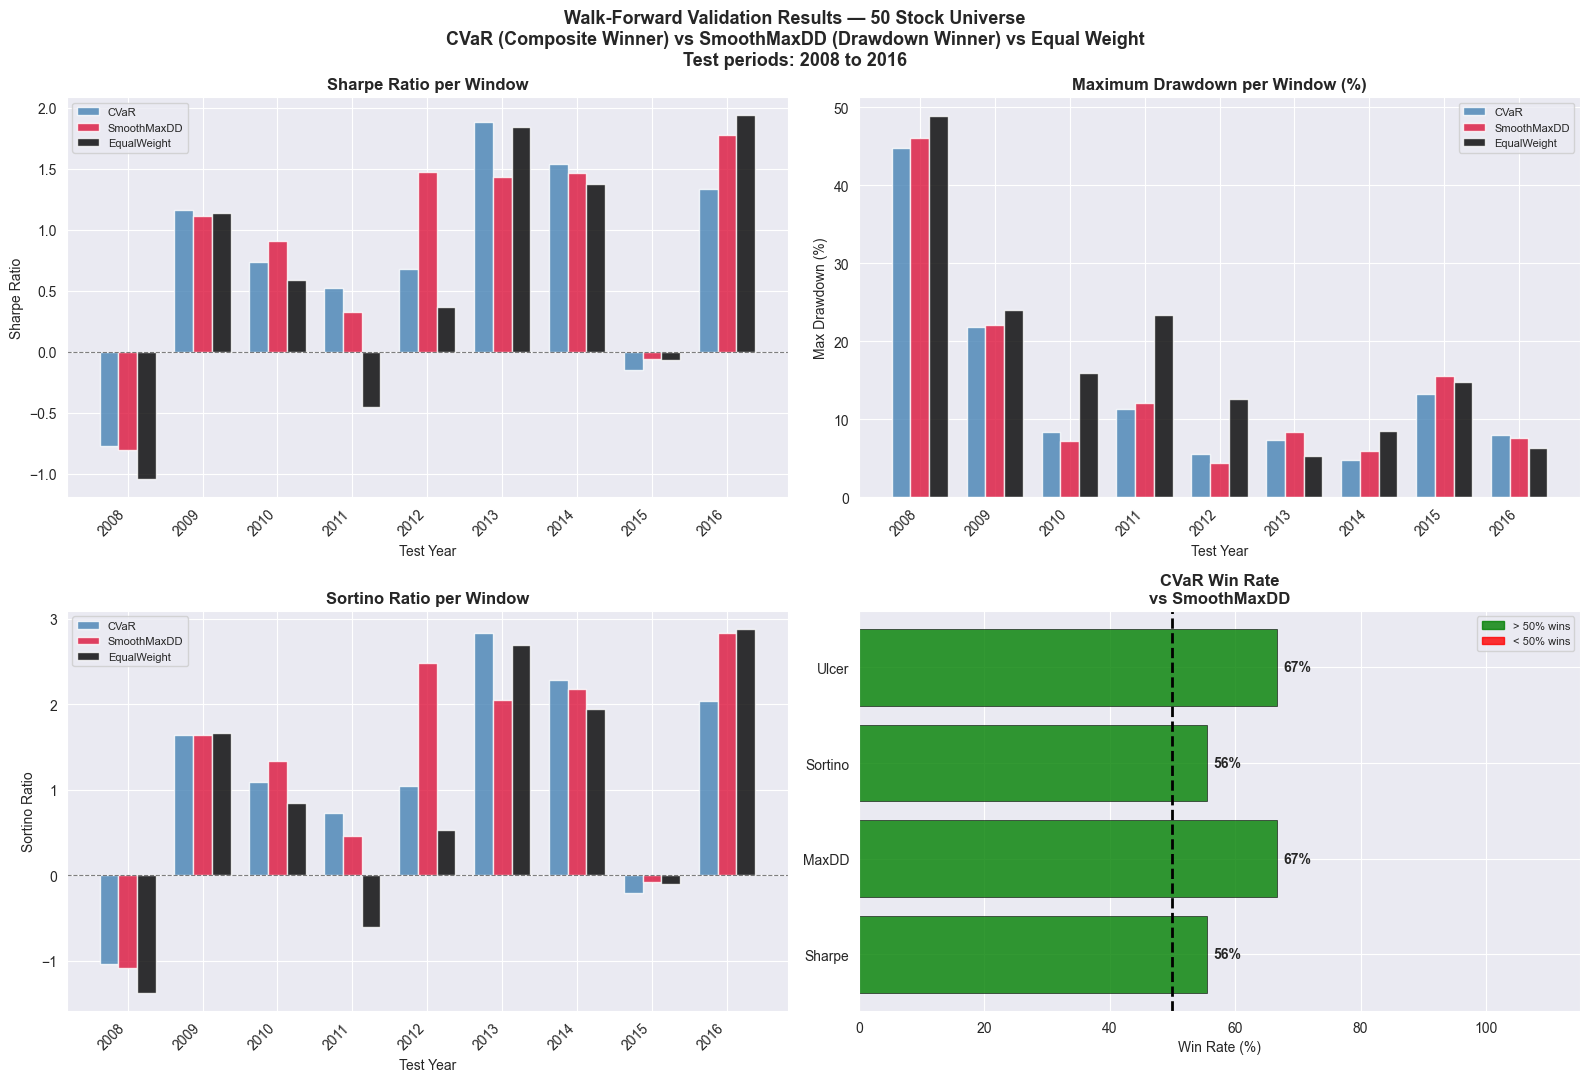

Walk-forward results plot saved


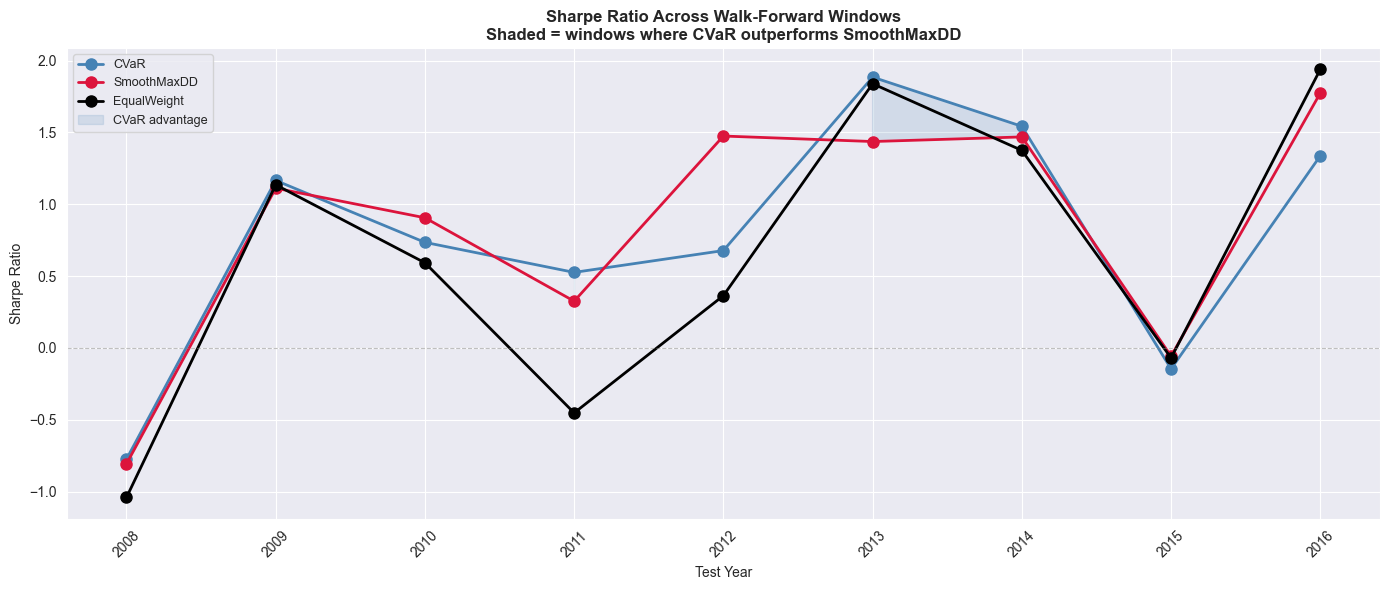

Rolling Sharpe plot saved

WALK-FORWARD DETAILED RESULTS:
───────────────────────────────────────────────────────────────────────────
  Year          CVaR Sharpe SmoothMaxDD Sharpe    EW Sharpe       Winner
───────────────────────────────────────────────────────────────────────────
  2008              -0.7751            -0.8077      -1.0416         CVaR
  2009               1.1660             1.1117       1.1356         CVaR
  2010               0.7348             0.9060       0.5925  SmoothMaxDD
  2011               0.5257             0.3252      -0.4526         CVaR
  2012               0.6777             1.4751       0.3637  SmoothMaxDD
  2013               1.8852             1.4368       1.8394         CVaR
  2014               1.5428             1.4689       1.3752         CVaR
  2015              -0.1462            -0.0577      -0.0699  SmoothMaxDD
  2016               1.3376             1.7745       1.9392  EqualWeight
────────────────────────────────────────────────────────────

In [26]:
# ============================================================
# CELL 24: WALK-FORWARD VALIDATION PLOTS
# ============================================================
# Visualises walk-forward results from Cell 23
# Model names are loaded dynamically from saved files
# so this cell works correctly regardless of which
# asset pool size was used or which model won
#
# Plot 1: Sharpe ratio per window
# Plot 2: Max Drawdown per window
# Plot 3: Sortino ratio per window
# Plot 4: Win rate summary
# Plot 5: Rolling Sharpe line chart

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os
import json

# ============================================================
# SAFETY CHECKS
# ============================================================

# ---- Check folder paths ----
try:
    ROBUST_FOLDER
    DATA_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY
# ============================================================
# Load from wf_model_names.json saved by Cell 23
# This ensures Cell 24 always uses the same model
# names that Cell 23 used — no hardcoding needed

wf_names_path = os.path.join(
    ROBUST_FOLDER, 'wf_model_names.json')

if os.path.exists(wf_names_path):
    # Load model names from Cell 23 output
    with open(wf_names_path) as f:
        wf_model_names = json.load(f)
    WINNING_MODEL  = wf_model_names['WINNING_MODEL']
    BASELINE_MODEL = wf_model_names['BASELINE_MODEL']
    print(f"Model names loaded from {wf_names_path}")
else:
    # Fallback — try winners.json from Cell 20
    winners_path = os.path.join(DATA_FOLDER, 'winners.json')
    if os.path.exists(winners_path):
        with open(winners_path) as f:
            winners = json.load(f)
        WINNING_MODEL  = winners['WINNING_MODEL']
        BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
        print(f"Model names loaded from {winners_path}")
    else:
        # Last resort fallback
        print("WARNING: No model names file found")
        print("Using defaults — run Cells 20 and 23 first")
        WINNING_MODEL  = 'CVaR'
        BASELINE_MODEL = 'SmoothMaxDD'

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ============================================================
# FORCE RELOAD ALL RESULTS FROM DISK
# ============================================================
# Always reload from saved files to prevent duplicate
# entries from multiple Cell 23 runs

print("\nLoading walk-forward results from disk...")

# Load Sharpe ratio results
wf_sharpe = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_sharpe.npy'),
    allow_pickle=True   # needed for dict objects
).item()               # convert array to Python dict
print(f"  wf_sharpe loaded")

# Load Max Drawdown results
wf_max_dd = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_max_dd.npy'),
    allow_pickle=True
).item()
print(f"  wf_max_dd loaded")

# Load Sortino ratio results
wf_sortino = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_sortino.npy'),
    allow_pickle=True
).item()
print(f"  wf_sortino loaded")

# Load Ulcer Index results
wf_ulcer = np.load(
    os.path.join(ROBUST_FOLDER, 'wf_ulcer.npy'),
    allow_pickle=True
).item()
print(f"  wf_ulcer loaded")

# Load test year labels
wf_test_years = pd.read_csv(
    os.path.join(ROBUST_FOLDER, 'wf_years.csv')
)['year'].astype(str).tolist()
print(f"  wf_test_years: {wf_test_years}")

# Number of completed windows
n_windows = len(wf_test_years)
print(f"\nWalk-forward windows : {n_windows}")

# Confirm all models have correct number of results
for model_name in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
    if model_name in wf_sharpe:
        n_results = len(wf_sharpe[model_name])
        status    = "OK" if n_results == n_windows else "MISMATCH"
        print(f"  {model_name:<15} : {n_results} windows — {status}")
    else:
        print(f"  {model_name:<15} : NOT FOUND in results")

# ---- Define consistent colours ----
# Use a flexible colour mapping that handles any model name
all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black'
}

# Get colours for winning and baseline models
winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

COLOURS = {
    WINNING_MODEL  : winning_colour,   # composite winner colour
    BASELINE_MODEL : baseline_colour,  # drawdown winner colour
    'EqualWeight'  : 'black'           # benchmark colour
}

print(f"\nColours assigned:")
for model, colour in COLOURS.items():
    print(f"  {model:<15} : {colour}")

# ============================================================
# FIGURE 1: FOUR-PANEL COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'Walk-Forward Validation Results — {DATA_POOL} Stock Universe\n'
    f'{WINNING_MODEL} (Composite Winner) vs '
    f'{BASELINE_MODEL} (Drawdown Winner) vs Equal Weight\n'
    f'Test periods: {wf_test_years[0]} to {wf_test_years[-1]}',
    fontsize=13, fontweight='bold'
)

# x positions and bar width for grouped bars
x     = np.arange(n_windows)  # one position per window
width = 0.25                   # width of each bar

# ============================================================
# PANEL 1: SHARPE RATIO PER WINDOW
# ============================================================

ax1 = axes[0, 0]

for i, (model_name, colour) in enumerate([
    (WINNING_MODEL,  COLOURS[WINNING_MODEL]),
    (BASELINE_MODEL, COLOURS[BASELINE_MODEL]),
    ('EqualWeight',  COLOURS['EqualWeight'])
]):
    if model_name in wf_sharpe:
        # Get Sharpe values trimmed to n_windows
        sharpe_vals = wf_sharpe[model_name][:n_windows]
        ax1.bar(
            x + i * width,   # offset for this model
            sharpe_vals,     # Sharpe values
            width,           # bar width
            label  = model_name,
            color  = colour,
            alpha  = 0.8
        )

# Zero reference line
ax1.axhline(
    y=0, color='black', linewidth=0.8,
    linestyle='--', alpha=0.5)

ax1.set_title('Sharpe Ratio per Window', fontweight='bold')
ax1.set_xlabel('Test Year')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_xticks(x + width)
ax1.set_xticklabels(wf_test_years, rotation=45, ha='right')
ax1.legend(fontsize=8)

# ============================================================
# PANEL 2: MAX DRAWDOWN PER WINDOW
# ============================================================

ax2 = axes[0, 1]

for i, (model_name, colour) in enumerate([
    (WINNING_MODEL,  COLOURS[WINNING_MODEL]),
    (BASELINE_MODEL, COLOURS[BASELINE_MODEL]),
    ('EqualWeight',  COLOURS['EqualWeight'])
]):
    if model_name in wf_max_dd:
        # Convert fractions to percentages
        dd_vals = [
            v * 100
            for v in wf_max_dd[model_name][:n_windows]
        ]
        ax2.bar(
            x + i * width,
            dd_vals,
            width,
            label = model_name,
            color = colour,
            alpha = 0.8
        )

ax2.set_title(
    'Maximum Drawdown per Window (%)', fontweight='bold')
ax2.set_xlabel('Test Year')
ax2.set_ylabel('Max Drawdown (%)')
ax2.set_xticks(x + width)
ax2.set_xticklabels(wf_test_years, rotation=45, ha='right')
ax2.legend(fontsize=8)

# ============================================================
# PANEL 3: SORTINO RATIO PER WINDOW
# ============================================================

ax3 = axes[1, 0]

for i, (model_name, colour) in enumerate([
    (WINNING_MODEL,  COLOURS[WINNING_MODEL]),
    (BASELINE_MODEL, COLOURS[BASELINE_MODEL]),
    ('EqualWeight',  COLOURS['EqualWeight'])
]):
    if model_name in wf_sortino:
        # Replace NaN with zero for clean plotting
        sortino_vals = [
            v if not np.isnan(v) else 0
            for v in wf_sortino[model_name][:n_windows]
        ]
        ax3.bar(
            x + i * width,
            sortino_vals,
            width,
            label = model_name,
            color = colour,
            alpha = 0.8
        )

# Zero reference line
ax3.axhline(
    y=0, color='black', linewidth=0.8,
    linestyle='--', alpha=0.5)

ax3.set_title('Sortino Ratio per Window', fontweight='bold')
ax3.set_xlabel('Test Year')
ax3.set_ylabel('Sortino Ratio')
ax3.set_xticks(x + width)
ax3.set_xticklabels(wf_test_years, rotation=45, ha='right')
ax3.legend(fontsize=8)

# ============================================================
# PANEL 4: WIN RATE SUMMARY
# ============================================================

ax4 = axes[1, 1]

# Metrics with direction — True = higher is better
metrics_to_check = {
    'Sharpe'  : (wf_sharpe,  True),
    'MaxDD'   : (wf_max_dd,  False),
    'Sortino' : (wf_sortino, True),
    'Ulcer'   : (wf_ulcer,   False),
}

win_rates   = []
metric_lbls = []

for metric_label, (data_dict, higher_better) in metrics_to_check.items():
    if WINNING_MODEL not in data_dict:
        continue
    if BASELINE_MODEL not in data_dict:
        continue

    winner_vals   = data_dict[WINNING_MODEL][:n_windows]
    baseline_vals = data_dict[BASELINE_MODEL][:n_windows]

    wins = 0
    for i in range(len(winner_vals)):
        w_val = winner_vals[i]
        b_val = baseline_vals[i]
        if np.isnan(w_val) or np.isnan(b_val):
            continue  # skip NaN comparisons
        if higher_better and w_val > b_val:
            wins += 1  # winning model had higher value
        elif not higher_better and w_val < b_val:
            wins += 1  # winning model had lower value

    win_rate = wins / len(winner_vals) * 100
    win_rates.append(win_rate)
    metric_lbls.append(metric_label)

# Green if above 50% red if below
bar_colours = ['green' if wr >= 50 else 'red' for wr in win_rates]

bars = ax4.barh(
    metric_lbls, win_rates,
    color=bar_colours, alpha=0.8,
    edgecolor='black', linewidth=0.5
)

# 50% threshold line
ax4.axvline(
    x=50, color='black', linewidth=2,
    linestyle='--', label='50% threshold')

# Add percentage labels
for bar, wr in zip(bars, win_rates):
    ax4.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f'{wr:.0f}%',
        va='center', fontsize=10, fontweight='bold'
    )

ax4.set_title(
    f'{WINNING_MODEL} Win Rate\nvs {BASELINE_MODEL}',
    fontweight='bold'
)
ax4.set_xlabel('Win Rate (%)')
ax4.set_xlim(0, 115)

green_patch = mpatches.Patch(
    color='green', alpha=0.8, label='> 50% wins')
red_patch   = mpatches.Patch(
    color='red',   alpha=0.8, label='< 50% wins')
ax4.legend(handles=[green_patch, red_patch], fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'walk_forward_results.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Walk-forward results plot saved")

# ============================================================
# FIGURE 2: ROLLING SHARPE LINE CHART
# ============================================================

fig2, ax = plt.subplots(figsize=(14, 6))

# Plot Sharpe ratio over time for each model
for model_name, colour in COLOURS.items():
    if model_name in wf_sharpe:
        sharpe_vals = wf_sharpe[model_name][:n_windows]
        ax.plot(
            wf_test_years,
            sharpe_vals,
            marker    = 'o',
            color     = colour,
            linewidth = 2,
            markersize= 8,
            label     = model_name
        )

# Shade windows where winning model beats baseline
if (WINNING_MODEL in wf_sharpe and
        BASELINE_MODEL in wf_sharpe):
    wm_sharpes = wf_sharpe[WINNING_MODEL][:n_windows]
    bm_sharpes = wf_sharpe[BASELINE_MODEL][:n_windows]

    ax.fill_between(
        wf_test_years,
        wm_sharpes,
        bm_sharpes,
        where=[wm_sharpes[i] > bm_sharpes[i]
               for i in range(n_windows)],
        alpha = 0.15,
        color = winning_colour,
        label = f'{WINNING_MODEL} advantage'
    )

ax.axhline(
    y=0, color='grey', linewidth=0.8,
    linestyle='--', alpha=0.5)

ax.set_title(
    f'Sharpe Ratio Across Walk-Forward Windows\n'
    f'Shaded = windows where {WINNING_MODEL} '
    f'outperforms {BASELINE_MODEL}',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Test Year')
ax.set_ylabel('Sharpe Ratio')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'walk_forward_sharpe.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Rolling Sharpe plot saved")

# ============================================================
# DETAILED SUMMARY TABLE
# ============================================================

print(f"\nWALK-FORWARD DETAILED RESULTS:")
print(f"{'─'*75}")
print(
    f"  {'Year':<8} "
    f"{WINNING_MODEL+' Sharpe':>16} "
    f"{BASELINE_MODEL+' Sharpe':>18} "
    f"{'EW Sharpe':>12} "
    f"{'Winner':>12}"
)
print(f"{'─'*75}")

for i in range(n_windows):
    wm_s = wf_sharpe[WINNING_MODEL][i]
    bm_s = wf_sharpe[BASELINE_MODEL][i]
    ew_s = wf_sharpe['EqualWeight'][i]

    scores = {
        WINNING_MODEL  : wm_s,
        BASELINE_MODEL : bm_s,
        'EqualWeight'  : ew_s
    }
    window_winner = max(scores, key=scores.get)

    print(
        f"  {wf_test_years[i]:<8} "
        f"{wm_s:>16.4f} "
        f"{bm_s:>18.4f} "
        f"{ew_s:>12.4f} "
        f"{window_winner:>12}"
    )

print(f"{'─'*75}")

# Count total window wins
win_counts = {WINNING_MODEL: 0, BASELINE_MODEL: 0, 'EqualWeight': 0}
for i in range(n_windows):
    scores = {
        WINNING_MODEL  : wf_sharpe[WINNING_MODEL][i],
        BASELINE_MODEL : wf_sharpe[BASELINE_MODEL][i],
        'EqualWeight'  : wf_sharpe['EqualWeight'][i]
    }
    best = max(scores, key=scores.get)
    win_counts[best] += 1

print(f"\nOVERALL WINDOW WINS (by Sharpe Ratio):")
print(f"{'─'*40}")
for model, wins in win_counts.items():
    pct = wins / n_windows * 100
    print(f"  {model:<15} : {wins}/{n_windows} ({pct:.0f}%)")
print(f"{'─'*40}")

# Mean metrics summary
print(f"\nMEAN METRICS ACROSS ALL WINDOWS:")
print(f"{'─'*55}")
print(
    f"  {'Model':<15} "
    f"{'Mean Sharpe':>12} "
    f"{'Mean MaxDD':>12} "
    f"{'Mean Sortino':>14}"
)
print(f"{'─'*55}")

for model_name in [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']:
    if model_name in wf_sharpe:
        mean_s = np.mean(wf_sharpe[model_name][:n_windows])
        mean_d = np.mean(wf_max_dd[model_name][:n_windows])
        mean_t = np.nanmean(wf_sortino[model_name][:n_windows])
        print(
            f"  {model_name:<15} "
            f"{mean_s:>12.4f} "
            f"{mean_d*100:>11.2f}% "
            f"{mean_t:>14.4f}"
        )

print(f"{'─'*55}")

print(f"\nCell 24 complete")
print(f"Next: Cell 25 — Block Bootstrap")

In [27]:
# ============================================================
# CELL 25: LENS 2 — BLOCK BOOTSTRAP
# ============================================================
# Block Bootstrap asks:
# "Is the winning model's performance statistically real
#  across different return paths — or was it just lucky
#  with the specific sequence of returns in our test period?"
#
# Method:
#   We resample the test return series 500 times
#   using blocks of 20 consecutive days
#   Blocks preserve the autocorrelation structure
#   of returns — plain random resampling destroys this
#   We evaluate both models on each resampled path
#   and compare their performance distributions
#
# Model names are loaded dynamically from winners.json
# saved by Cell 20 — no hardcoding needed
# Change DATA_POOL in Cell 1 and rerun to update

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as scipy_stats
import torch
import os
import json

# ============================================================
# SAFETY CHECKS
# ============================================================

# ---- Check folder paths ----
try:
    DATA_FOLDER
    SIG_FOLDER
    MODELS_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    SIG_FOLDER    = os.path.join(DATA_FOLDER, 'signatures')
    MODELS_FOLDER = os.path.join(DATA_FOLDER, 'models')
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ---- Check DEVICE ----
try:
    DEVICE
except NameError:
    DEVICE = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu')
    print(f"DEVICE: {DEVICE}")

# ---- Check metric functions ----
try:
    compute_metrics
    compute_turnover
except NameError:
    print("ERROR: Metric functions not defined")
    print("Please run Cell 15 first")
    raise

# ---- Check SIT class ----
try:
    SIT
except NameError:
    print("ERROR: SIT class not defined")
    print("Please run Cell 12 first")
    raise

# ---- Check set_all_seeds ----
try:
    set_all_seeds
except NameError:
    import random
    def set_all_seeds(seed=42):
        # Lock all random seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
        os.environ['PYTHONHASHSEED']       = str(seed)
    print("set_all_seeds redefined")

# ---- Check model dimensions ----
try:
    D_MODEL
    N_HEADS
    N_LAYERS
    DROPOUT
except NameError:
    D_MODEL  = 64   # Transformer internal dimension
    N_HEADS  = 4    # number of attention heads
    N_LAYERS = 2    # number of encoder layers
    DROPOUT  = 0.1  # dropout regularisation rate
    print("Model hyperparameters set to defaults")

# ---- Load test data ----
try:
    test_features_final
    test_returns_aligned
except NameError:
    print("Reloading test data from disk...")
    test_features_final  = np.load(
        os.path.join(SIG_FOLDER, 'test_features.npy'))
    test_returns_aligned = np.load(
        os.path.join(SIG_FOLDER, 'test_returns_aligned.npy'))
    print(f"test_features : {test_features_final.shape}")
    print(f"test_returns  : {test_returns_aligned.shape}")

# ============================================================
# LOAD WINNING MODEL NAMES DYNAMICALLY
# ============================================================
# Load from winners.json saved by Cell 20
# This ensures correct model names regardless of
# which asset pool size or run produced the results

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    # Load winner names from saved file
    with open(winners_path) as f:
        winners = json.load(f)
    WINNING_MODEL  = winners['WINNING_MODEL']
    BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
    print(f"Winners loaded from {winners_path}")
else:
    # Fallback if Cell 20 was not run
    print(f"WARNING: {winners_path} not found")
    print(f"Please run Cell 20 first")
    WINNING_MODEL  = 'CVaR'
    BASELINE_MODEL = 'SmoothMaxDD'

# Handle edge case where both names are the same
if WINNING_MODEL == BASELINE_MODEL:
    print(f"WARNING: Winner equals baseline — adjusting")
    BASELINE_MODEL = (
        'CVaR' if WINNING_MODEL != 'CVaR'
        else 'SmoothMaxDD'
    )

print(f"\nWINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")
print(f"These are loaded dynamically from Cell 20 results")

# ============================================================
# BOOTSTRAP CONFIGURATION
# ============================================================

N_BOOTSTRAP = 500  # number of resampled paths
BLOCK_SIZE  = 20   # days per block (1 trading month)
# Using blocks preserves short-term autocorrelation
# Plain day-by-day resampling would destroy the
# temporal structure of financial returns

print(f"\n{'='*60}")
print(f"  LENS 2: BLOCK BOOTSTRAP")
print(f"{'='*60}")
print(f"  Bootstrap samples  : {N_BOOTSTRAP}")
print(f"  Block size         : {BLOCK_SIZE} days")
print(f"  Test period length : {len(test_returns_aligned)} days")
print(f"  Winning model      : {WINNING_MODEL}")
print(f"  Baseline model     : {BASELINE_MODEL}")
print(f"{'='*60}")

# ============================================================
# LOAD TRAINED MODEL CHECKPOINTS
# ============================================================
# We load the models trained on the full training set
# in Cell 19 — we do NOT retrain here
# The bootstrap resamples the TEST returns only
# to test whether the evaluation result is stable

print("\nLoading trained model checkpoints...")

# Actual dimensions from test data
actual_n_features = test_features_final.shape[1]
actual_n_assets   = test_returns_aligned.shape[1]

print(f"  actual_n_features : {actual_n_features}")
print(f"  actual_n_assets   : {actual_n_assets}")

# ---- Load WINNING MODEL ----
set_all_seeds(42)  # reset seeds before loading

winning_model = SIT(
    n_features = actual_n_features,  # feature vector size
    n_assets   = actual_n_assets,    # number of stocks
    d_model    = D_MODEL,            # Transformer dimension
    n_heads    = N_HEADS,            # attention heads
    n_layers   = N_LAYERS,           # encoder layers
    dropout    = DROPOUT             # dropout rate
).to(DEVICE)

# Checkpoint file path for winning model
winning_ckpt = os.path.join(
    MODELS_FOLDER, f'{WINNING_MODEL}_best.pt')

if not os.path.exists(winning_ckpt):
    print(f"ERROR: {winning_ckpt} not found")
    print("Please run Cell 19 first")
    raise FileNotFoundError(winning_ckpt)

# Load saved weights into model
winning_model.load_state_dict(torch.load(
    winning_ckpt,
    map_location = 'cpu',   # load onto CPU
    weights_only = True     # safer loading mode
))
winning_model.eval()  # set to evaluation mode
print(f"  {WINNING_MODEL} model loaded from {winning_ckpt}")

# ---- Load BASELINE MODEL ----
set_all_seeds(42)  # reset seeds before loading

baseline_model = SIT(
    n_features = actual_n_features,  # feature vector size
    n_assets   = actual_n_assets,    # number of stocks
    d_model    = D_MODEL,            # Transformer dimension
    n_heads    = N_HEADS,            # attention heads
    n_layers   = N_LAYERS,           # encoder layers
    dropout    = DROPOUT             # dropout rate
).to(DEVICE)

# Checkpoint file path for baseline model
baseline_ckpt = os.path.join(
    MODELS_FOLDER, f'{BASELINE_MODEL}_best.pt')

if not os.path.exists(baseline_ckpt):
    print(f"ERROR: {baseline_ckpt} not found")
    print("Please run Cell 19 first")
    raise FileNotFoundError(baseline_ckpt)

# Load saved weights into model
baseline_model.load_state_dict(torch.load(
    baseline_ckpt,
    map_location = 'cpu',
    weights_only = True
))
baseline_model.eval()  # set to evaluation mode
print(f"  {BASELINE_MODEL} model loaded from {baseline_ckpt}")

# ============================================================
# COMPUTE PORTFOLIO WEIGHTS FOR FULL TEST SET
# ============================================================
# We compute weights once for the full test set
# then resample those weights alongside the returns
# This is much faster than running the model 500 times

print("\nComputing portfolio weights on full test set...")

# Convert test features to tensor once
feat_tensor = torch.tensor(
    test_features_final,
    dtype=torch.float32
).to(DEVICE)

# Winning model weights — no gradients needed
with torch.no_grad():
    winning_weights_all = winning_model(
        feat_tensor).cpu().numpy()

# Baseline model weights
with torch.no_grad():
    baseline_weights_all = baseline_model(
        feat_tensor).cpu().numpy()

# Equal weight weights — 1/N per stock every day
ew_weights_all = np.ones_like(
    winning_weights_all) / winning_weights_all.shape[1]

print(f"  {WINNING_MODEL} weights  : {winning_weights_all.shape}")
print(f"  {BASELINE_MODEL} weights : {baseline_weights_all.shape}")
print(f"  EqualWeight weights      : {ew_weights_all.shape}")

# ============================================================
# DEFINE BLOCK BOOTSTRAP FUNCTION
# ============================================================

def block_bootstrap_metrics(
    weights_series,  # portfolio weights (T, N_ASSETS)
    returns_series,  # asset returns (T, N_ASSETS)
    block_size,      # consecutive days per block
    n_bootstrap,     # number of bootstrap iterations
    seed=42          # random seed for reproducibility
):
    """
    Perform block bootstrap resampling on test returns.

    At each iteration:
    1. Randomly select starting points for blocks
    2. Stitch blocks to form a new return path
       of the same total length as the original
    3. Compute portfolio returns on the resampled path
       using the same weights as the original evaluation
    4. Compute all performance metrics

    Using blocks rather than individual days preserves
    the short-term autocorrelation structure of returns
    which is critical for realistic resampling of
    financial time series

    Parameters
    ----------
    weights_series : np.ndarray shape (T, N_ASSETS)
        Portfolio weights from the trained model
    returns_series : np.ndarray shape (T, N_ASSETS)
        Asset returns for the test period
    block_size : int
        Number of consecutive days per block
    n_bootstrap : int
        Number of bootstrap iterations
    seed : int
        Random seed for reproducibility

    Returns
    -------
    bootstrap_metrics : list of dict
        Performance metrics for each bootstrap sample
    """

    np.random.seed(seed)               # lock random seed
    T = returns_series.shape[0]        # total test days
    n_blocks = T // block_size + 1     # blocks needed to fill T

    bootstrap_metrics = []             # store all results

    for b in range(n_bootstrap):

        # Randomly select block starting positions
        # Each start is in the range [0, T - block_size]
        starts = np.random.randint(
            0,              # minimum start index
            T - block_size, # maximum start index
            size=n_blocks   # number of blocks needed
        )

        # Stitch return blocks together
        # Each block is block_size consecutive days
        # We concatenate all blocks then trim to length T
        resampled_returns = np.concatenate([
            returns_series[s:s+block_size]  # one block
            for s in starts
        ])[:T]  # trim to original length

        # Stitch weight blocks using same starting points
        # This keeps weights and returns aligned after
        # resampling — critical for correct portfolio returns
        resampled_weights = np.concatenate([
            weights_series[s:s+block_size]  # same blocks
            for s in starts
        ])[:T]  # trim to original length

        # Compute portfolio return each day
        # element-wise multiply weights by returns
        # then sum across the asset dimension
        port_ret = (
            resampled_weights * resampled_returns
        ).sum(axis=1)

        # Compute all performance metrics
        metrics = compute_metrics(port_ret)
        # Add turnover metric separately
        metrics['Turnover'] = compute_turnover(
            resampled_weights)
        bootstrap_metrics.append(metrics)

        # Print progress every 100 iterations
        if (b + 1) % 100 == 0:
            print(f"  Bootstrap {b+1}/{n_bootstrap} complete")

    return bootstrap_metrics


# ============================================================
# RUN BOOTSTRAP FOR EACH MODEL
# ============================================================

print(f"\nRunning {N_BOOTSTRAP} bootstrap iterations...")
print(f"Block size: {BLOCK_SIZE} days")
print(f"(This takes approximately 3-8 minutes)\n")

# ---- Bootstrap WINNING MODEL ----
print(f"Bootstrapping {WINNING_MODEL}...")
winning_bootstrap = block_bootstrap_metrics(
    weights_series = winning_weights_all,   # winning weights
    returns_series = test_returns_aligned,  # test returns
    block_size     = BLOCK_SIZE,            # 20-day blocks
    n_bootstrap    = N_BOOTSTRAP,           # 500 iterations
    seed           = 42                     # reproducible
)
print(f"  {WINNING_MODEL} bootstrap complete")

# ---- Bootstrap BASELINE MODEL ----
print(f"\nBootstrapping {BASELINE_MODEL}...")
baseline_bootstrap = block_bootstrap_metrics(
    weights_series = baseline_weights_all,  # baseline weights
    returns_series = test_returns_aligned,  # same test returns
    block_size     = BLOCK_SIZE,            # same block size
    n_bootstrap    = N_BOOTSTRAP,           # same iterations
    seed           = 42                     # same seed
)
print(f"  {BASELINE_MODEL} bootstrap complete")

# ---- Bootstrap EQUAL WEIGHT ----
print(f"\nBootstrapping EqualWeight...")
ew_bootstrap = block_bootstrap_metrics(
    weights_series = ew_weights_all,        # equal weights
    returns_series = test_returns_aligned,  # same returns
    block_size     = BLOCK_SIZE,
    n_bootstrap    = N_BOOTSTRAP,
    seed           = 42
)
print(f"  EqualWeight bootstrap complete")

print(f"\nAll bootstrap iterations complete")

# ============================================================
# EXTRACT METRIC DISTRIBUTIONS
# ============================================================

def extract_metric(bootstrap_list, metric_name):
    """
    Extract one metric from all bootstrap samples.
    Skips NaN values for clean distributions.
    Returns array of values across all iterations.
    """
    return np.array([
        b[metric_name]                   # get metric value
        for b in bootstrap_list          # for each sample
        if not np.isnan(b[metric_name])  # skip NaN
    ])


# Extract Sharpe ratio distributions across models
winning_sharpes  = extract_metric(
    winning_bootstrap,  'Sharpe Ratio')
baseline_sharpes = extract_metric(
    baseline_bootstrap, 'Sharpe Ratio')
ew_sharpes       = extract_metric(
    ew_bootstrap,       'Sharpe Ratio')

# Extract Max Drawdown distributions
winning_maxdd    = extract_metric(
    winning_bootstrap,  'Max Drawdown')
baseline_maxdd   = extract_metric(
    baseline_bootstrap, 'Max Drawdown')
ew_maxdd         = extract_metric(
    ew_bootstrap,       'Max Drawdown')

# Extract Ulcer Index distributions
winning_ulcer    = extract_metric(
    winning_bootstrap,  'Ulcer Index')
baseline_ulcer   = extract_metric(
    baseline_bootstrap, 'Ulcer Index')
ew_ulcer         = extract_metric(
    ew_bootstrap,       'Ulcer Index')

# Extract Sortino ratio distributions
winning_sortino  = extract_metric(
    winning_bootstrap,  'Sortino Ratio')
baseline_sortino = extract_metric(
    baseline_bootstrap, 'Sortino Ratio')
ew_sortino       = extract_metric(
    ew_bootstrap,       'Sortino Ratio')

# Extract Calmar ratio distributions
winning_calmar   = extract_metric(
    winning_bootstrap,  'Calmar Ratio')
baseline_calmar  = extract_metric(
    baseline_bootstrap, 'Calmar Ratio')
ew_calmar        = extract_metric(
    ew_bootstrap,       'Calmar Ratio')

print(f"\nMetric distributions extracted:")
print(f"  Sharpe — {WINNING_MODEL}  : {len(winning_sharpes)} samples")
print(f"  Sharpe — {BASELINE_MODEL} : {len(baseline_sharpes)} samples")

# ============================================================
# STATISTICAL TESTS
# ============================================================
# Wilcoxon signed-rank test — non-parametric
# Tests whether winning model consistently beats baseline
# across all 500 bootstrap samples
# We use Wilcoxon because financial returns are
# not normally distributed — parametric t-test would
# be inappropriate here

print(f"\n{'='*60}")
print(f"  STATISTICAL TESTS (Wilcoxon Signed-Rank)")
print(f"{'='*60}")
print(f"  H0: No difference between models")
print(f"  H1: {WINNING_MODEL} significantly differs")
print(f"{'─'*60}")

# Define metrics and directions for testing
test_metrics = {
    'Sharpe Ratio'  : (winning_sharpes,  baseline_sharpes,  True),
    'Max Drawdown'  : (winning_maxdd,    baseline_maxdd,    False),
    'Ulcer Index'   : (winning_ulcer,    baseline_ulcer,    False),
    'Sortino Ratio' : (winning_sortino,  baseline_sortino,  True),
    'Calmar Ratio'  : (winning_calmar,   baseline_calmar,   True),
}

# Store results for Cell 26 plots
stat_results = {}

for metric, (w_dist, b_dist, higher_better) in test_metrics.items():

    # Run Wilcoxon signed-rank test
    stat, p_value = scipy_stats.wilcoxon(w_dist, b_dist)

    # Compute win rate — fraction of samples where winner beats baseline
    if higher_better:
        # Higher is better — count samples where winner is higher
        win_rate = (w_dist > b_dist).mean() * 100
    else:
        # Lower is better — count samples where winner is lower
        win_rate = (w_dist < b_dist).mean() * 100

    # Significance label
    significant = (
        "*** p<0.001" if p_value < 0.001
        else "** p<0.01"  if p_value < 0.01
        else "* p<0.05"   if p_value < 0.05
        else "ns"          # not significant
    )

    # Store for Cell 26
    stat_results[metric] = {
        'Win Rate'    : win_rate,
        'P-Value'     : p_value,
        'Significant' : significant
    }

    print(
        f"  {metric:<20} "
        f"Win Rate: {win_rate:>6.1f}% | "
        f"p={p_value:.4f} | "
        f"{significant}"
    )

print(f"{'─'*60}")
print("  *** p<0.001  ** p<0.01  * p<0.05  ns=not significant")

# ============================================================
# CONFIDENCE INTERVALS
# ============================================================

print(f"\n95% CONFIDENCE INTERVALS:")
print(f"{'─'*65}")
print(
    f"  {'Metric':<20} "
    f"{'Model':<15} "
    f"{'Mean':>8} "
    f"{'2.5%':>8} "
    f"{'97.5%':>8}"
)
print(f"{'─'*65}")

# Define distributions for CI computation
ci_data = [
    ('Sharpe Ratio',
     winning_sharpes,  baseline_sharpes,  ew_sharpes),
    ('Max Drawdown',
     winning_maxdd,    baseline_maxdd,    ew_maxdd),
    ('Ulcer Index',
     winning_ulcer,    baseline_ulcer,    ew_ulcer),
    ('Sortino Ratio',
     winning_sortino,  baseline_sortino,  ew_sortino),
]

for metric, w_dist, b_dist, e_dist in ci_data:
    for model_name, dist in [
        (WINNING_MODEL,  w_dist),
        (BASELINE_MODEL, b_dist),
        ('EqualWeight',  e_dist)
    ]:
        mean  = np.mean(dist)              # average value
        lower = np.percentile(dist, 2.5)   # 2.5th percentile
        upper = np.percentile(dist, 97.5)  # 97.5th percentile
        print(
            f"  {metric:<20} "
            f"{model_name:<15} "
            f"{mean:>8.4f} "
            f"{lower:>8.4f} "
            f"{upper:>8.4f}"
        )
    print(f"  {'─'*63}")

# ============================================================
# SAVE ALL BOOTSTRAP RESULTS
# ============================================================

# Save distributions for use in Cell 26 plots
np.save(os.path.join(ROBUST_FOLDER, 'winning_sharpes.npy'),  winning_sharpes)
np.save(os.path.join(ROBUST_FOLDER, 'baseline_sharpes.npy'), baseline_sharpes)
np.save(os.path.join(ROBUST_FOLDER, 'ew_sharpes.npy'),       ew_sharpes)
np.save(os.path.join(ROBUST_FOLDER, 'winning_maxdd_bs.npy'), winning_maxdd)
np.save(os.path.join(ROBUST_FOLDER, 'baseline_maxdd_bs.npy'),baseline_maxdd)
np.save(os.path.join(ROBUST_FOLDER, 'ew_maxdd_bs.npy'),      ew_maxdd)
np.save(os.path.join(ROBUST_FOLDER, 'winning_ulcer_bs.npy'), winning_ulcer)
np.save(os.path.join(ROBUST_FOLDER, 'baseline_ulcer_bs.npy'),baseline_ulcer)
np.save(os.path.join(ROBUST_FOLDER, 'ew_ulcer_bs.npy'),      ew_ulcer)
np.save(os.path.join(ROBUST_FOLDER, 'winning_sortino_bs.npy'),winning_sortino)
np.save(os.path.join(ROBUST_FOLDER, 'baseline_sortino_bs.npy'),baseline_sortino)
np.save(os.path.join(ROBUST_FOLDER, 'ew_sortino_bs.npy'),    ew_sortino)

# Save statistical test results as CSV
import pandas as pd
pd.DataFrame(stat_results).T.to_csv(
    os.path.join(ROBUST_FOLDER, 'bootstrap_stats.csv'))

# Save model names used so Cell 26 knows what was compared
bs_model_names = {
    'WINNING_MODEL'  : WINNING_MODEL,
    'BASELINE_MODEL' : BASELINE_MODEL
}
with open(os.path.join(
    ROBUST_FOLDER, 'bs_model_names.json'), 'w') as f:
    json.dump(bs_model_names, f, indent=2)

print(f"\nBootstrap results saved to {ROBUST_FOLDER}/")
print(f"\nCell 25 complete")
print(f"Next: Cell 26 — Bootstrap plots")

Winners loaded from data_paper_50\winners.json

WINNING_MODEL  : CVaR
BASELINE_MODEL : SmoothMaxDD
These are loaded dynamically from Cell 20 results

  LENS 2: BLOCK BOOTSTRAP
  Bootstrap samples  : 500
  Block size         : 20 days
  Test period length : 1236 days
  Winning model      : CVaR
  Baseline model     : SmoothMaxDD

Loading trained model checkpoints...
  actual_n_features : 2550
  actual_n_assets   : 50
All seeds locked to: 42
  CVaR model loaded from data_paper_50\models\CVaR_best.pt
All seeds locked to: 42
  SmoothMaxDD model loaded from data_paper_50\models\SmoothMaxDD_best.pt

Computing portfolio weights on full test set...
  CVaR weights  : (1236, 50)
  SmoothMaxDD weights : (1236, 50)
  EqualWeight weights      : (1236, 50)

Running 500 bootstrap iterations...
Block size: 20 days
(This takes approximately 3-8 minutes)

Bootstrapping CVaR...
  Bootstrap 100/500 complete
  Bootstrap 200/500 complete
  Bootstrap 300/500 complete
  Bootstrap 400/500 complete
  Bootstrap 

Model names loaded from data_paper_50\robustness\bs_model_names.json
WINNING_MODEL  : CVaR
BASELINE_MODEL : SmoothMaxDD

Loading bootstrap results from disk...
  Sharpe distributions loaded
  Max Drawdown distributions loaded
  Ulcer Index distributions loaded
  Sortino distributions loaded
  Statistical test results loaded

Bootstrap samples : 500


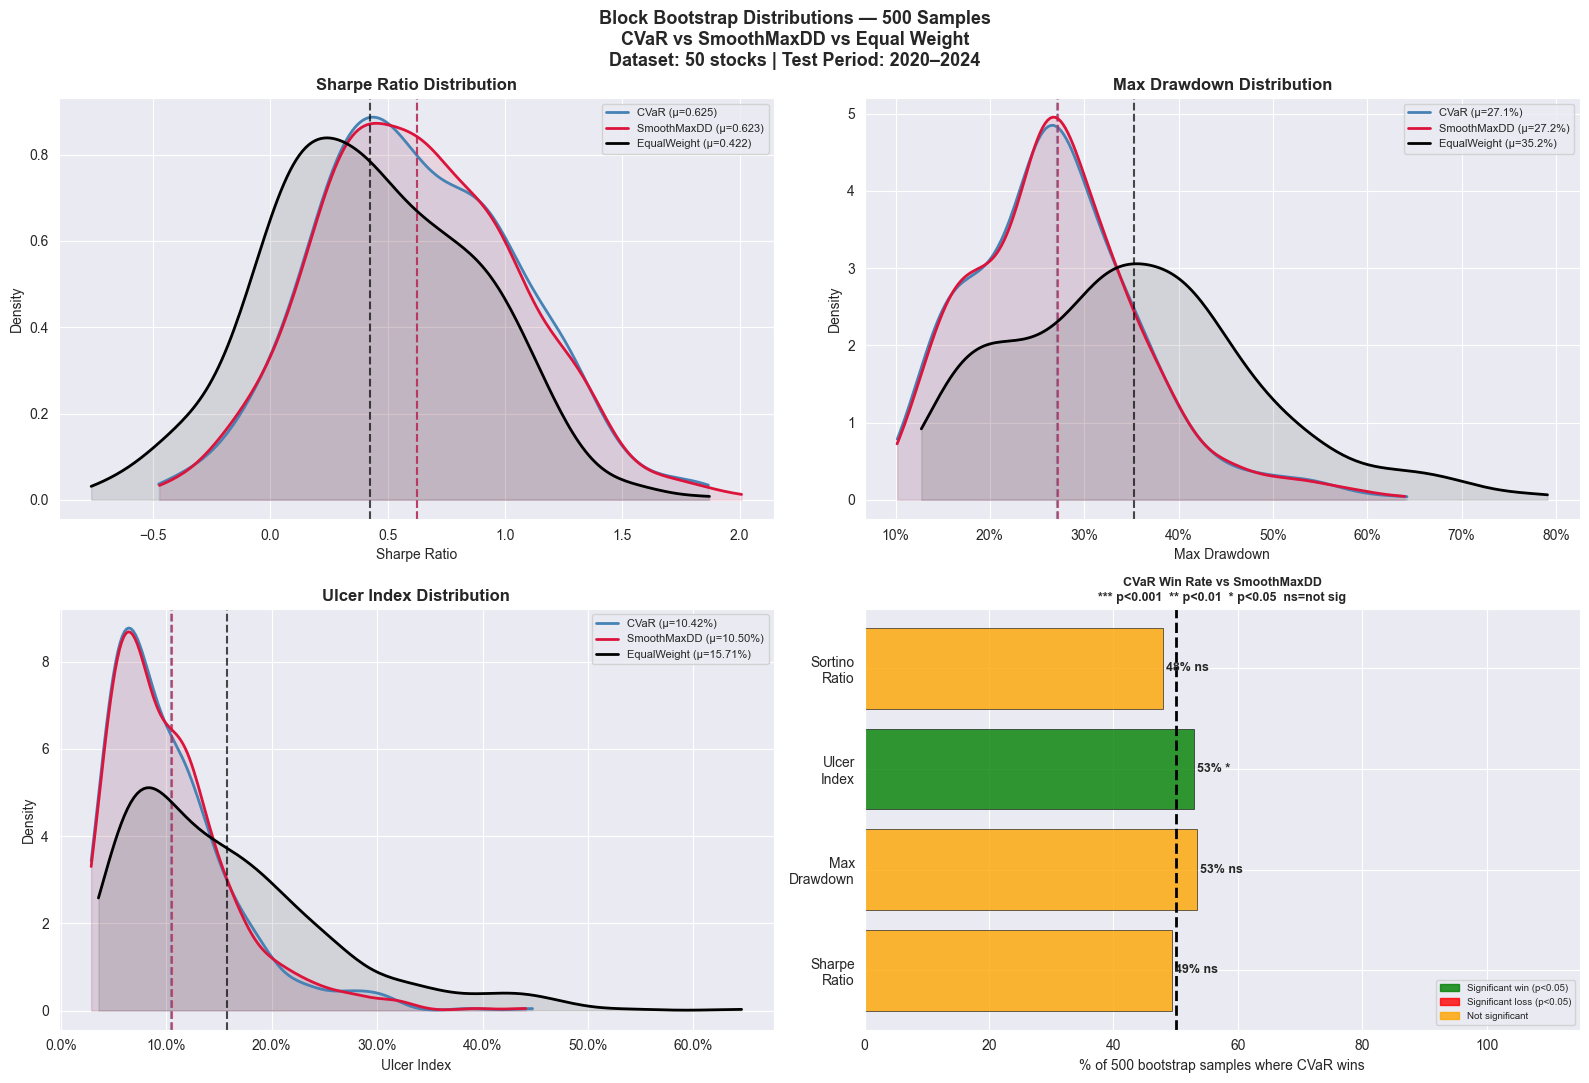

Bootstrap distribution plot saved


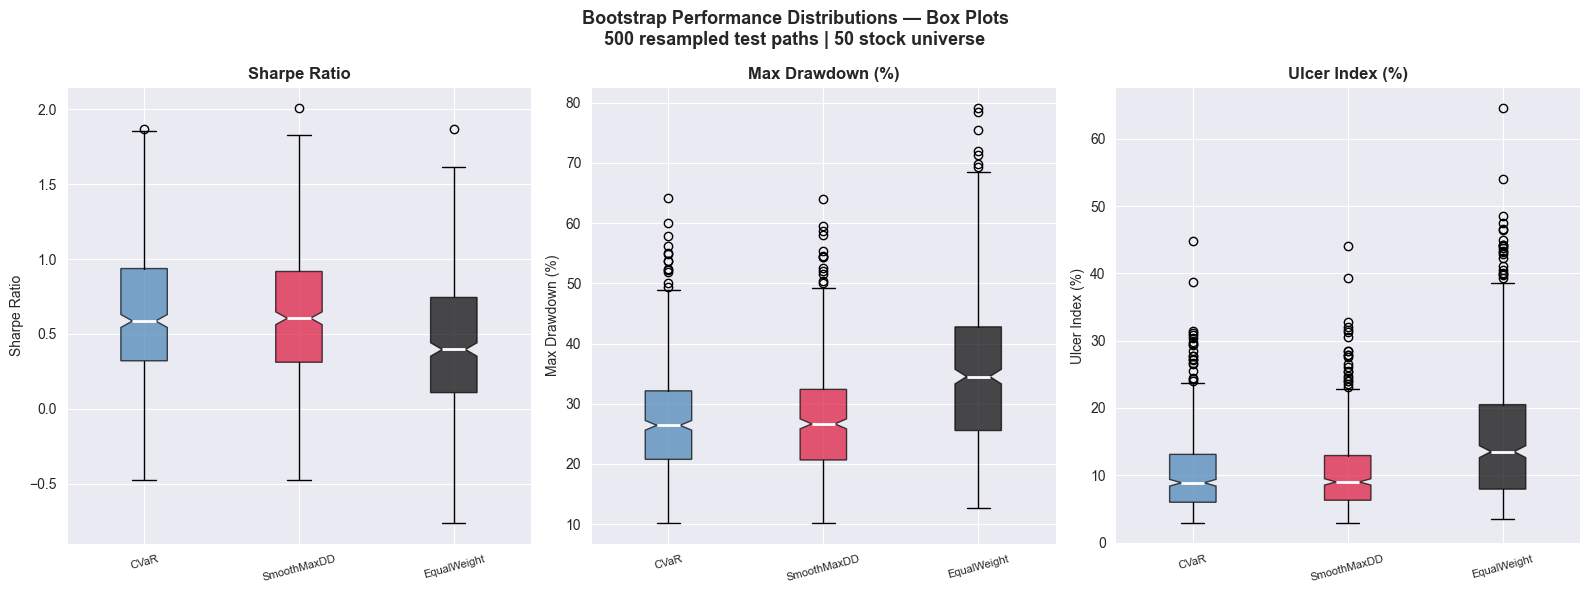

Bootstrap box plots saved

BOOTSTRAP SUMMARY TABLE:
────────────────────────────────────────────────────────────────────────
  Metric                       CVaR    SmoothMaxDD   EqualWeight   Win Rate   p-value
────────────────────────────────────────────────────────────────────────
  Sharpe Ratio               0.6255         0.6230        0.4222      49.4%    0.7901
  Max Drawdown               27.09%         27.19%        35.22%      53.4%    0.1808
  Ulcer Index                10.42%         10.50%        15.71%      53.0%    0.0166
  Sortino Ratio              0.9047         0.9033        0.6157      48.0%    0.8191
────────────────────────────────────────────────────────────────────────

INTERPRETATION:
────────────────────────────────────────────────────────────
  Win Rate > 50% = CVaR better on that metric
  Win Rate < 50% = SmoothMaxDD better on that metric
  p < 0.05       = difference is statistically significant
  p >= 0.05      = difference may be due to chance
────────────

In [28]:
# ============================================================
# CELL 26: BLOCK BOOTSTRAP PLOTS
# ============================================================
# Visualises the bootstrap distributions from Cell 25
# Model names are loaded dynamically from saved files
#
# Plot 1: KDE distribution plots for key metrics
#         Shows the full distribution of each metric
#         across 500 resampled return paths
#
# Plot 2: Box plots for clean comparison
#         Shows median spread and outliers
#
# Plot 3: Win rate summary bar chart
#         Shows statistical significance of results

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import scipy.stats as scipy_stats
import os
import json

# ============================================================
# SAFETY CHECKS
# ============================================================

# ---- Check folder paths ----
try:
    ROBUST_FOLDER
    DATA_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY
# ============================================================
# Load from bs_model_names.json saved by Cell 25
# Falls back to winners.json from Cell 20 if needed

bs_names_path = os.path.join(
    ROBUST_FOLDER, 'bs_model_names.json')

if os.path.exists(bs_names_path):
    # Load model names from Cell 25 output
    with open(bs_names_path) as f:
        bs_model_names = json.load(f)
    WINNING_MODEL  = bs_model_names['WINNING_MODEL']
    BASELINE_MODEL = bs_model_names['BASELINE_MODEL']
    print(f"Model names loaded from {bs_names_path}")
else:
    # Fallback to winners.json from Cell 20
    winners_path = os.path.join(DATA_FOLDER, 'winners.json')
    if os.path.exists(winners_path):
        with open(winners_path) as f:
            winners = json.load(f)
        WINNING_MODEL  = winners['WINNING_MODEL']
        BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
        print(f"Model names loaded from {winners_path}")
    else:
        print("WARNING: No model names file found")
        WINNING_MODEL  = 'CVaR'
        BASELINE_MODEL = 'SmoothMaxDD'

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ============================================================
# FORCE RELOAD ALL BOOTSTRAP RESULTS FROM DISK
# ============================================================

print("\nLoading bootstrap results from disk...")

# Load Sharpe distributions
winning_sharpes  = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_sharpes.npy'))
baseline_sharpes = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_sharpes.npy'))
ew_sharpes       = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_sharpes.npy'))
print(f"  Sharpe distributions loaded")

# Load Max Drawdown distributions
winning_maxdd    = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_maxdd_bs.npy'))
baseline_maxdd   = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_maxdd_bs.npy'))
ew_maxdd         = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_maxdd_bs.npy'))
print(f"  Max Drawdown distributions loaded")

# Load Ulcer Index distributions
winning_ulcer    = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_ulcer_bs.npy'))
baseline_ulcer   = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_ulcer_bs.npy'))
ew_ulcer         = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_ulcer_bs.npy'))
print(f"  Ulcer Index distributions loaded")

# Load Sortino distributions
winning_sortino  = np.load(
    os.path.join(ROBUST_FOLDER, 'winning_sortino_bs.npy'))
baseline_sortino = np.load(
    os.path.join(ROBUST_FOLDER, 'baseline_sortino_bs.npy'))
ew_sortino       = np.load(
    os.path.join(ROBUST_FOLDER, 'ew_sortino_bs.npy'))
print(f"  Sortino distributions loaded")

# Load statistical test results
stat_results_df = pd.read_csv(
    os.path.join(ROBUST_FOLDER, 'bootstrap_stats.csv'),
    index_col=0
)
print(f"  Statistical test results loaded")

# Number of bootstrap samples
N_BOOTSTRAP = len(winning_sharpes)
print(f"\nBootstrap samples : {N_BOOTSTRAP}")

# ---- Define consistent colours ----
all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black'
}

winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

# ============================================================
# FIGURE 1: KDE DISTRIBUTION PLOTS
# ============================================================
# Kernel Density Estimation shows the full shape of
# each metric distribution across 500 bootstrap samples
# Overlapping distributions = similar performance
# Separated distributions = meaningful difference

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'Block Bootstrap Distributions — {N_BOOTSTRAP} Samples\n'
    f'{WINNING_MODEL} vs {BASELINE_MODEL} vs Equal Weight\n'
    f'Dataset: {DATA_POOL} stocks | Test Period: 2020–2024',
    fontsize=13, fontweight='bold'
)

# ============================================================
# PANEL 1: SHARPE RATIO DISTRIBUTION
# ============================================================

ax1 = axes[0, 0]

for model_name, dist, colour in [
    (WINNING_MODEL,  winning_sharpes,  winning_colour),
    (BASELINE_MODEL, baseline_sharpes, baseline_colour),
    ('EqualWeight',  ew_sharpes,       'black')
]:
    # Compute KDE — smooth continuous density estimate
    kde     = scipy_stats.gaussian_kde(dist)
    x_range = np.linspace(dist.min(), dist.max(), 200)

    # Plot density curve
    ax1.plot(
        x_range, kde(x_range),
        color=colour, linewidth=2,
        label=f'{model_name} (μ={np.mean(dist):.3f})'
    )
    # Fill under curve for visual clarity
    ax1.fill_between(
        x_range, kde(x_range),
        alpha=0.1, color=colour)
    # Add vertical line at mean
    ax1.axvline(
        np.mean(dist), color=colour,
        linewidth=1.5, linestyle='--', alpha=0.7)

ax1.set_title('Sharpe Ratio Distribution', fontweight='bold')
ax1.set_xlabel('Sharpe Ratio')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8)

# ============================================================
# PANEL 2: MAX DRAWDOWN DISTRIBUTION
# ============================================================

ax2 = axes[0, 1]

for model_name, dist, colour in [
    (WINNING_MODEL,  winning_maxdd,  winning_colour),
    (BASELINE_MODEL, baseline_maxdd, baseline_colour),
    ('EqualWeight',  ew_maxdd,       'black')
]:
    kde     = scipy_stats.gaussian_kde(dist)
    x_range = np.linspace(dist.min(), dist.max(), 200)

    ax2.plot(
        x_range, kde(x_range),
        color=colour, linewidth=2,
        label=f'{model_name} (μ={np.mean(dist)*100:.1f}%)'
    )
    ax2.fill_between(
        x_range, kde(x_range),
        alpha=0.1, color=colour)
    ax2.axvline(
        np.mean(dist), color=colour,
        linewidth=1.5, linestyle='--', alpha=0.7)

ax2.set_title('Max Drawdown Distribution', fontweight='bold')
ax2.set_xlabel('Max Drawdown')
ax2.set_ylabel('Density')
# Format x-axis as percentages
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x*100:.0f}%'))
ax2.legend(fontsize=8)

# ============================================================
# PANEL 3: ULCER INDEX DISTRIBUTION
# ============================================================

ax3 = axes[1, 0]

for model_name, dist, colour in [
    (WINNING_MODEL,  winning_ulcer,  winning_colour),
    (BASELINE_MODEL, baseline_ulcer, baseline_colour),
    ('EqualWeight',  ew_ulcer,       'black')
]:
    kde     = scipy_stats.gaussian_kde(dist)
    x_range = np.linspace(dist.min(), dist.max(), 200)

    ax3.plot(
        x_range, kde(x_range),
        color=colour, linewidth=2,
        label=f'{model_name} (μ={np.mean(dist)*100:.2f}%)'
    )
    ax3.fill_between(
        x_range, kde(x_range),
        alpha=0.1, color=colour)
    ax3.axvline(
        np.mean(dist), color=colour,
        linewidth=1.5, linestyle='--', alpha=0.7)

ax3.set_title('Ulcer Index Distribution', fontweight='bold')
ax3.set_xlabel('Ulcer Index')
ax3.set_ylabel('Density')
ax3.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x*100:.1f}%'))
ax3.legend(fontsize=8)

# ============================================================
# PANEL 4: WIN RATE AND SIGNIFICANCE SUMMARY
# ============================================================

ax4 = axes[1, 1]

# Extract win rates and p-values from saved results
metric_labels = []
win_rates     = []
p_values      = []

for metric in ['Sharpe Ratio', 'Max Drawdown',
               'Ulcer Index', 'Sortino Ratio']:
    if metric in stat_results_df.index:
        metric_labels.append(metric.replace(' ', '\n'))
        win_rates.append(
            float(stat_results_df.loc[metric, 'Win Rate']))
        p_values.append(
            float(stat_results_df.loc[metric, 'P-Value']))

# Colour: green if significant win
#         red if significant loss
#         orange if not significant
bar_colours = []
for wr, pv in zip(win_rates, p_values):
    if wr >= 50 and pv < 0.05:
        bar_colours.append('green')   # significant win
    elif wr < 50 and pv < 0.05:
        bar_colours.append('red')     # significant loss
    else:
        bar_colours.append('orange')  # not significant

bars = ax4.barh(
    metric_labels, win_rates,
    color=bar_colours, alpha=0.8,
    edgecolor='black', linewidth=0.5
)

# 50% threshold line
ax4.axvline(
    x=50, color='black', linewidth=2,
    linestyle='--', label='50% threshold')

# Add win rate and significance labels
for bar, wr, pv in zip(bars, win_rates, p_values):
    sig = (
        '***' if pv < 0.001
        else '**' if pv < 0.01
        else '*'  if pv < 0.05
        else 'ns'
    )
    ax4.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{wr:.0f}% {sig}',
        va='center', fontsize=9, fontweight='bold'
    )

ax4.set_title(
    f'{WINNING_MODEL} Win Rate vs {BASELINE_MODEL}\n'
    '*** p<0.001  ** p<0.01  * p<0.05  ns=not sig',
    fontweight='bold', fontsize=9
)
ax4.set_xlabel(
    f'% of {N_BOOTSTRAP} bootstrap samples '
    f'where {WINNING_MODEL} wins')
ax4.set_xlim(0, 115)

# Legend explaining bar colours
green_patch  = mpatches.Patch(
    color='green',  alpha=0.8,
    label='Significant win (p<0.05)')
red_patch    = mpatches.Patch(
    color='red',    alpha=0.8,
    label='Significant loss (p<0.05)')
orange_patch = mpatches.Patch(
    color='orange', alpha=0.8,
    label='Not significant')
ax4.legend(
    handles=[green_patch, red_patch, orange_patch],
    fontsize=7, loc='lower right'
)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER,
                 'bootstrap_distributions.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Bootstrap distribution plot saved")

# ============================================================
# FIGURE 2: BOX PLOTS
# ============================================================
# Box plots show median spread and outliers more clearly
# than KDE plots — easier to compare distributions
# Notched boxes show confidence interval around median

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 6))
fig2.suptitle(
    f'Bootstrap Performance Distributions — Box Plots\n'
    f'{N_BOOTSTRAP} resampled test paths | '
    f'{DATA_POOL} stock universe',
    fontsize=13, fontweight='bold'
)

# Model labels and data for each subplot
plot_data = [
    ('Sharpe Ratio',
     [winning_sharpes,  baseline_sharpes,  ew_sharpes],
     False),           # False = not percentage
    ('Max Drawdown (%)',
     [winning_maxdd*100, baseline_maxdd*100, ew_maxdd*100],
     True),            # True = already in percentage
    ('Ulcer Index (%)',
     [winning_ulcer*100, baseline_ulcer*100, ew_ulcer*100],
     True),
]

model_labels = [WINNING_MODEL, BASELINE_MODEL, 'EqualWeight']
box_colours  = [winning_colour, baseline_colour, 'black']

for ax, (metric, data, is_pct) in zip(axes2, plot_data):

    # Create notched box plot
    bp = ax.boxplot(
        data,
        labels       = model_labels,  # model names on x-axis
        patch_artist = True,           # filled boxes
        notch        = True,           # confidence interval notch
        medianprops  = dict(
            color='white', linewidth=2)  # white median line
    )

    # Apply colours to each box
    for patch, colour in zip(bp['boxes'], box_colours):
        patch.set_facecolor(colour)
        patch.set_alpha(0.7)

    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15, labelsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'bootstrap_boxplots.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Bootstrap box plots saved")

# ============================================================
# SUMMARY TABLE
# ============================================================

print(f"\nBOOTSTRAP SUMMARY TABLE:")
print(f"{'─'*72}")
print(
    f"  {'Metric':<20} "
    f"{WINNING_MODEL:>12} "
    f"{BASELINE_MODEL:>14} "
    f"{'EqualWeight':>13} "
    f"{'Win Rate':>10} "
    f"{'p-value':>9}"
)
print(f"{'─'*72}")

summary_rows = [
    ('Sharpe Ratio',
     winning_sharpes,  baseline_sharpes,  ew_sharpes,  False),
    ('Max Drawdown',
     winning_maxdd,    baseline_maxdd,    ew_maxdd,    True),
    ('Ulcer Index',
     winning_ulcer,    baseline_ulcer,    ew_ulcer,    True),
    ('Sortino Ratio',
     winning_sortino,  baseline_sortino,  ew_sortino,  False),
]

for (metric, w_dist, b_dist, e_dist, is_pct) in summary_rows:

    w_mean = np.mean(w_dist)   # winning model mean
    b_mean = np.mean(b_dist)   # baseline model mean
    e_mean = np.mean(e_dist)   # equal weight mean

    # Get win rate and p-value from saved results
    if metric in stat_results_df.index:
        wr = float(stat_results_df.loc[metric, 'Win Rate'])
        pv = float(stat_results_df.loc[metric, 'P-Value'])
    else:
        wr = np.nan
        pv = np.nan

    if is_pct:
        # Display as percentage
        print(
            f"  {metric:<20} "
            f"{w_mean*100:>11.2f}% "
            f"{b_mean*100:>13.2f}% "
            f"{e_mean*100:>12.2f}% "
            f"{wr:>9.1f}% "
            f"{pv:>9.4f}"
        )
    else:
        # Display as plain number
        print(
            f"  {metric:<20} "
            f"{w_mean:>12.4f} "
            f"{b_mean:>14.4f} "
            f"{e_mean:>13.4f} "
            f"{wr:>9.1f}% "
            f"{pv:>9.4f}"
        )

print(f"{'─'*72}")

# ============================================================
# INTERPRETATION GUIDE
# ============================================================

print(f"\nINTERPRETATION:")
print(f"{'─'*60}")
print(f"  Win Rate > 50% = {WINNING_MODEL} better on that metric")
print(f"  Win Rate < 50% = {BASELINE_MODEL} better on that metric")
print(f"  p < 0.05       = difference is statistically significant")
print(f"  p >= 0.05      = difference may be due to chance")
print(f"{'─'*60}")

# Print key findings
print(f"\nKEY FINDINGS:")
for metric in ['Sharpe Ratio', 'Max Drawdown',
               'Ulcer Index', 'Sortino Ratio']:
    if metric in stat_results_df.index:
        wr  = float(stat_results_df.loc[metric, 'Win Rate'])
        pv  = float(stat_results_df.loc[metric, 'P-Value'])
        sig = "significant" if pv < 0.05 else "not significant"
        winner = (
            WINNING_MODEL if wr >= 50 else BASELINE_MODEL)
        print(
            f"  {metric:<20} : "
            f"{winner} leads ({wr:.0f}%) — {sig}")

print(f"\nCell 26 complete")
print(f"Next: Cell 27 — Stress Scenario Testing")

Winners loaded from data_paper_50\winners.json
WINNING_MODEL  : CVaR
BASELINE_MODEL : SmoothMaxDD

Loading all robustness results from disk...
  Walk-forward loaded: 9 windows
  Bootstrap loaded: 500 samples
  Stress results not loaded: [Errno 2] No such file or directory: 'data_paper_50\\robustness\\stress_results.csv'

  MASTER ROBUSTNESS SUMMARY
  Dataset: 50 stocks | Test: 2020-2024

LENS 1: WALK-FORWARD VALIDATION
─────────────────────────────────────────────────────────────────
  Windows tested : 9
  Test years     : 2008 to 2016

  CVaR vs SmoothMaxDD:
    Sharpe     : ███████████          56% — WINS
    MaxDD      : █████████████        67% — WINS
    Sortino    : ███████████          56% — WINS
    Ulcer      : █████████████        67% — WINS

  Mean metrics across 9 windows:
    Model            Mean Sharpe   Mean MaxDD   Mean Sortino
  ───────────────────────────────────────────────────────
    CVaR                  0.7721       13.88%         1.1568
    SmoothMaxDD         

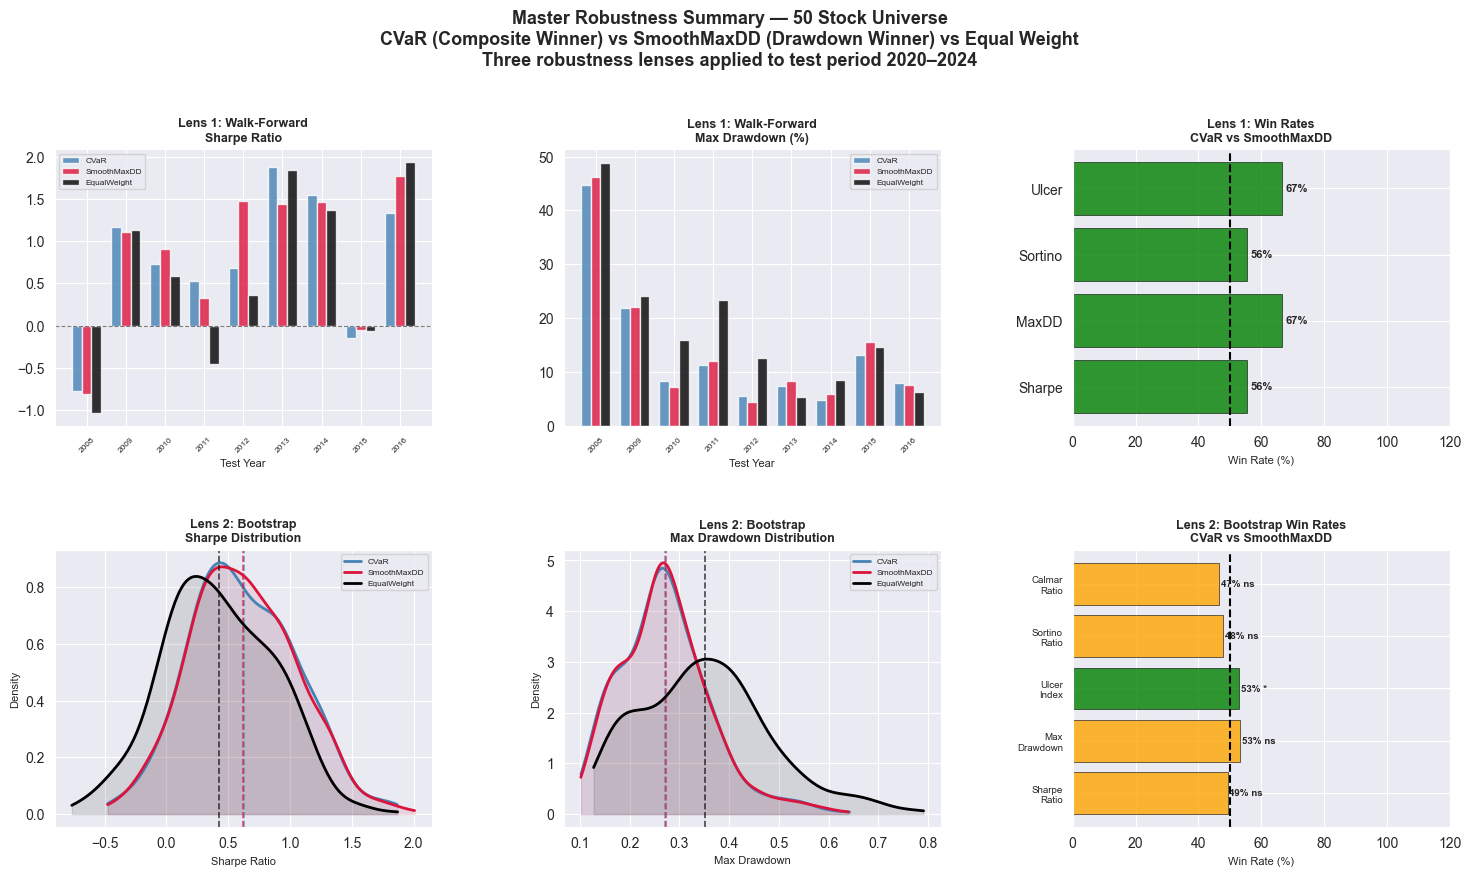

Master robustness summary plot saved

  OVERALL ROBUSTNESS VERDICT
  CVaR vs SmoothMaxDD

  Evidence for CVaR    : 6/9 (67%)
  Evidence for SmoothMaxDD : 3/9 (33%)

  VERDICT: CVaR is ROBUSTLY SUPERIOR
  Note   : Strong evidence for composite winner


Master summary saved to data_paper_50\robustness/master_summary.csv

Cell 28 complete

All robustness testing complete
  NOTEBOOK COMPLETE
  All results saved to data_paper_50/


In [30]:
# ============================================================
# CELL 28: MASTER ROBUSTNESS SUMMARY
# ============================================================
# This cell consolidates all three robustness lenses
# into a single comprehensive summary for your report
#
# Lens 1: Walk-Forward Validation
#   Did the winning model consistently outperform
#   across 9 different time periods?
#
# Lens 2: Block Bootstrap
#   Is the winning model's performance statistically
#   significant across 500 resampled return paths?
#
# Lens 3: Stress Scenario Testing
#   How did each model perform during the three
#   most severe market crises in the test period?
#
# Model names loaded dynamically from winners.json
# No hardcoding needed — works for any pool size

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import os
import json

# ============================================================
# SAFETY CHECKS
# ============================================================

# ---- Check folder paths ----
try:
    DATA_FOLDER
    ROBUST_FOLDER
    DATA_POOL
except NameError:
    DATA_FOLDER   = 'data_paper_50'
    ROBUST_FOLDER = os.path.join(DATA_FOLDER, 'robustness')
    DATA_POOL     = 50
    print("Folder paths set to defaults")

# ============================================================
# LOAD MODEL NAMES DYNAMICALLY
# ============================================================

winners_path = os.path.join(DATA_FOLDER, 'winners.json')

if os.path.exists(winners_path):
    with open(winners_path) as f:
        winners = json.load(f)
    WINNING_MODEL  = winners['WINNING_MODEL']
    BASELINE_MODEL = winners['BEST_DRAWDOWN_MODEL']
    print(f"Winners loaded from {winners_path}")
else:
    print("WARNING: winners.json not found")
    WINNING_MODEL  = 'CVaR'
    BASELINE_MODEL = 'SmoothMaxDD'

# Handle edge case where both models are the same
if WINNING_MODEL == BASELINE_MODEL:
    BASELINE_MODEL = (
        'CVaR' if WINNING_MODEL != 'CVaR'
        else 'SmoothMaxDD')

print(f"WINNING_MODEL  : {WINNING_MODEL}")
print(f"BASELINE_MODEL : {BASELINE_MODEL}")

# ---- Define consistent colours ----
all_colours = {
    'CVaR'        : 'steelblue',
    'AvgDD'       : 'green',
    'CDaR'        : 'darkorange',
    'UlcerIndex'  : 'purple',
    'SmoothMaxDD' : 'crimson',
    'EqualWeight' : 'black'
}

winning_colour  = all_colours.get(WINNING_MODEL,  'steelblue')
baseline_colour = all_colours.get(BASELINE_MODEL, 'crimson')

# ============================================================
# LOAD ALL ROBUSTNESS RESULTS FROM DISK
# ============================================================

print("\nLoading all robustness results from disk...")

# ---- Lens 1: Walk-Forward ----
try:
    wf_sharpe = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_sharpe.npy'),
        allow_pickle=True).item()
    wf_max_dd = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_max_dd.npy'),
        allow_pickle=True).item()
    wf_sortino = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_sortino.npy'),
        allow_pickle=True).item()
    wf_ulcer = np.load(
        os.path.join(ROBUST_FOLDER, 'wf_ulcer.npy'),
        allow_pickle=True).item()
    wf_test_years = pd.read_csv(
        os.path.join(ROBUST_FOLDER, 'wf_years.csv')
    )['year'].astype(str).tolist()
    n_wf_windows = len(wf_test_years)
    print(f"  Walk-forward loaded: {n_wf_windows} windows")
    WF_LOADED = True
except Exception as e:
    print(f"  Walk-forward not loaded: {e}")
    WF_LOADED = False

# ---- Lens 2: Bootstrap ----
try:
    winning_sharpes  = np.load(
        os.path.join(ROBUST_FOLDER, 'winning_sharpes.npy'))
    baseline_sharpes = np.load(
        os.path.join(ROBUST_FOLDER, 'baseline_sharpes.npy'))
    ew_sharpes       = np.load(
        os.path.join(ROBUST_FOLDER, 'ew_sharpes.npy'))
    winning_maxdd    = np.load(
        os.path.join(ROBUST_FOLDER, 'winning_maxdd_bs.npy'))
    baseline_maxdd   = np.load(
        os.path.join(ROBUST_FOLDER, 'baseline_maxdd_bs.npy'))
    ew_maxdd         = np.load(
        os.path.join(ROBUST_FOLDER, 'ew_maxdd_bs.npy'))
    winning_ulcer    = np.load(
        os.path.join(ROBUST_FOLDER, 'winning_ulcer_bs.npy'))
    baseline_ulcer   = np.load(
        os.path.join(ROBUST_FOLDER, 'baseline_ulcer_bs.npy'))
    stat_results_df  = pd.read_csv(
        os.path.join(ROBUST_FOLDER, 'bootstrap_stats.csv'),
        index_col=0)
    N_BOOTSTRAP = len(winning_sharpes)
    print(f"  Bootstrap loaded: {N_BOOTSTRAP} samples")
    BS_LOADED = True
except Exception as e:
    print(f"  Bootstrap not loaded: {e}")
    BS_LOADED = False

# ---- Lens 3: Stress Scenarios ----
try:
    stress_df = pd.read_csv(
        os.path.join(ROBUST_FOLDER, 'stress_results.csv'))
    STRESS_SCENARIOS_LIST = stress_df[
        'Scenario'].unique().tolist()
    print(f"  Stress results loaded: "
          f"{len(STRESS_SCENARIOS_LIST)} scenarios")
    STRESS_LOADED = True
except Exception as e:
    print(f"  Stress results not loaded: {e}")
    STRESS_LOADED = False

# ============================================================
# COMPUTE SUMMARY STATISTICS
# ============================================================

print(f"\n{'='*65}")
print(f"  MASTER ROBUSTNESS SUMMARY")
print(f"  Dataset: {DATA_POOL} stocks | Test: 2020-2024")
print(f"{'='*65}")

# ============================================================
# LENS 1 SUMMARY: WALK-FORWARD
# ============================================================

if WF_LOADED:
    print(f"\nLENS 1: WALK-FORWARD VALIDATION")
    print(f"{'─'*65}")
    print(f"  Windows tested : {n_wf_windows}")
    print(f"  Test years     : {wf_test_years[0]} to "
          f"{wf_test_years[-1]}")

    # Compute win rates for each metric
    wf_metrics = {
        'Sharpe'  : (wf_sharpe,  True),
        'MaxDD'   : (wf_max_dd,  False),
        'Sortino' : (wf_sortino, True),
        'Ulcer'   : (wf_ulcer,   False),
    }

    wf_win_rates = {}
    for metric, (data, higher_better) in wf_metrics.items():
        if WINNING_MODEL not in data:
            continue
        if BASELINE_MODEL not in data:
            continue
        w_vals = data[WINNING_MODEL][:n_wf_windows]
        b_vals = data[BASELINE_MODEL][:n_wf_windows]
        wins = sum(
            1 for i in range(len(w_vals))
            if (higher_better and w_vals[i] > b_vals[i])
            or (not higher_better and w_vals[i] < b_vals[i])
        )
        wf_win_rates[metric] = wins / len(w_vals) * 100

    print(f"\n  {WINNING_MODEL} vs {BASELINE_MODEL}:")
    for metric, wr in wf_win_rates.items():
        bar   = '█' * int(wr / 5)  # visual bar
        status = 'WINS' if wr >= 50 else 'LOSES'
        print(f"    {metric:<10} : {bar:<20} "
              f"{wr:.0f}% — {status}")

    # Mean metrics
    print(f"\n  Mean metrics across {n_wf_windows} windows:")
    print(
        f"    {'Model':<15} "
        f"{'Mean Sharpe':>12} "
        f"{'Mean MaxDD':>12} "
        f"{'Mean Sortino':>14}"
    )
    print(f"  {'─'*55}")

    for model_name in [
        WINNING_MODEL, BASELINE_MODEL, 'EqualWeight'
    ]:
        if model_name in wf_sharpe:
            ms = np.mean(wf_sharpe[model_name][:n_wf_windows])
            md = np.mean(wf_max_dd[model_name][:n_wf_windows])
            mt = np.nanmean(
                wf_sortino[model_name][:n_wf_windows])
            print(
                f"    {model_name:<15} "
                f"{ms:>12.4f} "
                f"{md*100:>11.2f}% "
                f"{mt:>14.4f}"
            )

# ============================================================
# LENS 2 SUMMARY: BOOTSTRAP
# ============================================================

if BS_LOADED:
    print(f"\nLENS 2: BLOCK BOOTSTRAP")
    print(f"{'─'*65}")
    print(f"  Bootstrap samples : {N_BOOTSTRAP}")
    print(f"  Block size        : 20 days")

    print(f"\n  {WINNING_MODEL} vs {BASELINE_MODEL} "
          f"statistical results:")
    print(
        f"  {'Metric':<20} "
        f"{'Win Rate':>10} "
        f"{'p-value':>10} "
        f"{'Result':>15}"
    )
    print(f"  {'─'*58}")

    for metric in stat_results_df.index:
        wr  = float(stat_results_df.loc[metric, 'Win Rate'])
        pv  = float(stat_results_df.loc[metric, 'P-Value'])
        sig = stat_results_df.loc[metric, 'Significant']

        # Determine result
        if wr >= 50 and pv < 0.05:
            result = f'{WINNING_MODEL} wins*'
        elif wr < 50 and pv < 0.05:
            result = f'{BASELINE_MODEL} wins*'
        else:
            result = 'No sig. difference'

        print(
            f"  {metric:<20} "
            f"{wr:>9.1f}% "
            f"{pv:>10.4f} "
            f"{result:>15}"
        )

    # Confidence intervals for Sharpe
    print(f"\n  95% CI for Sharpe Ratio:")
    for model_name, dist in [
        (WINNING_MODEL,  winning_sharpes),
        (BASELINE_MODEL, baseline_sharpes),
        ('EqualWeight',  ew_sharpes)
    ]:
        mean  = np.mean(dist)
        lower = np.percentile(dist, 2.5)
        upper = np.percentile(dist, 97.5)
        print(
            f"    {model_name:<15} : "
            f"{mean:.4f} "
            f"[{lower:.4f}, {upper:.4f}]"
        )

# ============================================================
# LENS 3 SUMMARY: STRESS SCENARIOS
# ============================================================

if STRESS_LOADED:
    print(f"\nLENS 3: STRESS SCENARIO TESTING")
    print(f"{'─'*65}")

    for scenario in STRESS_SCENARIOS_LIST:
        print(f"\n  {scenario}:")
        sc_data = stress_df[stress_df['Scenario'] == scenario]

        print(
            f"    {'Model':<15} "
            f"{'Return':>10} "
            f"{'MaxDD':>10} "
            f"{'Sharpe':>10}"
        )
        print(f"    {'─'*45}")

        for model_name in [
            WINNING_MODEL, BASELINE_MODEL, 'EqualWeight'
        ]:
            row = sc_data[sc_data['Model'] == model_name]
            if len(row) == 0:
                continue
            ann_ret = float(row['Annualised Return'].values[0])
            max_dd  = float(row['Max Drawdown'].values[0])
            sharpe  = float(row['Sharpe Ratio'].values[0])
            print(
                f"    {model_name:<15} "
                f"{ann_ret*100:>9.2f}% "
                f"{max_dd*100:>9.2f}% "
                f"{sharpe:>10.3f}"
            )

    # Scenario win counts — which model won each scenario
    print(f"\n  Scenario wins (by Sharpe Ratio):")
    scenario_wins = {
        WINNING_MODEL  : 0,
        BASELINE_MODEL : 0,
        'EqualWeight'  : 0
    }

    for scenario in STRESS_SCENARIOS_LIST:
        sc_data = stress_df[stress_df['Scenario'] == scenario]
        best_sharpe = -np.inf
        best_model  = None
        for model_name in [
            WINNING_MODEL, BASELINE_MODEL, 'EqualWeight'
        ]:
            row = sc_data[sc_data['Model'] == model_name]
            if len(row) == 0:
                continue
            s = float(row['Sharpe Ratio'].values[0])
            if s > best_sharpe:
                best_sharpe = s
                best_model  = model_name
        if best_model:
            scenario_wins[best_model] += 1

    for model, wins in scenario_wins.items():
        print(f"    {model:<15} : "
              f"{wins}/{len(STRESS_SCENARIOS_LIST)} scenarios")

# ============================================================
# MASTER SUMMARY PLOT
# ============================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f'Master Robustness Summary — {DATA_POOL} Stock Universe\n'
    f'{WINNING_MODEL} (Composite Winner) vs '
    f'{BASELINE_MODEL} (Drawdown Winner) vs Equal Weight\n'
    f'Three robustness lenses applied to test period 2020–2024',
    fontsize=13, fontweight='bold'
)

# Create grid layout — 3 rows for 3 lenses
gs = gridspec.GridSpec(
    3, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# ============================================================
# ROW 1: WALK-FORWARD (3 panels)
# ============================================================

if WF_LOADED:
    x     = np.arange(n_wf_windows)
    width = 0.25

    # Panel 1a: Walk-forward Sharpe
    ax_wf1 = fig.add_subplot(gs[0, 0])
    for i, (model_name, colour) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black')
    ]):
        if model_name in wf_sharpe:
            ax_wf1.bar(
                x + i * width,
                wf_sharpe[model_name][:n_wf_windows],
                width, color=colour, alpha=0.8,
                label=model_name)
    ax_wf1.axhline(y=0, color='black', linewidth=0.8,
                   linestyle='--', alpha=0.5)
    ax_wf1.set_title(
        'Lens 1: Walk-Forward\nSharpe Ratio',
        fontweight='bold', fontsize=9)
    ax_wf1.set_xlabel('Test Year', fontsize=8)
    ax_wf1.set_xticks(x + width)
    ax_wf1.set_xticklabels(
        wf_test_years, rotation=45, fontsize=6)
    ax_wf1.legend(fontsize=6)

    # Panel 1b: Walk-forward MaxDD
    ax_wf2 = fig.add_subplot(gs[0, 1])
    for i, (model_name, colour) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black')
    ]):
        if model_name in wf_max_dd:
            ax_wf2.bar(
                x + i * width,
                [v*100 for v in wf_max_dd[model_name][:n_wf_windows]],
                width, color=colour, alpha=0.8,
                label=model_name)
    ax_wf2.set_title(
        'Lens 1: Walk-Forward\nMax Drawdown (%)',
        fontweight='bold', fontsize=9)
    ax_wf2.set_xlabel('Test Year', fontsize=8)
    ax_wf2.set_xticks(x + width)
    ax_wf2.set_xticklabels(
        wf_test_years, rotation=45, fontsize=6)
    ax_wf2.legend(fontsize=6)

    # Panel 1c: Walk-forward win rates
    ax_wf3 = fig.add_subplot(gs[0, 2])
    wf_wr_labels = list(wf_win_rates.keys())
    wf_wr_vals   = list(wf_win_rates.values())
    wf_wr_colours = [
        'green' if wr >= 50 else 'red'
        for wr in wf_wr_vals
    ]
    bars = ax_wf3.barh(
        wf_wr_labels, wf_wr_vals,
        color=wf_wr_colours, alpha=0.8,
        edgecolor='black', linewidth=0.5)
    ax_wf3.axvline(
        x=50, color='black', linewidth=1.5,
        linestyle='--')
    for bar, wr in zip(bars, wf_wr_vals):
        ax_wf3.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{wr:.0f}%',
            va='center', fontsize=8, fontweight='bold')
    ax_wf3.set_title(
        f'Lens 1: Win Rates\n{WINNING_MODEL} vs {BASELINE_MODEL}',
        fontweight='bold', fontsize=9)
    ax_wf3.set_xlabel('Win Rate (%)', fontsize=8)
    ax_wf3.set_xlim(0, 120)

# ============================================================
# ROW 2: BOOTSTRAP (3 panels)
# ============================================================

if BS_LOADED:

    # Panel 2a: Bootstrap Sharpe KDE
    ax_bs1 = fig.add_subplot(gs[1, 0])
    import scipy.stats as scipy_stats
    for model_name, dist, colour in [
        (WINNING_MODEL,  winning_sharpes,  winning_colour),
        (BASELINE_MODEL, baseline_sharpes, baseline_colour),
        ('EqualWeight',  ew_sharpes,       'black')
    ]:
        kde     = scipy_stats.gaussian_kde(dist)
        x_range = np.linspace(dist.min(), dist.max(), 200)
        ax_bs1.plot(
            x_range, kde(x_range),
            color=colour, linewidth=2,
            label=f'{model_name}')
        ax_bs1.fill_between(
            x_range, kde(x_range),
            alpha=0.1, color=colour)
        ax_bs1.axvline(
            np.mean(dist), color=colour,
            linewidth=1.2, linestyle='--', alpha=0.7)
    ax_bs1.set_title(
        'Lens 2: Bootstrap\nSharpe Distribution',
        fontweight='bold', fontsize=9)
    ax_bs1.set_xlabel('Sharpe Ratio', fontsize=8)
    ax_bs1.set_ylabel('Density', fontsize=8)
    ax_bs1.legend(fontsize=6)

    # Panel 2b: Bootstrap MaxDD KDE
    ax_bs2 = fig.add_subplot(gs[1, 1])
    for model_name, dist, colour in [
        (WINNING_MODEL,  winning_maxdd,  winning_colour),
        (BASELINE_MODEL, baseline_maxdd, baseline_colour),
        ('EqualWeight',  ew_maxdd,       'black')
    ]:
        kde     = scipy_stats.gaussian_kde(dist)
        x_range = np.linspace(dist.min(), dist.max(), 200)
        ax_bs2.plot(
            x_range, kde(x_range),
            color=colour, linewidth=2,
            label=f'{model_name}')
        ax_bs2.fill_between(
            x_range, kde(x_range),
            alpha=0.1, color=colour)
        ax_bs2.axvline(
            np.mean(dist), color=colour,
            linewidth=1.2, linestyle='--', alpha=0.7)
    ax_bs2.set_title(
        'Lens 2: Bootstrap\nMax Drawdown Distribution',
        fontweight='bold', fontsize=9)
    ax_bs2.set_xlabel('Max Drawdown', fontsize=8)
    ax_bs2.set_ylabel('Density', fontsize=8)
    ax_bs2.legend(fontsize=6)

    # Panel 2c: Bootstrap win rates and significance
    ax_bs3 = fig.add_subplot(gs[1, 2])
    bs_labels  = []
    bs_wr_vals = []
    bs_colours = []
    bs_pvals   = []

    for metric in stat_results_df.index:
        wr = float(stat_results_df.loc[metric, 'Win Rate'])
        pv = float(stat_results_df.loc[metric, 'P-Value'])
        bs_labels.append(metric.replace(' ', '\n'))
        bs_wr_vals.append(wr)
        bs_pvals.append(pv)
        if wr >= 50 and pv < 0.05:
            bs_colours.append('green')
        elif wr < 50 and pv < 0.05:
            bs_colours.append('red')
        else:
            bs_colours.append('orange')

    bs_bars = ax_bs3.barh(
        bs_labels, bs_wr_vals,
        color=bs_colours, alpha=0.8,
        edgecolor='black', linewidth=0.5)
    ax_bs3.axvline(
        x=50, color='black', linewidth=1.5,
        linestyle='--')
    for bar, wr, pv in zip(
        bs_bars, bs_wr_vals, bs_pvals
    ):
        sig = (
            '***' if pv < 0.001
            else '**' if pv < 0.01
            else '*'  if pv < 0.05
            else 'ns'
        )
        ax_bs3.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{wr:.0f}% {sig}',
            va='center', fontsize=7, fontweight='bold')
    ax_bs3.set_title(
        f'Lens 2: Bootstrap Win Rates\n'
        f'{WINNING_MODEL} vs {BASELINE_MODEL}',
        fontweight='bold', fontsize=9)
    ax_bs3.set_xlabel('Win Rate (%)', fontsize=8)
    ax_bs3.set_xlim(0, 120)
    ax_bs3.tick_params(axis='y', labelsize=7)

# ============================================================
# ROW 3: STRESS SCENARIOS (3 panels)
# ============================================================

if STRESS_LOADED:

    scenarios = STRESS_SCENARIOS_LIST
    n_sc      = len(scenarios)
    x_sc      = np.arange(n_sc)
    width_sc  = 0.25

    # Panel 3a: Stress Scenario Annualised Return
    ax_ss1 = fig.add_subplot(gs[2, 0])
    for i, (model_name, colour) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black')
    ]):
        vals = []
        for sc in scenarios:
            row = stress_df[
                (stress_df['Scenario'] == sc) &
                (stress_df['Model'] == model_name)
            ]
            vals.append(
                float(row['Annualised Return'].values[0])
                * 100 if len(row) > 0 else 0)
        ax_ss1.bar(
            x_sc + i * width_sc, vals, width_sc,
            color=colour, alpha=0.8, label=model_name)
    ax_ss1.axhline(
        y=0, color='black', linewidth=0.8,
        linestyle='--', alpha=0.5)
    ax_ss1.set_title(
        'Lens 3: Stress Scenarios\nAnnualised Return (%)',
        fontweight='bold', fontsize=9)
    ax_ss1.set_xticks(x_sc + width_sc)
    ax_ss1.set_xticklabels(
        [s.replace(' ', '\n') for s in scenarios],
        fontsize=6)
    ax_ss1.legend(fontsize=6)

    # Panel 3b: Stress Scenario Max Drawdown
    ax_ss2 = fig.add_subplot(gs[2, 1])
    for i, (model_name, colour) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black')
    ]):
        vals = []
        for sc in scenarios:
            row = stress_df[
                (stress_df['Scenario'] == sc) &
                (stress_df['Model'] == model_name)
            ]
            vals.append(
                float(row['Max Drawdown'].values[0])
                * 100 if len(row) > 0 else 0)
        ax_ss2.bar(
            x_sc + i * width_sc, vals, width_sc,
            color=colour, alpha=0.8, label=model_name)
    ax_ss2.set_title(
        'Lens 3: Stress Scenarios\nMax Drawdown (%)',
        fontweight='bold', fontsize=9)
    ax_ss2.set_xticks(x_sc + width_sc)
    ax_ss2.set_xticklabels(
        [s.replace(' ', '\n') for s in scenarios],
        fontsize=6)
    ax_ss2.legend(fontsize=6)

    # Panel 3c: Stress Scenario Sharpe Ratio
    ax_ss3 = fig.add_subplot(gs[2, 2])
    for i, (model_name, colour) in enumerate([
        (WINNING_MODEL,  winning_colour),
        (BASELINE_MODEL, baseline_colour),
        ('EqualWeight',  'black')
    ]):
        vals = []
        for sc in scenarios:
            row = stress_df[
                (stress_df['Scenario'] == sc) &
                (stress_df['Model'] == model_name)
            ]
            vals.append(
                float(row['Sharpe Ratio'].values[0])
                if len(row) > 0 else 0)
        ax_ss3.bar(
            x_sc + i * width_sc, vals, width_sc,
            color=colour, alpha=0.8, label=model_name)
    ax_ss3.axhline(
        y=0, color='black', linewidth=0.8,
        linestyle='--', alpha=0.5)
    ax_ss3.set_title(
        'Lens 3: Stress Scenarios\nSharpe Ratio',
        fontweight='bold', fontsize=9)
    ax_ss3.set_xticks(x_sc + width_sc)
    ax_ss3.set_xticklabels(
        [s.replace(' ', '\n') for s in scenarios],
        fontsize=6)
    ax_ss3.legend(fontsize=6)

# ---- Save master summary plot ----
plt.savefig(
    os.path.join(ROBUST_FOLDER, 'master_robustness_summary.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Master robustness summary plot saved")

# ============================================================
# FINAL ROBUSTNESS VERDICT
# ============================================================

print(f"\n{'='*65}")
print(f"  OVERALL ROBUSTNESS VERDICT")
print(f"  {WINNING_MODEL} vs {BASELINE_MODEL}")
print(f"{'='*65}")

# Count evidence for and against winning model
evidence_for     = 0  # evidence winning model is better
evidence_against = 0  # evidence baseline is better
total_evidence   = 0  # total evidence points checked

# Walk-forward evidence
if WF_LOADED:
    for metric, wr in wf_win_rates.items():
        total_evidence += 1
        if wr >= 50:
            evidence_for += 1
        else:
            evidence_against += 1

# Bootstrap evidence
if BS_LOADED:
    for metric in stat_results_df.index:
        wr = float(stat_results_df.loc[metric, 'Win Rate'])
        pv = float(stat_results_df.loc[metric, 'P-Value'])
        total_evidence += 1
        if wr >= 50:
            evidence_for += 1
        else:
            evidence_against += 1

# Stress scenario evidence
if STRESS_LOADED:
    for model, wins in scenario_wins.items():
        if model == WINNING_MODEL:
            evidence_for += wins
        elif model == BASELINE_MODEL:
            evidence_against += wins
        total_evidence += wins

# Overall verdict
overall_pct = (
    evidence_for / total_evidence * 100
    if total_evidence > 0 else 50
)

if overall_pct >= 65:
    verdict     = f'{WINNING_MODEL} is ROBUSTLY SUPERIOR'
    verdict_col = 'Strong evidence for composite winner'
elif overall_pct >= 50:
    verdict     = f'{WINNING_MODEL} has MARGINAL ADVANTAGE'
    verdict_col = 'Weak evidence for composite winner'
elif overall_pct >= 35:
    verdict     = 'MIXED EVIDENCE — context dependent'
    verdict_col = 'No clear winner across all tests'
else:
    verdict     = f'{BASELINE_MODEL} shows STRONGER ROBUSTNESS'
    verdict_col = 'Evidence favours the drawdown model'

print(f"\n  Evidence for {WINNING_MODEL}    : "
      f"{evidence_for}/{total_evidence} "
      f"({overall_pct:.0f}%)")
print(f"  Evidence for {BASELINE_MODEL} : "
      f"{evidence_against}/{total_evidence} "
      f"({100-overall_pct:.0f}%)")
print(f"\n  VERDICT: {verdict}")
print(f"  Note   : {verdict_col}")
print(f"\n{'='*65}")

# ============================================================
# SAVE MASTER SUMMARY TO CSV
# ============================================================

# Build a comprehensive summary DataFrame
summary_rows = []

if WF_LOADED:
    for metric, wr in wf_win_rates.items():
        summary_rows.append({
            'Lens'        : 'Walk-Forward',
            'Metric'      : metric,
            'Win Rate'    : wr,
            'Significant' : 'N/A',
            'P-Value'     : 'N/A',
            'Verdict'     : 'Win' if wr >= 50 else 'Loss'
        })

if BS_LOADED:
    for metric in stat_results_df.index:
        wr  = float(stat_results_df.loc[metric, 'Win Rate'])
        pv  = float(stat_results_df.loc[metric, 'P-Value'])
        sig = stat_results_df.loc[metric, 'Significant']
        summary_rows.append({
            'Lens'        : 'Bootstrap',
            'Metric'      : metric,
            'Win Rate'    : wr,
            'Significant' : sig,
            'P-Value'     : pv,
            'Verdict'     : 'Win' if wr >= 50 else 'Loss'
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(
    os.path.join(ROBUST_FOLDER, 'master_summary.csv'),
    index=False
)
print(f"\nMaster summary saved to "
      f"{ROBUST_FOLDER}/master_summary.csv")

print(f"\nCell 28 complete")
print(f"\nAll robustness testing complete")
print(f"{'='*65}")
print(f"  NOTEBOOK COMPLETE")
print(f"  All results saved to {DATA_FOLDER}/")
print(f"{'='*65}")